In [1]:
# ==========================================
# AI-INTEGRATED LOGISTICS MANAGEMENT SYSTEM
# Phase 1: Project Setup
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("======================================")
print(" AI LOGISTICS MANAGEMENT SYSTEM")
print("======================================")
print("Python Environment: Ready")
print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("Project Status: STARTED")

 AI LOGISTICS MANAGEMENT SYSTEM
Python Environment: Ready
Pandas Version: 2.2.3
NumPy Version: 2.1.3
Project Status: STARTED


In [2]:
# Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error
)

print("Machine Learning Libraries: Ready")

Machine Learning Libraries: Ready


In [3]:
# ==========================================
# CREATE LOGISTICS DATASET
# ==========================================

np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "shipment_id": [f"SHP{i:05d}" for i in range(1, n + 1)],

    "distance_km": np.random.randint(10, 1000, n),

    "weight_kg": np.random.randint(1, 500, n),

    "vehicle_capacity_kg": np.random.choice(
        [100, 250, 500, 1000],
        n
    ),

    "traffic_level": np.random.choice(
        ["Low", "Medium", "High"],
        n,
        p=[0.4, 0.4, 0.2]
    ),

    "weather": np.random.choice(
        ["Clear", "Rain", "Storm"],
        n,
        p=[0.65, 0.25, 0.10]
    ),

    "previous_delays": np.random.randint(0, 5, n),

    "warehouse_processing_hours": np.round(
        np.random.uniform(0.5, 8, n), 2
    ),

    "vehicle_age_years": np.random.randint(1, 15, n)
})

data.head()

,shipment_id,distance_km,weight_kg,vehicle_capacity_kg,traffic_level,weather,previous_delays,warehouse_processing_hours,vehicle_age_years
0,SHP00001,112,177,1000,Low,Clear,4,3.61,8
1,SHP00002,445,267,100,Medium,Rain,3,0.61,13
2,SHP00003,870,341,250,Low,Rain,1,4.09,4
3,SHP00004,280,282,500,Low,Rain,3,0.66,6
4,SHP00005,116,63,100,Medium,Clear,0,6.65,9


In [4]:
# ==========================================
# GENERATE DELIVERY TIME
# ==========================================

traffic_effect = data["traffic_level"].map({
    "Low": 0,
    "Medium": 1.5,
    "High": 3
})

weather_effect = data["weather"].map({
    "Clear": 0,
    "Rain": 1.5,
    "Storm": 3
})

data["delivery_time_hours"] = (
    data["distance_km"] / 60
    + data["warehouse_processing_hours"]
    + traffic_effect
    + weather_effect
    + data["previous_delays"] * 0.8
    + np.random.normal(0, 0.5, n)
)

# Delay classification
data["delayed"] = (
    (data["delivery_time_hours"] > 15) |
    (data["previous_delays"] >= 3) |
    (data["traffic_level"] == "High")
).astype(int)

data.head()

,shipment_id,distance_km,weight_kg,vehicle_capacity_kg,traffic_level,weather,previous_delays,warehouse_processing_hours,vehicle_age_years,delivery_time_hours,delayed
0,SHP00001,112,177,1000,Low,Clear,4,3.61,8,8.587341,1
1,SHP00002,445,267,100,Medium,Rain,3,0.61,13,12.503530,1
2,SHP00003,870,341,250,Low,Rain,1,4.09,4,20.452054,1
3,SHP00004,280,282,500,Low,Rain,3,0.66,6,9.130952,1
4,SHP00005,116,63,100,Medium,Clear,0,6.65,9,9.858846,0


In [5]:
print("Dataset Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDelay Distribution:")
print(data["delayed"].value_counts())

Dataset Shape: (1000, 11)

Columns:
['shipment_id', 'distance_km', 'weight_kg', 'vehicle_capacity_kg', 'traffic_level', 'weather', 'previous_delays', 'warehouse_processing_hours', 'vehicle_age_years', 'delivery_time_hours', 'delayed']

Missing Values:
shipment_id                   0
distance_km                   0
weight_kg                     0
vehicle_capacity_kg           0
traffic_level                 0
weather                       0
previous_delays               0
warehouse_processing_hours    0
vehicle_age_years             0
delivery_time_hours           0
delayed                       0
dtype: int64

Delay Distribution:
delayed
1    782
0    218
Name: count, dtype: int64


In [7]:
# ==========================================
# STEP 2: MACHINE LEARNING LIBRARIES
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error
)

print("Machine Learning Libraries: Ready")

Machine Learning Libraries: Ready


In [8]:
# ==========================================
# STEP 3: CREATE LOGISTICS DATASET
# ==========================================

import pandas as pd
import numpy as np

# For reproducible results
np.random.seed(42)

# Number of shipments
n = 1000

# Create shipment data
data = pd.DataFrame({

    # Unique shipment ID
    "shipment_id": [f"SHP{i:05d}" for i in range(1, n + 1)],

    # Distance between source and destination
    "distance_km": np.random.randint(10, 1000, n),

    # Shipment weight
    "weight_kg": np.random.randint(1, 500, n),

    # Available vehicle capacity
    "vehicle_capacity_kg": np.random.choice(
        [100, 250, 500, 1000],
        n
    ),

    # Traffic condition
    "traffic_level": np.random.choice(
        ["Low", "Medium", "High"],
        n,
        p=[0.4, 0.4, 0.2]
    ),

    # Weather condition
    "weather": np.random.choice(
        ["Clear", "Rain", "Storm"],
        n,
        p=[0.65, 0.25, 0.10]
    ),

    # Number of previous delays
    "previous_delays": np.random.randint(0, 5, n),

    # Warehouse processing time
    "warehouse_processing_hours": np.round(
        np.random.uniform(0.5, 8, n), 2
    ),

    # Vehicle age
    "vehicle_age_years": np.random.randint(1, 15, n)
})

# Display first 10 shipments
data.head(10)

,shipment_id,distance_km,weight_kg,vehicle_capacity_kg,traffic_level,weather,previous_delays,warehouse_processing_hours,vehicle_age_years
0,SHP00001,112,177,1000,Low,Clear,4,3.61,8
1,SHP00002,445,267,100,Medium,Rain,3,0.61,13
2,SHP00003,870,341,250,Low,Rain,1,4.09,4
3,SHP00004,280,282,500,Low,Rain,3,0.66,6
4,SHP00005,116,63,100,Medium,Clear,0,6.65,9
5,SHP00006,81,217,500,Low,Rain,3,6.69,5
6,SHP00007,710,342,1000,Medium,Rain,4,6.41,14
7,SHP00008,30,315,250,Medium,Rain,4,2.63,12
8,SHP00009,624,283,500,Low,Rain,3,6.78,4
9,SHP00010,131,177,500,Medium,Rain,4,4.57,8


In [9]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nFirst 5 Shipments:")
display(data.head())

print("\nDataset Information:")
data.info()

Dataset Shape: (1000, 9)

Column Names:
['shipment_id', 'distance_km', 'weight_kg', 'vehicle_capacity_kg', 'traffic_level', 'weather', 'previous_delays', 'warehouse_processing_hours', 'vehicle_age_years']

First 5 Shipments:


,shipment_id,distance_km,weight_kg,vehicle_capacity_kg,traffic_level,weather,previous_delays,warehouse_processing_hours,vehicle_age_years
0,SHP00001,112,177,1000,Low,Clear,4,3.61,8
1,SHP00002,445,267,100,Medium,Rain,3,0.61,13
2,SHP00003,870,341,250,Low,Rain,1,4.09,4
3,SHP00004,280,282,500,Low,Rain,3,0.66,6
4,SHP00005,116,63,100,Medium,Clear,0,6.65,9



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   shipment_id                 1000 non-null   object 
 1   distance_km                 1000 non-null   int64  
 2   weight_kg                   1000 non-null   int64  
 3   vehicle_capacity_kg         1000 non-null   int64  
 4   traffic_level               1000 non-null   object 
 5   weather                     1000 non-null   object 
 6   previous_delays             1000 non-null   int64  
 7   warehouse_processing_hours  1000 non-null   float64
 8   vehicle_age_years           1000 non-null   int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 70.4+ KB


In [10]:
# ==========================================
# STEP 4: CREATE DELIVERY TIME & DELAY TARGET
# ==========================================

# Effect of traffic on delivery time
traffic_effect = data["traffic_level"].map({
    "Low": 0,
    "Medium": 1.5,
    "High": 3
})

# Effect of weather on delivery time
weather_effect = data["weather"].map({
    "Clear": 0,
    "Rain": 1.5,
    "Storm": 3
})

# Calculate delivery time
data["delivery_time_hours"] = (
    data["distance_km"] / 60
    + data["warehouse_processing_hours"]
    + traffic_effect
    + weather_effect
    + data["previous_delays"] * 0.8
    + np.random.normal(0, 0.5, len(data))
)

# Create delay target
data["delayed"] = (
    (data["delivery_time_hours"] > 15) |
    (data["previous_delays"] >= 3) |
    (data["traffic_level"] == "High")
).astype(int)

# Display result
display(data.head(10))

,shipment_id,distance_km,weight_kg,vehicle_capacity_kg,traffic_level,weather,previous_delays,warehouse_processing_hours,vehicle_age_years,delivery_time_hours,delayed
0,SHP00001,112,177,1000,Low,Clear,4,3.61,8,8.587341,1
1,SHP00002,445,267,100,Medium,Rain,3,0.61,13,12.503530,1
2,SHP00003,870,341,250,Low,Rain,1,4.09,4,20.452054,1
3,SHP00004,280,282,500,Low,Rain,3,0.66,6,9.130952,1
4,SHP00005,116,63,100,Medium,Clear,0,6.65,9,9.858846,0
5,SHP00006,81,217,500,Low,Rain,3,6.69,5,11.944325,1
6,SHP00007,710,342,1000,Medium,Rain,4,6.41,14,23.752919,1
7,SHP00008,30,315,250,Medium,Rain,4,2.63,12,9.099859,1
8,SHP00009,624,283,500,Low,Rain,3,6.78,4,21.155955,1
9,SHP00010,131,177,500,Medium,Rain,4,4.57,8,12.958434,1


In [11]:
# Check delivery time
print("Delivery Time Statistics:")
print(data["delivery_time_hours"].describe())

# Check delayed vs on-time shipments
print("\nShipment Status:")
print(data["delayed"].value_counts())

# Convert 0/1 into readable status
data["status"] = data["delayed"].map({
    0: "On Time",
    1: "Delayed"
})

display(data[[
    "shipment_id",
    "distance_km",
    "traffic_level",
    "weather",
    "previous_delays",
    "delivery_time_hours",
    "status"
]].head(10))

Delivery Time Statistics:
count    1000.000000
mean       16.240943
std         5.552026
min         2.474322
25%        11.981058
50%        16.356841
75%        20.466045
max        30.832315
Name: delivery_time_hours, dtype: float64

Shipment Status:
delayed
1    782
0    218
Name: count, dtype: int64


,shipment_id,distance_km,traffic_level,weather,previous_delays,delivery_time_hours,status
0,SHP00001,112,Low,Clear,4,8.587341,Delayed
1,SHP00002,445,Medium,Rain,3,12.503530,Delayed
2,SHP00003,870,Low,Rain,1,20.452054,Delayed
3,SHP00004,280,Low,Rain,3,9.130952,Delayed
4,SHP00005,116,Medium,Clear,0,9.858846,On Time
5,SHP00006,81,Low,Rain,3,11.944325,Delayed
6,SHP00007,710,Medium,Rain,4,23.752919,Delayed
7,SHP00008,30,Medium,Rain,4,9.099859,Delayed
8,SHP00009,624,Low,Rain,3,21.155955,Delayed
9,SHP00010,131,Medium,Rain,4,12.958434,Delayed


In [12]:
# ==========================================
# STEP 5.1: DATA PREPROCESSING
# ==========================================

# Convert traffic into numbers
data["traffic_encoded"] = data["traffic_level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# Convert weather into numbers
data["weather_encoded"] = data["weather"].map({
    "Clear": 0,
    "Rain": 1,
    "Storm": 2
})

print("Traffic and Weather converted to numerical values.")

display(data.head())

Traffic and Weather converted to numerical values.


,shipment_id,distance_km,weight_kg,vehicle_capacity_kg,traffic_level,weather,previous_delays,warehouse_processing_hours,vehicle_age_years,delivery_time_hours,delayed,status,traffic_encoded,weather_encoded
0,SHP00001,112,177,1000,Low,Clear,4,3.61,8,8.587341,1,Delayed,0,0
1,SHP00002,445,267,100,Medium,Rain,3,0.61,13,12.503530,1,Delayed,1,1
2,SHP00003,870,341,250,Low,Rain,1,4.09,4,20.452054,1,Delayed,0,1
3,SHP00004,280,282,500,Low,Rain,3,0.66,6,9.130952,1,Delayed,0,1
4,SHP00005,116,63,100,Medium,Clear,0,6.65,9,9.858846,0,On Time,1,0


In [13]:
# ==========================================
# STEP 5.2: SELECT FEATURES
# ==========================================

features = [
    "distance_km",
    "weight_kg",
    "vehicle_capacity_kg",
    "traffic_encoded",
    "weather_encoded",
    "previous_delays",
    "warehouse_processing_hours",
    "vehicle_age_years"
]

X = data[features]

# Target variable
y = data["delayed"]

print("Features:")
print(features)

print("\nInput Shape:", X.shape)
print("Target Shape:", y.shape)

Features:
['distance_km', 'weight_kg', 'vehicle_capacity_kg', 'traffic_encoded', 'weather_encoded', 'previous_delays', 'warehouse_processing_hours', 'vehicle_age_years']

Input Shape: (1000, 8)
Target Shape: (1000,)


In [14]:
# ==========================================
# STEP 5.3: TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


In [15]:
# ==========================================
# STEP 5.4: TRAIN RANDOM FOREST MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Model Training Complete!")

Random Forest Model Training Complete!


In [16]:
# ==========================================
# STEP 6.1: MAKE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 20 Predictions:")
print(y_pred[:20])

Predictions completed!
First 20 Predictions:
[0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 1]


In [17]:
# ==========================================
# STEP 6.2: MODEL ACCURACY
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 98.5 %


In [18]:
# ==========================================
# STEP 6.3: CLASSIFICATION REPORT
# ==========================================

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["On Time", "Delayed"]
    )
)

Classification Report:
              precision    recall  f1-score   support

     On Time       0.98      0.95      0.97        44
     Delayed       0.99      0.99      0.99       156

    accuracy                           0.98       200
   macro avg       0.98      0.97      0.98       200
weighted avg       0.98      0.98      0.98       200



Confusion Matrix:
[[ 42   2]
 [  1 155]]


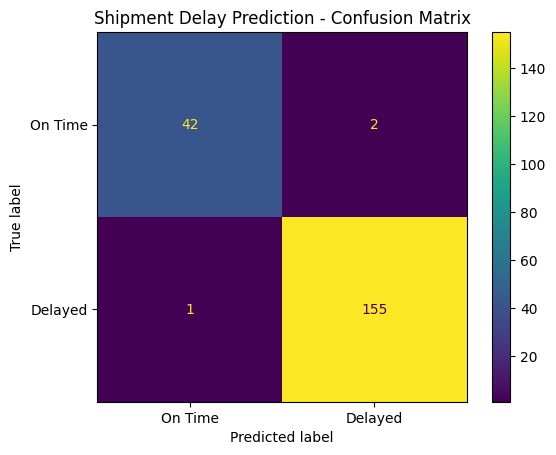

In [19]:
# ==========================================
# STEP 6.4: CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On Time", "Delayed"]
)

disp.plot()
plt.title("Shipment Delay Prediction - Confusion Matrix")
plt.show()

In [20]:
# ==========================================
# STEP 7.1: ETA MODEL FEATURES
# ==========================================

eta_features = [
    "distance_km",
    "weight_kg",
    "vehicle_capacity_kg",
    "traffic_encoded",
    "weather_encoded",
    "previous_delays",
    "warehouse_processing_hours",
    "vehicle_age_years"
]

X_eta = data[eta_features]

# Target = actual delivery time
y_eta = data["delivery_time_hours"]

print("ETA Features:")
print(eta_features)

print("\nInput Shape:", X_eta.shape)
print("Target Shape:", y_eta.shape)

ETA Features:
['distance_km', 'weight_kg', 'vehicle_capacity_kg', 'traffic_encoded', 'weather_encoded', 'previous_delays', 'warehouse_processing_hours', 'vehicle_age_years']

Input Shape: (1000, 8)
Target Shape: (1000,)


In [21]:
# ==========================================
# STEP 7.2: TRAIN-TEST SPLIT
# ==========================================

X_eta_train, X_eta_test, y_eta_train, y_eta_test = train_test_split(
    X_eta,
    y_eta,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_eta_train))
print("Testing Samples:", len(X_eta_test))

Training Samples: 800
Testing Samples: 200


In [22]:
# ==========================================
# STEP 7.3: TRAIN ETA MODEL
# ==========================================

eta_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
eta_model.fit(X_eta_train, y_eta_train)

print("ETA Prediction Model Training Complete!")

ETA Prediction Model Training Complete!


In [23]:
# ==========================================
# STEP 7.4: PREDICT DELIVERY TIME
# ==========================================

eta_predictions = eta_model.predict(X_eta_test)

print("ETA Predictions:")
print(eta_predictions[:10])

ETA Predictions:
[23.92896774 18.47081261 21.08600883 21.8080312  22.11998957 11.78881623
 13.58704714 24.05448043 23.50922572 14.36527932]


In [24]:
# ==========================================
# STEP 7.5: ETA MODEL EVALUATION
# ==========================================

mae = mean_absolute_error(
    y_eta_test,
    eta_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_eta_test,
        eta_predictions
    )
)

print("ETA Model Performance")
print("----------------------------")
print("Mean Absolute Error:", round(mae, 2), "hours")
print("Root Mean Squared Error:", round(rmse, 2), "hours")

ETA Model Performance
----------------------------
Mean Absolute Error: 1.03 hours
Root Mean Squared Error: 1.34 hours


In [25]:
# ==========================================
# STEP 7.6: ACTUAL VS PREDICTED ETA
# ==========================================

comparison = pd.DataFrame({
    "Actual_Time_Hours": y_eta_test.values,
    "Predicted_Time_Hours": eta_predictions
})

comparison["Difference"] = (
    comparison["Actual_Time_Hours"]
    - comparison["Predicted_Time_Hours"]
)

display(comparison.head(20))

,Actual_Time_Hours,Predicted_Time_Hours,Difference
0,24.997193,23.928968,1.068225
1,15.311394,18.470813,-3.159419
2,21.293142,21.086009,0.207133
3,21.370960,21.808031,-0.437072
4,21.406211,22.119990,-0.713778
5,12.497907,11.788816,0.709091
6,13.202584,13.587047,-0.384463
7,23.524648,24.054480,-0.529833
8,23.736756,23.509226,0.227530
9,14.452349,14.365279,0.087070


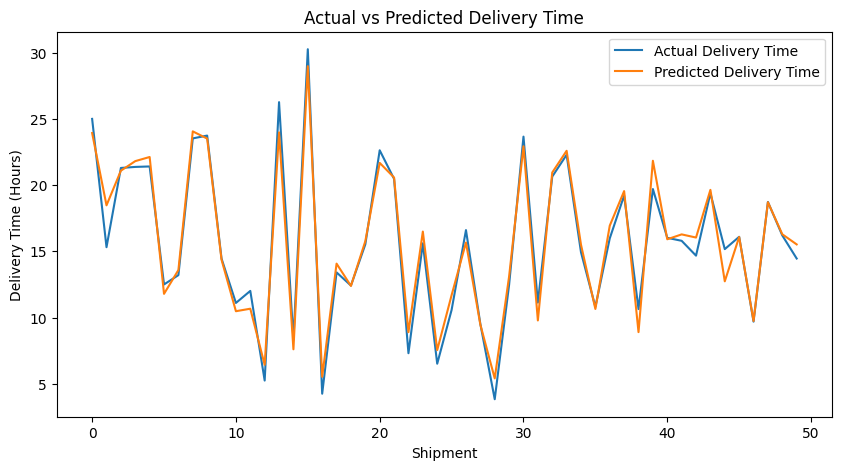

In [26]:
# ==========================================
# STEP 7.7: ETA VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    y_eta_test.values[:50],
    label="Actual Delivery Time"
)

plt.plot(
    eta_predictions[:50],
    label="Predicted Delivery Time"
)

plt.xlabel("Shipment")
plt.ylabel("Delivery Time (Hours)")
plt.title("Actual vs Predicted Delivery Time")
plt.legend()
plt.show()

In [27]:
# ==========================================
# STEP 8.1: AI SHIPMENT PREDICTION FUNCTION
# ==========================================

def predict_shipment(
    distance_km,
    weight_kg,
    vehicle_capacity_kg,
    traffic_level,
    weather,
    previous_delays,
    warehouse_processing_hours,
    vehicle_age_years
):

    # Convert traffic to number
    traffic_encoded = {
        "Low": 0,
        "Medium": 1,
        "High": 2
    }[traffic_level]

    # Convert weather to number
    weather_encoded = {
        "Clear": 0,
        "Rain": 1,
        "Storm": 2
    }[weather]

    # Create input data
    shipment = pd.DataFrame([{
        "distance_km": distance_km,
        "weight_kg": weight_kg,
        "vehicle_capacity_kg": vehicle_capacity_kg,
        "traffic_encoded": traffic_encoded,
        "weather_encoded": weather_encoded,
        "previous_delays": previous_delays,
        "warehouse_processing_hours": warehouse_processing_hours,
        "vehicle_age_years": vehicle_age_years
    }])

    # Predict delay
    delay_prediction = model.predict(shipment)[0]

    # Predict ETA
    eta_prediction = eta_model.predict(shipment)[0]

    # Convert prediction into readable result
    if delay_prediction == 1:
        status = "DELAYED"
    else:
        status = "ON TIME"

    return status, eta_prediction

In [28]:
# ==========================================
# STEP 8.2: TEST AI PREDICTION
# ==========================================

status, eta = predict_shipment(
    distance_km=250,
    weight_kg=100,
    vehicle_capacity_kg=500,
    traffic_level="High",
    weather="Rain",
    previous_delays=2,
    warehouse_processing_hours=4,
    vehicle_age_years=5
)

print("================================")
print("     AI SHIPMENT PREDICTION")
print("================================")
print("Shipment Status :", status)
print("Estimated ETA   :", round(eta, 2), "hours")
print("================================")

     AI SHIPMENT PREDICTION
Shipment Status : DELAYED
Estimated ETA   : 13.04 hours


In [29]:
status, eta = predict_shipment(
    distance_km=80,
    weight_kg=30,
    vehicle_capacity_kg=250,
    traffic_level="Low",
    weather="Clear",
    previous_delays=0,
    warehouse_processing_hours=1,
    vehicle_age_years=2
)

print("Shipment Status :", status)
print("Estimated ETA   :", round(eta, 2), "hours")

Shipment Status : ON TIME
Estimated ETA   : 3.26 hours


In [30]:
# ==========================================
# STEP 9.1: AI SHIPMENT PRIORITY SCORE
# ==========================================

def calculate_priority(
    distance_km,
    weight_kg,
    traffic_level,
    weather,
    previous_delays,
    warehouse_processing_hours,
    delay_status
):

    score = 0

    # Delay risk
    if delay_status == "DELAYED":
        score += 35
    else:
        score += 10

    # Distance
    if distance_km >= 700:
        score += 20
    elif distance_km >= 400:
        score += 15
    elif distance_km >= 200:
        score += 10
    else:
        score += 5

    # Traffic
    traffic_score = {
        "Low": 5,
        "Medium": 10,
        "High": 15
    }
    score += traffic_score[traffic_level]

    # Weather
    weather_score = {
        "Clear": 2,
        "Rain": 7,
        "Storm": 12
    }
    score += weather_score[weather]

    # Previous delays
    score += min(previous_delays * 3, 12)

    # Warehouse processing
    if warehouse_processing_hours >= 6:
        score += 6
    elif warehouse_processing_hours >= 3:
        score += 3

    # Keep score between 0 and 100
    score = min(score, 100)

    # Priority category
    if score >= 70:
        priority = "CRITICAL"
    elif score >= 50:
        priority = "HIGH"
    elif score >= 30:
        priority = "MEDIUM"
    else:
        priority = "LOW"

    return score, priority

In [31]:
# ==========================================
# STEP 9.2: TEST PRIORITY
# ==========================================

status, eta = predict_shipment(
    distance_km=700,
    weight_kg=150,
    vehicle_capacity_kg=500,
    traffic_level="High",
    weather="Rain",
    previous_delays=3,
    warehouse_processing_hours=6,
    vehicle_age_years=7
)

priority_score, priority = calculate_priority(
    distance_km=700,
    weight_kg=150,
    traffic_level="High",
    weather="Rain",
    previous_delays=3,
    warehouse_processing_hours=6,
    delay_status=status
)

print("==========================================")
print("       AI SHIPMENT INTELLIGENCE")
print("==========================================")
print("Shipment Status :", status)
print("Estimated ETA   :", round(eta, 2), "hours")
print("Priority Score  :", priority_score, "/ 100")
print("Priority Level  :", priority)
print("==========================================")

       AI SHIPMENT INTELLIGENCE
Shipment Status : DELAYED
Estimated ETA   : 23.96 hours
Priority Score  : 92 / 100
Priority Level  : CRITICAL


In [32]:
# ==========================================
# STEP 9.3: PRIORITIZE ALL SHIPMENTS
# ==========================================

def get_priority(row):

    score, priority = calculate_priority(
        row["distance_km"],
        row["weight_kg"],
        row["traffic_level"],
        row["weather"],
        row["previous_delays"],
        row["warehouse_processing_hours"],
        row["status"]
    )

    return pd.Series([score, priority])


data[["priority_score", "priority_level"]] = data.apply(
    get_priority,
    axis=1
)

# Show highest-priority shipments
priority_shipments = data.sort_values(
    "priority_score",
    ascending=False
)

display(
    priority_shipments[
        [
            "shipment_id",
            "distance_km",
            "traffic_level",
            "weather",
            "status",
            "delivery_time_hours",
            "priority_score",
            "priority_level"
        ]
    ].head(20)
)

,shipment_id,distance_km,traffic_level,weather,status,delivery_time_hours,priority_score,priority_level
258,SHP00259,984,Medium,Storm,Delayed,30.528557,70,CRITICAL
267,SHP00268,839,High,Rain,Delayed,27.694095,70,CRITICAL
105,SHP00106,872,High,Storm,Delayed,28.181087,69,HIGH
221,SHP00222,655,High,Storm,Delayed,26.991332,67,HIGH
899,SHP00900,938,High,Rain,Delayed,30.255805,67,HIGH
493,SHP00494,744,Medium,Storm,Delayed,25.873958,67,HIGH
352,SHP00353,955,Medium,Storm,Delayed,30.832315,67,HIGH
348,SHP00349,788,High,Rain,Delayed,25.343997,67,HIGH
36,SHP00037,757,Medium,Storm,Delayed,23.768131,67,HIGH
20,SHP00021,671,High,Storm,Delayed,26.869081,67,HIGH


In [33]:
# ==========================================
# STEP 10.1: CREATE ROUTE OPTIONS
# ==========================================

routes = pd.DataFrame({
    "route_id": ["R1", "R2", "R3", "R4", "R5"],

    "distance_km": [120, 135, 110, 150, 125],

    "traffic_level": [
        "High",
        "Low",
        "Medium",
        "Low",
        "Medium"
    ],

    "estimated_time_hours": [
        4.8,
        3.2,
        3.7,
        3.5,
        3.8
    ],

    "toll_cost": [180, 250, 100, 300, 150]
})

display(routes)

,route_id,distance_km,traffic_level,estimated_time_hours,toll_cost
0,R1,120,High,4.8,180
1,R2,135,Low,3.2,250
2,R3,110,Medium,3.7,100
3,R4,150,Low,3.5,300
4,R5,125,Medium,3.8,150


In [34]:
# ==========================================
# STEP 10.2: TRAFFIC PENALTY
# ==========================================

traffic_penalty = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

routes["traffic_score"] = routes["traffic_level"].map(
    traffic_penalty
)

display(routes)

,route_id,distance_km,traffic_level,estimated_time_hours,toll_cost,traffic_score
0,R1,120,High,4.8,180,3
1,R2,135,Low,3.2,250,1
2,R3,110,Medium,3.7,100,2
3,R4,150,Low,3.5,300,1
4,R5,125,Medium,3.8,150,2


In [35]:
# ==========================================
# STEP 10.3: ROUTE OPTIMIZATION SCORE
# ==========================================

routes["route_score"] = (
    routes["distance_km"] * 0.30
    + routes["estimated_time_hours"] * 20
    + routes["traffic_score"] * 15
    + routes["toll_cost"] * 0.05
)

display(routes)

,route_id,distance_km,traffic_level,estimated_time_hours,toll_cost,traffic_score,route_score
0,R1,120,High,4.8,180,3,186.0
1,R2,135,Low,3.2,250,1,132.0
2,R3,110,Medium,3.7,100,2,142.0
3,R4,150,Low,3.5,300,1,145.0
4,R5,125,Medium,3.8,150,2,151.0


In [36]:
# ==========================================
# STEP 10.4: SELECT BEST ROUTE
# ==========================================

best_route = routes.loc[
    routes["route_score"].idxmin()
]

print("==========================================")
print("          AI ROUTE RECOMMENDATION")
print("==========================================")

print("Best Route       :", best_route["route_id"])
print("Distance         :", best_route["distance_km"], "km")
print("Traffic          :", best_route["traffic_level"])
print("Estimated Time   :", best_route["estimated_time_hours"], "hours")
print("Toll Cost        : ₹", best_route["toll_cost"])
print("Route Score      :", round(best_route["route_score"], 2))

print("==========================================")

          AI ROUTE RECOMMENDATION
Best Route       : R2
Distance         : 135 km
Traffic          : Low
Estimated Time   : 3.2 hours
Toll Cost        : ₹ 250
Route Score      : 132.0


In [37]:
# ==========================================
# STEP 11.1: VEHICLE DATASET
# ==========================================

vehicles = pd.DataFrame({
    "vehicle_id": [
        "VH001", "VH002", "VH003",
        "VH004", "VH005", "VH006"
    ],

    "vehicle_type": [
        "Mini Truck",
        "Pickup",
        "Medium Truck",
        "Heavy Truck",
        "Mini Truck",
        "Medium Truck"
    ],

    "capacity_kg": [
        100, 250, 500, 1000, 150, 600
    ],

    "vehicle_age_years": [
        2, 4, 3, 6, 1, 5
    ],

    "fuel_efficiency_kmpl": [
        18, 15, 12, 8, 20, 11
    ],

    "available": [
        1, 1, 1, 1, 0, 1
    ]
})

display(vehicles)

,vehicle_id,vehicle_type,capacity_kg,vehicle_age_years,fuel_efficiency_kmpl,available
0,VH001,Mini Truck,100,2,18,1
1,VH002,Pickup,250,4,15,1
2,VH003,Medium Truck,500,3,12,1
3,VH004,Heavy Truck,1000,6,8,1
4,VH005,Mini Truck,150,1,20,0
5,VH006,Medium Truck,600,5,11,1


In [38]:
# ==========================================
# STEP 11.2: VEHICLE ALLOCATION
# ==========================================

def allocate_vehicle(weight_kg, distance_km):

    # Only available vehicles
    available_vehicles = vehicles[
        vehicles["available"] == 1
    ].copy()

    # Vehicle must have enough capacity
    suitable_vehicles = available_vehicles[
        available_vehicles["capacity_kg"] >= weight_kg
    ].copy()

    if suitable_vehicles.empty:
        return None

    # Calculate approximate fuel required
    suitable_vehicles["fuel_required"] = (
        distance_km /
        suitable_vehicles["fuel_efficiency_kmpl"]
    )

    # Allocation score
    suitable_vehicles["allocation_score"] = (
        suitable_vehicles["fuel_required"] * 0.5
        + suitable_vehicles["vehicle_age_years"] * 0.2
        + suitable_vehicles["capacity_kg"] * 0.001
    )

    # Select vehicle with lowest score
    best_vehicle = suitable_vehicles.loc[
        suitable_vehicles["allocation_score"].idxmin()
    ]

    return best_vehicle

In [39]:
# ==========================================
# STEP 11.3: TEST VEHICLE ALLOCATION
# ==========================================

shipment_weight = 300
shipment_distance = 250

selected_vehicle = allocate_vehicle(
    shipment_weight,
    shipment_distance
)

if selected_vehicle is not None:

    print("==========================================")
    print("       AI VEHICLE ALLOCATION")
    print("==========================================")

    print("Shipment Weight :", shipment_weight, "kg")
    print("Distance        :", shipment_distance, "km")
    print("------------------------------------------")

    print("Vehicle ID      :", selected_vehicle["vehicle_id"])
    print("Vehicle Type    :", selected_vehicle["vehicle_type"])
    print("Capacity        :", selected_vehicle["capacity_kg"], "kg")
    print("Fuel Efficiency :", selected_vehicle["fuel_efficiency_kmpl"], "km/l")
    print("Fuel Required   :", round(
        selected_vehicle["fuel_required"], 2
    ), "litres")

    print("==========================================")

else:
    print("No suitable vehicle available.")

       AI VEHICLE ALLOCATION
Shipment Weight : 300 kg
Distance        : 250 km
------------------------------------------
Vehicle ID      : VH003
Vehicle Type    : Medium Truck
Capacity        : 500 kg
Fuel Efficiency : 12 km/l
Fuel Required   : 20.83 litres


In [40]:
selected_vehicle = allocate_vehicle(
    weight_kg=80,
    distance_km=100
)

if selected_vehicle is not None:
    print("Recommended Vehicle:",
          selected_vehicle["vehicle_id"])
    print("Vehicle Type:",
          selected_vehicle["vehicle_type"])
    print("Capacity:",
          selected_vehicle["capacity_kg"], "kg")
else:
    print("No suitable vehicle available.")

Recommended Vehicle: VH001
Vehicle Type: Mini Truck
Capacity: 100 kg


In [41]:
# ==========================================
# STEP 12.1: WAREHOUSE DATASET
# ==========================================

np.random.seed(42)

n_warehouse = 1000

warehouse_data = pd.DataFrame({

    "product_id": [
        f"P{i:04d}" for i in range(1, n_warehouse + 1)
    ],

    "current_stock": np.random.randint(
        10, 1000, n_warehouse
    ),

    "previous_sales": np.random.randint(
        5, 500, n_warehouse
    ),

    "incoming_stock": np.random.randint(
        0, 500, n_warehouse
    ),

    "lead_time_days": np.random.randint(
        1, 15, n_warehouse
    ),

    "season": np.random.choice(
        ["Normal", "Peak", "Festival"],
        n_warehouse,
        p=[0.60, 0.25, 0.15]
    ),

    "warehouse_capacity": np.random.randint(
        500, 5000, n_warehouse
    )
})

display(warehouse_data.head())

,product_id,current_stock,previous_sales,incoming_stock,lead_time_days,season,warehouse_capacity
0,P0001,112,181,473,1,Normal,2759
1,P0002,445,271,182,12,Festival,4251
2,P0003,870,345,470,8,Peak,2586
3,P0004,280,286,363,13,Normal,868
4,P0005,116,67,38,10,Normal,3304


In [42]:
# ==========================================
# STEP 12.2: CREATE FUTURE DEMAND
# ==========================================

season_effect = warehouse_data["season"].map({
    "Normal": 0,
    "Peak": 50,
    "Festival": 100
})

warehouse_data["future_demand"] = (
    warehouse_data["previous_sales"] * 0.8
    + season_effect
    + warehouse_data["lead_time_days"] * 5
    + np.random.normal(0, 20, n_warehouse)
)

# Demand cannot be negative
warehouse_data["future_demand"] = (
    warehouse_data["future_demand"].clip(lower=0)
)

display(warehouse_data.head())

,product_id,current_stock,previous_sales,incoming_stock,lead_time_days,season,warehouse_capacity,future_demand
0,P0001,112,181,473,1,Normal,2759,157.526158
1,P0002,445,271,182,12,Festival,4251,369.042016
2,P0003,870,345,470,8,Peak,2586,330.479953
3,P0004,280,286,363,13,Normal,868,312.348150
4,P0005,116,67,38,10,Normal,3304,91.130713


In [43]:
# ==========================================
# STEP 12.3: ENCODE SEASON
# ==========================================

warehouse_data["season_encoded"] = (
    warehouse_data["season"].map({
        "Normal": 0,
        "Peak": 1,
        "Festival": 2
    })
)

print("Season encoding completed.")

Season encoding completed.


In [44]:
# ==========================================
# STEP 12.4: PREPARE DEMAND MODEL
# ==========================================

warehouse_features = [
    "current_stock",
    "previous_sales",
    "incoming_stock",
    "lead_time_days",
    "season_encoded",
    "warehouse_capacity"
]

X_demand = warehouse_data[warehouse_features]

y_demand = warehouse_data["future_demand"]

X_demand_train, X_demand_test, y_demand_train, y_demand_test = (
    train_test_split(
        X_demand,
        y_demand,
        test_size=0.20,
        random_state=42
    )
)

print("Training Samples:", len(X_demand_train))
print("Testing Samples:", len(X_demand_test))

Training Samples: 800
Testing Samples: 200


In [45]:
# ==========================================
# STEP 12.5: TRAIN DEMAND MODEL
# ==========================================

demand_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

demand_model.fit(
    X_demand_train,
    y_demand_train
)

print("Warehouse Demand Model Training Complete!")

Warehouse Demand Model Training Complete!


In [46]:
# ==========================================
# STEP 12.6: TEST DEMAND MODEL
# ==========================================

demand_predictions = demand_model.predict(
    X_demand_test
)

mae_demand = mean_absolute_error(
    y_demand_test,
    demand_predictions
)

rmse_demand = np.sqrt(
    mean_squared_error(
        y_demand_test,
        demand_predictions
    )
)

print("==========================================")
print("       DEMAND PREDICTION RESULTS")
print("==========================================")
print(
    "Mean Absolute Error:",
    round(mae_demand, 2)
)
print(
    "Root Mean Squared Error:",
    round(rmse_demand, 2)
)

       DEMAND PREDICTION RESULTS
Mean Absolute Error: 20.96
Root Mean Squared Error: 26.63


In [47]:
# ==========================================
# STEP 12.7: REORDER RECOMMENDATION
# ==========================================

def inventory_recommendation(
    current_stock,
    predicted_demand,
    incoming_stock
):

    available_stock = current_stock + incoming_stock

    if available_stock < predicted_demand:
        reorder_quantity = (
            predicted_demand - available_stock
        )

        status = "REORDER REQUIRED"

    else:
        reorder_quantity = 0
        status = "STOCK SUFFICIENT"

    return status, max(0, round(reorder_quantity))

In [48]:
# ==========================================
# STEP 12.8: TEST INVENTORY SYSTEM
# ==========================================

current_stock = 100
incoming_stock = 50

# Example predicted demand
predicted_demand = 220

status, reorder_quantity = inventory_recommendation(
    current_stock,
    predicted_demand,
    incoming_stock
)

print("==========================================")
print("      AI INVENTORY RECOMMENDATION")
print("==========================================")
print("Current Stock     :", current_stock)
print("Incoming Stock    :", incoming_stock)
print("Predicted Demand  :", predicted_demand)
print("Status            :", status)
print("Reorder Quantity  :", reorder_quantity)
print("==========================================")

      AI INVENTORY RECOMMENDATION
Current Stock     : 100
Incoming Stock    : 50
Predicted Demand  : 220
Status            : REORDER REQUIRED
Reorder Quantity  : 70


In [49]:
# ==========================================
# STEP 13 — AI STOCK-OUT RISK PREDICTION
# ==========================================

warehouse_data["stock_after_demand"] = (
    warehouse_data["current_stock"]
    + warehouse_data["incoming_stock"]
    - warehouse_data["future_demand"]
)

warehouse_data["stock_out_risk"] = (
    warehouse_data["stock_after_demand"] < 0
).astype(int)

warehouse_data["stock_status"] = warehouse_data["stock_out_risk"].map({
    0: "SAFE",
    1: "STOCK-OUT RISK"
})

print("Stock-Out Risk Calculation Complete!")

display(
    warehouse_data[[
        "product_id",
        "current_stock",
        "incoming_stock",
        "future_demand",
        "stock_after_demand",
        "stock_status"
    ]].head(10)
)

Stock-Out Risk Calculation Complete!


,product_id,current_stock,incoming_stock,future_demand,stock_after_demand,stock_status
0,P0001,112,473,157.526158,427.473842,SAFE
1,P0002,445,182,369.042016,257.957984,SAFE
2,P0003,870,470,330.479953,1009.520047,SAFE
3,P0004,280,363,312.348150,330.651850,SAFE
4,P0005,116,38,91.130713,62.869287,SAFE
5,P0006,81,14,296.697969,-201.697969,STOCK-OUT RISK
6,P0007,710,375,316.517117,768.482883,SAFE
7,P0008,30,496,368.331268,157.668732,SAFE
8,P0009,624,3,326.848668,300.151332,SAFE
9,P0010,131,348,181.610162,297.389838,SAFE


In [50]:
stock_out_count = warehouse_data["stock_out_risk"].sum()
total_products = len(warehouse_data)

stock_out_percentage = (
    stock_out_count / total_products
) * 100

print("==========================================")
print("       INVENTORY RISK SUMMARY")
print("==========================================")
print("Total Products      :", total_products)
print("Stock-Out Risk      :", stock_out_count)
print("Safe Products       :", total_products - stock_out_count)
print("Risk Percentage     :", round(stock_out_percentage, 2), "%")
print("==========================================")

       INVENTORY RISK SUMMARY
Total Products      : 1000
Stock-Out Risk      : 83
Safe Products       : 917
Risk Percentage     : 8.3 %


In [51]:
def calculate_stock_risk(row):
    risk = 0

    # Current stock risk
    if row["current_stock"] < row["future_demand"] * 0.25:
        risk += 40
    elif row["current_stock"] < row["future_demand"] * 0.50:
        risk += 25
    elif row["current_stock"] < row["future_demand"]:
        risk += 15

    # Lead time risk
    if row["lead_time_days"] >= 10:
        risk += 20
    elif row["lead_time_days"] >= 5:
        risk += 10

    # Incoming stock
    if row["incoming_stock"] < row["future_demand"] * 0.20:
        risk += 15

    # Season risk
    if row["season"] == "Festival":
        risk += 15
    elif row["season"] == "Peak":
        risk += 10

    return min(risk, 100)


warehouse_data["risk_score"] = warehouse_data.apply(
    calculate_stock_risk,
    axis=1
)

print("AI Stock Risk Score Generated!")

AI Stock Risk Score Generated!


In [52]:
def classify_risk(score):
    if score >= 70:
        return "CRITICAL"
    elif score >= 50:
        return "HIGH"
    elif score >= 30:
        return "MEDIUM"
    else:
        return "LOW"


warehouse_data["risk_level"] = warehouse_data["risk_score"].apply(
    classify_risk
)

display(
    warehouse_data[[
        "product_id",
        "current_stock",
        "future_demand",
        "incoming_stock",
        "risk_score",
        "risk_level"
    ]].sort_values(
        "risk_score",
        ascending=False
    ).head(20)
)

,product_id,current_stock,future_demand,incoming_stock,risk_score,risk_level
534,P0535,29,582.394215,110,90,CRITICAL
642,P0643,56,336.787029,20,80,CRITICAL
16,P0017,109,460.494286,492,75,CRITICAL
282,P0283,122,391.448540,73,75,CRITICAL
61,P0062,30,412.514299,428,75,CRITICAL
433,P0434,31,372.924133,8,75,CRITICAL
101,P0102,171,538.175945,51,75,CRITICAL
518,P0519,48,375.983743,8,75,CRITICAL
708,P0709,21,372.566089,459,75,CRITICAL
129,P0130,24,415.101095,8,75,CRITICAL


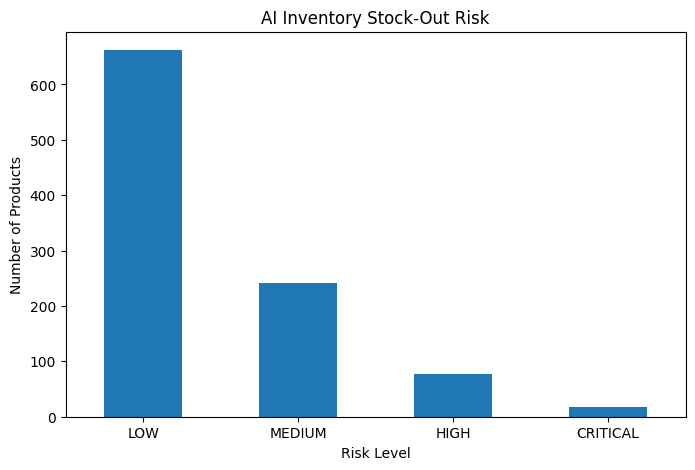

In [53]:
# ==========================================
# INVENTORY DASHBOARD
# ==========================================

risk_counts = warehouse_data["risk_level"].value_counts()

plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("AI Inventory Stock-Out Risk")
plt.xlabel("Risk Level")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

plt.show()

In [54]:
critical_products = warehouse_data[
    warehouse_data["risk_level"] == "CRITICAL"
].sort_values(
    "risk_score",
    ascending=False
)

print("==========================================")
print("       CRITICAL INVENTORY PRODUCTS")
print("==========================================")

display(
    critical_products[[
        "product_id",
        "current_stock",
        "future_demand",
        "incoming_stock",
        "lead_time_days",
        "season",
        "risk_score",
        "risk_level"
    ]].head(10)
)

       CRITICAL INVENTORY PRODUCTS


,product_id,current_stock,future_demand,incoming_stock,lead_time_days,season,risk_score,risk_level
534,P0535,29,582.394215,110,14,Festival,90,CRITICAL
642,P0643,56,336.787029,20,8,Festival,80,CRITICAL
708,P0709,21,372.566089,459,14,Festival,75,CRITICAL
16,P0017,109,460.494286,492,10,Festival,75,CRITICAL
61,P0062,30,412.514299,428,14,Festival,75,CRITICAL
101,P0102,171,538.175945,51,11,Festival,75,CRITICAL
518,P0519,48,375.983743,8,9,Peak,75,CRITICAL
433,P0434,31,372.924133,8,12,Normal,75,CRITICAL
129,P0130,24,415.101095,8,12,Normal,75,CRITICAL
282,P0283,122,391.448540,73,14,Festival,75,CRITICAL


In [55]:
# ==========================================
# STEP 14 — FUEL & SHIPMENT COST PREDICTION
# ==========================================

# Fuel consumption based on distance and vehicle efficiency
data["fuel_efficiency_kmpl"] = np.random.uniform(
    7, 20, len(data)
)

data["fuel_consumption_litres"] = (
    data["distance_km"] /
    data["fuel_efficiency_kmpl"]
)

# Approximate fuel price
fuel_price_per_litre = 100

data["fuel_cost"] = (
    data["fuel_consumption_litres"] *
    fuel_price_per_litre
)

print("Fuel Consumption and Cost Calculated!")

display(
    data[[
        "shipment_id",
        "distance_km",
        "fuel_efficiency_kmpl",
        "fuel_consumption_litres",
        "fuel_cost"
    ]].head(10)
)

Fuel Consumption and Cost Calculated!


,shipment_id,distance_km,fuel_efficiency_kmpl,fuel_consumption_litres,fuel_cost
0,SHP00001,112,12.941776,8.654145,865.414482
1,SHP00002,445,10.773316,41.305758,4130.575811
2,SHP00003,870,14.305158,60.817223,6081.722285
3,SHP00004,280,8.455150,33.115914,3311.591350
4,SHP00005,116,14.923577,7.772936,777.293562
5,SHP00006,81,14.389615,5.629059,562.905941
6,SHP00007,710,17.295909,41.050169,4105.016869
7,SHP00008,30,19.826939,1.513093,151.309287
8,SHP00009,624,10.261355,60.810682,6081.068163
9,SHP00010,131,13.625534,9.614302,961.430219


In [56]:
# Driver and operational cost
data["driver_cost"] = (
    data["delivery_time_hours"] * 150
)

data["toll_cost"] = (
    data["distance_km"] * 0.50
)

data["maintenance_cost"] = (
    data["distance_km"] * 0.20
)

data["total_shipment_cost"] = (
    data["fuel_cost"]
    + data["driver_cost"]
    + data["toll_cost"]
    + data["maintenance_cost"]
)

display(
    data[[
        "shipment_id",
        "fuel_cost",
        "driver_cost",
        "toll_cost",
        "maintenance_cost",
        "total_shipment_cost"
    ]].head(10)
)

,shipment_id,fuel_cost,driver_cost,toll_cost,maintenance_cost,total_shipment_cost
0,SHP00001,865.414482,1288.101091,56.0,22.4,2231.915573
1,SHP00002,4130.575811,1875.529506,222.5,89.0,6317.605316
2,SHP00003,6081.722285,3067.808121,435.0,174.0,9758.530406
3,SHP00004,3311.591350,1369.642752,140.0,56.0,4877.234102
4,SHP00005,777.293562,1478.826944,58.0,23.2,2337.320506
5,SHP00006,562.905941,1791.648763,40.5,16.2,2411.254704
6,SHP00007,4105.016869,3562.937873,355.0,142.0,8164.954742
7,SHP00008,151.309287,1364.978824,15.0,6.0,1537.288111
8,SHP00009,6081.068163,3173.393231,312.0,124.8,9691.261394
9,SHP00010,961.430219,1943.765110,65.5,26.2,2996.895329


In [57]:
cost_features = [
    "distance_km",
    "weight_kg",
    "vehicle_capacity_kg",
    "traffic_encoded",
    "weather_encoded",
    "previous_delays",
    "warehouse_processing_hours",
    "vehicle_age_years"
]

X_cost = data[cost_features]
y_cost = data["total_shipment_cost"]

X_cost_train, X_cost_test, y_cost_train, y_cost_test = train_test_split(
    X_cost,
    y_cost,
    test_size=0.20,
    random_state=42
)

cost_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

cost_model.fit(
    X_cost_train,
    y_cost_train
)

print("AI Shipment Cost Model Training Complete!")

AI Shipment Cost Model Training Complete!


In [58]:
cost_predictions = cost_model.predict(X_cost_test)

mae_cost = mean_absolute_error(
    y_cost_test,
    cost_predictions
)

rmse_cost = np.sqrt(
    mean_squared_error(
        y_cost_test,
        cost_predictions
    )
)

print("==========================================")
print("       SHIPMENT COST MODEL")
print("==========================================")
print("Mean Absolute Error :", round(mae_cost, 2))
print("RMSE                :", round(rmse_cost, 2))
print("==========================================")

       SHIPMENT COST MODEL
Mean Absolute Error : 1256.84
RMSE                : 1661.71


In [59]:
def predict_shipment_cost(
    distance_km,
    weight_kg,
    vehicle_capacity_kg,
    traffic_level,
    weather,
    previous_delays,
    warehouse_processing_hours,
    vehicle_age_years
):

    traffic_encoded = {
        "Low": 0,
        "Medium": 1,
        "High": 2
    }[traffic_level]

    weather_encoded = {
        "Clear": 0,
        "Rain": 1,
        "Storm": 2
    }[weather]

    shipment = pd.DataFrame([{
        "distance_km": distance_km,
        "weight_kg": weight_kg,
        "vehicle_capacity_kg": vehicle_capacity_kg,
        "traffic_encoded": traffic_encoded,
        "weather_encoded": weather_encoded,
        "previous_delays": previous_delays,
        "warehouse_processing_hours": warehouse_processing_hours,
        "vehicle_age_years": vehicle_age_years
    }])

    predicted_cost = cost_model.predict(shipment)[0]

    return predicted_cost

In [60]:
predicted_cost = predict_shipment_cost(
    distance_km=500,
    weight_kg=300,
    vehicle_capacity_kg=500,
    traffic_level="Medium",
    weather="Rain",
    previous_delays=1,
    warehouse_processing_hours=3,
    vehicle_age_years=4
)

print("==========================================")
print("      AI SHIPMENT COST PREDICTION")
print("==========================================")
print("Distance       : 500 km")
print("Shipment Weight: 300 kg")
print("Traffic        : Medium")
print("Weather        : Rain")
print("------------------------------------------")
print("Predicted Cost : ₹", round(predicted_cost, 2))
print("==========================================")

      AI SHIPMENT COST PREDICTION
Distance       : 500 km
Shipment Weight: 300 kg
Traffic        : Medium
Weather        : Rain
------------------------------------------
Predicted Cost : ₹ 6676.84


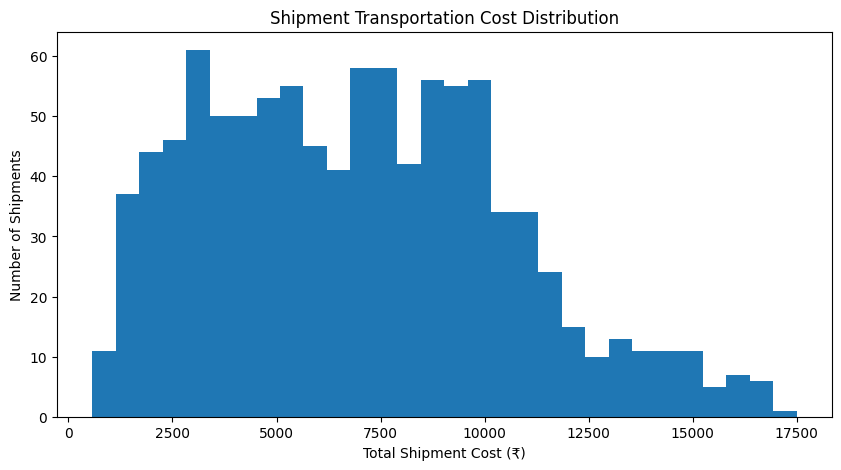

In [61]:
plt.figure(figsize=(10, 5))

plt.hist(
    data["total_shipment_cost"],
    bins=30
)

plt.title("Shipment Transportation Cost Distribution")
plt.xlabel("Total Shipment Cost (₹)")
plt.ylabel("Number of Shipments")

plt.show()

In [62]:
# ==========================================
# STEP 15 — VEHICLE MAINTENANCE PREDICTION
# ==========================================

np.random.seed(42)

vehicle_data = pd.DataFrame({
    "vehicle_id": [f"VH{i:04d}" for i in range(1, 501)],
    "vehicle_age_years": np.random.randint(1, 15, 500),
    "total_km": np.random.randint(5000, 300000, 500),
    "engine_temperature": np.round(
        np.random.uniform(70, 110, 500), 2
    ),
    "maintenance_count": np.random.randint(0, 12, 500),
    "days_since_service": np.random.randint(1, 365, 500),
    "fuel_efficiency": np.round(
        np.random.uniform(6, 20, 500), 2
    ),
    "breakdown_count": np.random.randint(0, 6, 500)
})

display(vehicle_data.head(10))

,vehicle_id,vehicle_age_years,total_km,engine_temperature,maintenance_count,days_since_service,fuel_efficiency,breakdown_count
0,VH0001,7,60609,99.64,4,121,19.95,4
1,VH0002,4,232897,92.98,4,125,11.16,5
2,VH0003,13,36024,103.67,10,170,12.28,2
3,VH0004,11,75313,75.59,3,72,16.11,2
4,VH0005,8,189078,101.81,5,152,18.41,2
5,VH0006,13,118632,78.07,2,208,14.30,4
6,VH0007,5,256451,76.55,8,49,11.48,3
7,VH0008,7,8051,76.57,4,154,11.78,1
8,VH0009,10,184819,102.58,2,347,15.74,2
9,VH0010,3,92235,96.61,10,293,6.05,5


In [63]:
vehicle_data["maintenance_risk"] = (
    vehicle_data["vehicle_age_years"] * 3
    + vehicle_data["total_km"] / 30000
    + vehicle_data["engine_temperature"] * 0.4
    + vehicle_data["days_since_service"] * 0.08
    + vehicle_data["breakdown_count"] * 8
    - vehicle_data["maintenance_count"] * 2
)

vehicle_data["maintenance_risk"] = (
    vehicle_data["maintenance_risk"]
    .clip(0, 100)
)

print("Maintenance Risk Generated!")

display(
    vehicle_data[[
        "vehicle_id",
        "vehicle_age_years",
        "total_km",
        "days_since_service",
        "breakdown_count",
        "maintenance_risk"
    ]].head(10)
)

Maintenance Risk Generated!


,vehicle_id,vehicle_age_years,total_km,days_since_service,breakdown_count,maintenance_risk
0,VH0001,7,60609,121,4,96.556300
1,VH0002,4,232897,125,5,98.955233
2,VH0003,13,36024,170,2,91.268800
3,VH0004,11,75313,72,2,81.506433
4,VH0005,8,189078,152,2,89.186600
5,VH0006,13,118632,208,4,100.000000
6,VH0007,5,256451,49,3,66.088367
7,VH0008,7,8051,154,1,64.216367
8,VH0009,10,184819,347,2,100.000000
9,VH0010,3,92235,293,5,94.158500


In [64]:
def maintenance_status(risk):
    if risk >= 70:
        return "URGENT"
    elif risk >= 50:
        return "MAINTENANCE REQUIRED"
    elif risk >= 30:
        return "MONITOR"
    else:
        return "GOOD"


vehicle_data["maintenance_status"] = (
    vehicle_data["maintenance_risk"]
    .apply(maintenance_status)
)

display(
    vehicle_data[[
        "vehicle_id",
        "maintenance_risk",
        "maintenance_status"
    ]].head(20)
)

,vehicle_id,maintenance_risk,maintenance_status
0,VH0001,96.556300,URGENT
1,VH0002,98.955233,URGENT
2,VH0003,91.268800,URGENT
3,VH0004,81.506433,URGENT
4,VH0005,89.186600,URGENT
5,VH0006,100.000000,URGENT
6,VH0007,66.088367,MAINTENANCE REQUIRED
7,VH0008,64.216367,MAINTENANCE REQUIRED
8,VH0009,100.000000,URGENT
9,VH0010,94.158500,URGENT


In [65]:
maintenance_features = [
    "vehicle_age_years",
    "total_km",
    "engine_temperature",
    "maintenance_count",
    "days_since_service",
    "fuel_efficiency",
    "breakdown_count"
]

X_maintenance = vehicle_data[maintenance_features]
y_maintenance = vehicle_data["maintenance_risk"]

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_maintenance,
    y_maintenance,
    test_size=0.20,
    random_state=42
)

maintenance_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

maintenance_model.fit(
    X_m_train,
    y_m_train
)

print("AI Maintenance Prediction Model Training Complete!")

AI Maintenance Prediction Model Training Complete!


In [66]:
maintenance_predictions = maintenance_model.predict(
    X_m_test
)

mae_maintenance = mean_absolute_error(
    y_m_test,
    maintenance_predictions
)

rmse_maintenance = np.sqrt(
    mean_squared_error(
        y_m_test,
        maintenance_predictions
    )
)

print("==========================================")
print("      MAINTENANCE MODEL RESULTS")
print("==========================================")
print("MAE  :", round(mae_maintenance, 2))
print("RMSE :", round(rmse_maintenance, 2))
print("==========================================")

      MAINTENANCE MODEL RESULTS
MAE  : 5.06
RMSE : 6.61


In [67]:
vehicle_data["performance_score"] = (
    100
    - vehicle_data["maintenance_risk"]
)

vehicle_data["performance_score"] = (
    vehicle_data["performance_score"]
    .clip(0, 100)
)

display(
    vehicle_data[[
        "vehicle_id",
        "fuel_efficiency",
        "breakdown_count",
        "maintenance_risk",
        "performance_score",
        "maintenance_status"
    ]].head(15)
)

,vehicle_id,fuel_efficiency,breakdown_count,maintenance_risk,performance_score,maintenance_status
0,VH0001,19.95,4,96.556300,3.443700,URGENT
1,VH0002,11.16,5,98.955233,1.044767,URGENT
2,VH0003,12.28,2,91.268800,8.731200,URGENT
3,VH0004,16.11,2,81.506433,18.493567,URGENT
4,VH0005,18.41,2,89.186600,10.813400,URGENT
5,VH0006,14.30,4,100.000000,0.000000,URGENT
6,VH0007,11.48,3,66.088367,33.911633,MAINTENANCE REQUIRED
7,VH0008,11.78,1,64.216367,35.783633,MAINTENANCE REQUIRED
8,VH0009,15.74,2,100.000000,0.000000,URGENT
9,VH0010,6.05,5,94.158500,5.841500,URGENT


In [68]:
urgent_vehicles = vehicle_data[
    vehicle_data["maintenance_status"] == "URGENT"
].sort_values(
    "maintenance_risk",
    ascending=False
)

print("==========================================")
print("       URGENT MAINTENANCE VEHICLES")
print("==========================================")

display(
    urgent_vehicles[[
        "vehicle_id",
        "vehicle_age_years",
        "total_km",
        "engine_temperature",
        "days_since_service",
        "breakdown_count",
        "maintenance_risk",
        "performance_score"
    ]].head(15)
)

       URGENT MAINTENANCE VEHICLES


,vehicle_id,vehicle_age_years,total_km,engine_temperature,days_since_service,breakdown_count,maintenance_risk,performance_score
464,VH0465,6,185448,72.71,362,4,100.0,0.0
463,VH0464,11,194139,97.52,136,3,100.0,0.0
462,VH0463,9,96922,107.49,111,4,100.0,0.0
453,VH0454,7,117221,101.19,118,4,100.0,0.0
452,VH0453,6,243213,91.60,191,5,100.0,0.0
449,VH0450,14,164818,95.27,353,0,100.0,0.0
39,VH0040,10,181615,79.94,258,5,100.0,0.0
448,VH0449,8,127177,109.25,189,5,100.0,0.0
33,VH0034,13,230913,94.80,160,3,100.0,0.0
31,VH0032,10,105235,75.57,293,3,100.0,0.0


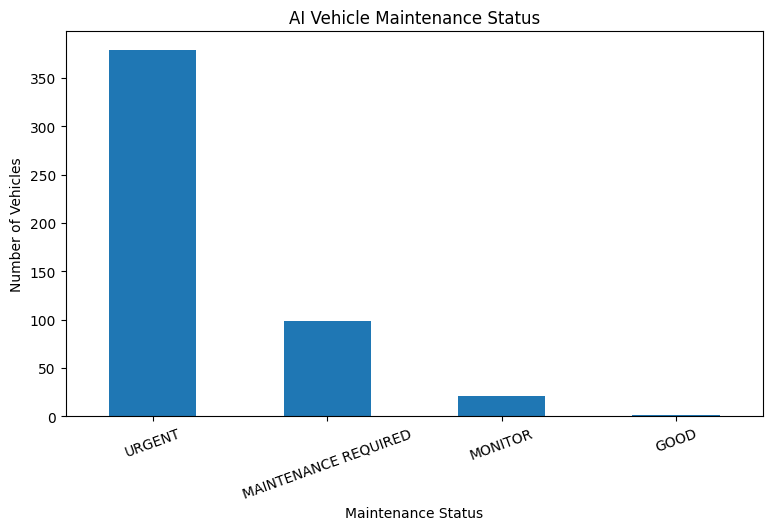

In [69]:
status_counts = vehicle_data[
    "maintenance_status"
].value_counts()

plt.figure(figsize=(9, 5))

status_counts.plot(kind="bar")

plt.title("AI Vehicle Maintenance Status")
plt.xlabel("Maintenance Status")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=20)

plt.show()

In [70]:
# ==========================================
# STEP 16 — DRIVER & VEHICLE ASSIGNMENT
# ==========================================

drivers = pd.DataFrame({
    "driver_id": [
        "DR001", "DR002", "DR003", "DR004",
        "DR005", "DR006", "DR007", "DR008"
    ],
    "experience_years": [8, 3, 12, 5, 7, 2, 10, 6],
    "performance_score": [92, 78, 95, 85, 88, 72, 94, 82],
    "previous_delays": [1, 3, 0, 2, 1, 4, 0, 2],
    "long_distance_experience": [1, 0, 1, 1, 1, 0, 1, 1],
    "available": [1, 1, 1, 1, 1, 1, 1, 1]
})

display(drivers)

,driver_id,experience_years,performance_score,previous_delays,long_distance_experience,available
0,DR001,8,92,1,1,1
1,DR002,3,78,3,0,1
2,DR003,12,95,0,1,1
3,DR004,5,85,2,1,1
4,DR005,7,88,1,1,1
5,DR006,2,72,4,0,1
6,DR007,10,94,0,1,1
7,DR008,6,82,2,1,1


In [71]:
def calculate_driver_score(driver, distance_km):

    score = 0

    # Performance
    score += driver["performance_score"] * 0.40

    # Experience
    score += min(driver["experience_years"] * 2, 20)

    # Delay penalty
    score -= driver["previous_delays"] * 3

    # Long-distance experience
    if distance_km >= 500:
        if driver["long_distance_experience"] == 1:
            score += 15
        else:
            score -= 10

    return score

In [72]:
def assign_driver(distance_km):

    available_drivers = drivers[
        drivers["available"] == 1
    ].copy()

    available_drivers["driver_score"] = (
        available_drivers.apply(
            lambda row: calculate_driver_score(
                row,
                distance_km
            ),
            axis=1
        )
    )

    best_driver = available_drivers.loc[
        available_drivers["driver_score"].idxmax()
    ]

    return best_driver

In [73]:
shipment_distance = 650

selected_driver = assign_driver(
    shipment_distance
)

print("==========================================")
print("         AI DRIVER ASSIGNMENT")
print("==========================================")
print("Shipment Distance :", shipment_distance, "km")
print("------------------------------------------")
print("Driver ID          :", selected_driver["driver_id"])
print("Experience         :", selected_driver["experience_years"], "years")
print("Performance Score  :", selected_driver["performance_score"])
print("Previous Delays    :", selected_driver["previous_delays"])
print("Driver Score       :", round(selected_driver["driver_score"], 2))
print("==========================================")

         AI DRIVER ASSIGNMENT
Shipment Distance : 650 km
------------------------------------------
Driver ID          : DR003
Experience         : 12 years
Performance Score  : 95
Previous Delays    : 0
Driver Score       : 73.0


In [74]:
def assign_vehicle_and_driver(
    weight_kg,
    distance_km
):

    # Vehicle selection
    selected_vehicle = allocate_vehicle(
        weight_kg,
        distance_km
    )

    # Driver selection
    selected_driver = assign_driver(
        distance_km
    )

    return selected_vehicle, selected_driver

In [75]:
shipment_weight = 400
shipment_distance = 600

vehicle, driver = assign_vehicle_and_driver(
    shipment_weight,
    shipment_distance
)

print("==========================================")
print("     AI SHIPMENT ASSIGNMENT SYSTEM")
print("==========================================")

print("Shipment Weight :", shipment_weight, "kg")
print("Distance        :", shipment_distance, "km")

print("------------------------------------------")
print("VEHICLE")
print("------------------------------------------")

if vehicle is not None:
    print("Vehicle ID      :", vehicle["vehicle_id"])
    print("Vehicle Type    :", vehicle["vehicle_type"])
    print("Capacity        :", vehicle["capacity_kg"], "kg")
    print("Fuel Efficiency :", vehicle["fuel_efficiency_kmpl"], "km/l")

print("------------------------------------------")
print("DRIVER")
print("------------------------------------------")

print("Driver ID       :", driver["driver_id"])
print("Experience      :", driver["experience_years"], "years")
print("Performance     :", driver["performance_score"])
print("Driver Score    :", round(driver["driver_score"], 2))

print("==========================================")

     AI SHIPMENT ASSIGNMENT SYSTEM
Shipment Weight : 400 kg
Distance        : 600 km
------------------------------------------
VEHICLE
------------------------------------------
Vehicle ID      : VH003
Vehicle Type    : Medium Truck
Capacity        : 500 kg
Fuel Efficiency : 12 km/l
------------------------------------------
DRIVER
------------------------------------------
Driver ID       : DR003
Experience      : 12 years
Performance     : 95
Driver Score    : 73.0


In [76]:
def calculate_assignment_score(
    vehicle,
    driver
):

    vehicle_score = (
        vehicle["fuel_efficiency_kmpl"] * 3
        - vehicle["vehicle_age_years"]
        - vehicle["allocation_score"] * 0.1
    )

    driver_score = driver["driver_score"]

    final_score = (
        vehicle_score * 0.30
        + driver_score * 0.70
    )

    return round(final_score, 2)

In [77]:
if vehicle is not None:

    final_score = calculate_assignment_score(
        vehicle,
        driver
    )

    print("==========================================")
    print("       FINAL AI ASSIGNMENT SCORE")
    print("==========================================")
    print("Vehicle :", vehicle["vehicle_id"])
    print("Driver  :", driver["driver_id"])
    print("------------------------------------------")
    print("Assignment Score :", final_score)
    print("==========================================")

       FINAL AI ASSIGNMENT SCORE
Vehicle : VH003
Driver  : DR003
------------------------------------------
Assignment Score : 60.22


In [78]:
# ==========================================
# STEP 17 — SHIPMENT TRACKING & AI ALERTS
# ==========================================

tracking_data = data[[
    "shipment_id",
    "distance_km",
    "delivery_time_hours",
    "traffic_level",
    "weather",
    "status",
    "priority_level"
]].copy()

# Simulated shipment progress
np.random.seed(42)

tracking_data["progress_percent"] = np.random.randint(
    5, 101, len(tracking_data)
)

tracking_data["distance_completed_km"] = (
    tracking_data["distance_km"]
    * tracking_data["progress_percent"] / 100
)

tracking_data["distance_remaining_km"] = (
    tracking_data["distance_km"]
    - tracking_data["distance_completed_km"]
)

display(tracking_data.head(10))

,shipment_id,distance_km,delivery_time_hours,traffic_level,weather,status,priority_level,progress_percent,distance_completed_km,distance_remaining_km
0,SHP00001,112,8.587341,Low,Clear,Delayed,MEDIUM,56,62.72,49.28
1,SHP00002,445,12.503530,Medium,Rain,Delayed,HIGH,97,431.65,13.35
2,SHP00003,870,20.452054,Low,Rain,Delayed,MEDIUM,19,165.30,704.70
3,SHP00004,280,9.130952,Low,Rain,Delayed,MEDIUM,76,212.80,67.20
4,SHP00005,116,9.858846,Medium,Clear,On Time,MEDIUM,65,75.40,40.60
5,SHP00006,81,11.944325,Low,Rain,Delayed,MEDIUM,25,20.25,60.75
6,SHP00007,710,23.752919,Medium,Rain,Delayed,HIGH,87,617.70,92.30
7,SHP00008,30,9.099859,Medium,Rain,Delayed,MEDIUM,91,27.30,2.70
8,SHP00009,624,21.155955,Low,Rain,Delayed,HIGH,79,492.96,131.04
9,SHP00010,131,12.958434,Medium,Rain,Delayed,MEDIUM,79,103.49,27.51


In [79]:
# Average speed based on traffic
speed_map = {
    "Low": 60,
    "Medium": 45,
    "High": 30
}

tracking_data["average_speed_kmph"] = (
    tracking_data["traffic_level"].map(speed_map)
)

tracking_data["estimated_remaining_hours"] = (
    tracking_data["distance_remaining_km"]
    / tracking_data["average_speed_kmph"]
)

display(
    tracking_data[[
        "shipment_id",
        "distance_km",
        "progress_percent",
        "distance_remaining_km",
        "average_speed_kmph",
        "estimated_remaining_hours"
    ]].head(10)
)

,shipment_id,distance_km,progress_percent,distance_remaining_km,average_speed_kmph,estimated_remaining_hours
0,SHP00001,112,56,49.28,60,0.821333
1,SHP00002,445,97,13.35,45,0.296667
2,SHP00003,870,19,704.70,60,11.745000
3,SHP00004,280,76,67.20,60,1.120000
4,SHP00005,116,65,40.60,45,0.902222
5,SHP00006,81,25,60.75,60,1.012500
6,SHP00007,710,87,92.30,45,2.051111
7,SHP00008,30,91,2.70,45,0.060000
8,SHP00009,624,79,131.04,60,2.184000
9,SHP00010,131,79,27.51,45,0.611333


In [80]:
def generate_delay_alert(row):

    risk_score = 0

    # Traffic
    if row["traffic_level"] == "High":
        risk_score += 30
    elif row["traffic_level"] == "Medium":
        risk_score += 15

    # Weather
    if row["weather"] == "Storm":
        risk_score += 30
    elif row["weather"] == "Rain":
        risk_score += 15

    # Existing delay
    if row["status"] == "Delayed":
        risk_score += 30

    # Low progress
    if row["progress_percent"] < 30:
        risk_score += 10

    risk_score = min(risk_score, 100)

    if risk_score >= 70:
        alert = "CRITICAL DELAY"
    elif risk_score >= 50:
        alert = "HIGH DELAY RISK"
    elif risk_score >= 30:
        alert = "MEDIUM DELAY RISK"
    else:
        alert = "NORMAL"

    return risk_score, alert

In [81]:
tracking_data[
    ["delay_risk_score", "delay_alert"]
] = tracking_data.apply(
    lambda row: pd.Series(
        generate_delay_alert(row)
    ),
    axis=1
)

display(
    tracking_data[[
        "shipment_id",
        "progress_percent",
        "traffic_level",
        "weather",
        "status",
        "delay_risk_score",
        "delay_alert"
    ]].sort_values(
        "delay_risk_score",
        ascending=False
    ).head(20)
)

,shipment_id,progress_percent,traffic_level,weather,status,delay_risk_score,delay_alert
973,SHP00974,26,High,Storm,Delayed,100,CRITICAL DELAY
320,SHP00321,11,High,Storm,Delayed,100,CRITICAL DELAY
421,SHP00422,26,High,Storm,Delayed,100,CRITICAL DELAY
658,SHP00659,95,High,Storm,Delayed,90,CRITICAL DELAY
595,SHP00596,75,High,Storm,Delayed,90,CRITICAL DELAY
558,SHP00559,40,High,Storm,Delayed,90,CRITICAL DELAY
20,SHP00021,68,High,Storm,Delayed,90,CRITICAL DELAY
105,SHP00106,69,High,Storm,Delayed,90,CRITICAL DELAY
221,SHP00222,91,High,Storm,Delayed,90,CRITICAL DELAY
90,SHP00091,91,High,Storm,Delayed,90,CRITICAL DELAY


In [82]:
def tracking_status(progress):

    if progress >= 100:
        return "DELIVERED"
    elif progress >= 75:
        return "NEAR DESTINATION"
    elif progress >= 40:
        return "IN TRANSIT"
    else:
        return "JUST DISPATCHED"


tracking_data["tracking_status"] = (
    tracking_data["progress_percent"]
    .apply(tracking_status)
)

display(
    tracking_data[[
        "shipment_id",
        "progress_percent",
        "tracking_status",
        "distance_remaining_km",
        "delay_alert"
    ]].head(20)
)

,shipment_id,progress_percent,tracking_status,distance_remaining_km,delay_alert
0,SHP00001,56,IN TRANSIT,49.28,MEDIUM DELAY RISK
1,SHP00002,97,NEAR DESTINATION,13.35,HIGH DELAY RISK
2,SHP00003,19,JUST DISPATCHED,704.70,HIGH DELAY RISK
3,SHP00004,76,NEAR DESTINATION,67.20,MEDIUM DELAY RISK
4,SHP00005,65,IN TRANSIT,40.60,NORMAL
5,SHP00006,25,JUST DISPATCHED,60.75,HIGH DELAY RISK
6,SHP00007,87,NEAR DESTINATION,92.30,HIGH DELAY RISK
7,SHP00008,91,NEAR DESTINATION,2.70,HIGH DELAY RISK
8,SHP00009,79,NEAR DESTINATION,131.04,MEDIUM DELAY RISK
9,SHP00010,79,NEAR DESTINATION,27.51,HIGH DELAY RISK


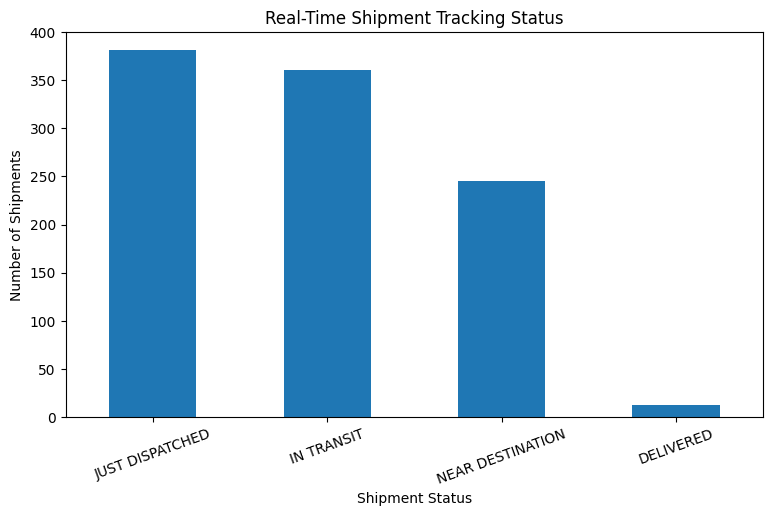

In [83]:
# ==========================================
# SHIPMENT TRACKING DASHBOARD
# ==========================================

status_counts = tracking_data[
    "tracking_status"
].value_counts()

plt.figure(figsize=(9, 5))

status_counts.plot(kind="bar")

plt.title("Real-Time Shipment Tracking Status")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=20)

plt.show()

In [84]:
critical_shipments = tracking_data[
    tracking_data["delay_alert"] == "CRITICAL DELAY"
].sort_values(
    "delay_risk_score",
    ascending=False
)

print("==========================================")
print("       CRITICAL SHIPMENT ALERTS")
print("==========================================")

display(
    critical_shipments[[
        "shipment_id",
        "progress_percent",
        "distance_remaining_km",
        "traffic_level",
        "weather",
        "status",
        "delay_risk_score",
        "delay_alert"
    ]].head(15)
)

       CRITICAL SHIPMENT ALERTS


,shipment_id,progress_percent,distance_remaining_km,traffic_level,weather,status,delay_risk_score,delay_alert
421,SHP00422,26,296.74,High,Storm,Delayed,100,CRITICAL DELAY
973,SHP00974,26,691.16,High,Storm,Delayed,100,CRITICAL DELAY
320,SHP00321,11,186.90,High,Storm,Delayed,100,CRITICAL DELAY
20,SHP00021,68,214.72,High,Storm,Delayed,90,CRITICAL DELAY
982,SHP00983,98,14.36,High,Storm,Delayed,90,CRITICAL DELAY
90,SHP00091,91,0.99,High,Storm,Delayed,90,CRITICAL DELAY
221,SHP00222,91,58.95,High,Storm,Delayed,90,CRITICAL DELAY
105,SHP00106,69,270.32,High,Storm,Delayed,90,CRITICAL DELAY
446,SHP00447,34,532.62,High,Storm,Delayed,90,CRITICAL DELAY
658,SHP00659,95,18.30,High,Storm,Delayed,90,CRITICAL DELAY


In [85]:
# ==========================================
# STEP 18 — LOGISTICS ANALYTICS DASHBOARD
# ==========================================

total_shipments = len(data)

delayed_shipments = (
    data["delayed"].sum()
)

on_time_shipments = (
    total_shipments - delayed_shipments
)

total_vehicles = len(vehicle_data)

maintenance_required = len(
    vehicle_data[
        vehicle_data["maintenance_status"].isin(
            ["URGENT", "MAINTENANCE REQUIRED"]
        )
    ]
)

stockout_risk_products = len(
    warehouse_data[
        warehouse_data["stock_out_risk"] == 1
    ]
)

average_eta = data[
    "delivery_time_hours"
].mean()

average_cost = data[
    "total_shipment_cost"
].mean()

print("==============================================")
print("       AI LOGISTICS MANAGEMENT DASHBOARD")
print("==============================================")
print("Total Shipments          :", total_shipments)
print("Delayed Shipments        :", delayed_shipments)
print("On-Time Shipments        :", on_time_shipments)
print("Total Vehicles           :", total_vehicles)
print("Maintenance Required     :", maintenance_required)
print("Stock-Out Risk Products  :", stockout_risk_products)
print("Average ETA              :", round(average_eta, 2), "hours")
print("Average Shipment Cost    : ₹", round(average_cost, 2))
print("==============================================")

       AI LOGISTICS MANAGEMENT DASHBOARD
Total Shipments          : 1000
Delayed Shipments        : 782
On-Time Shipments        : 218
Total Vehicles           : 500
Maintenance Required     : 478
Stock-Out Risk Products  : 83
Average ETA              : 16.24 hours
Average Shipment Cost    : ₹ 6957.13


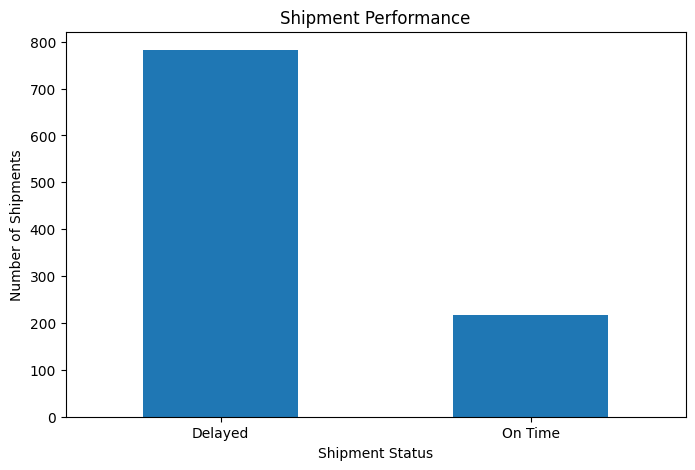

In [86]:
# ==========================================
# SHIPMENT PERFORMANCE
# ==========================================

shipment_status = data["status"].value_counts()

plt.figure(figsize=(8, 5))

shipment_status.plot(kind="bar")

plt.title("Shipment Performance")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)

plt.show()

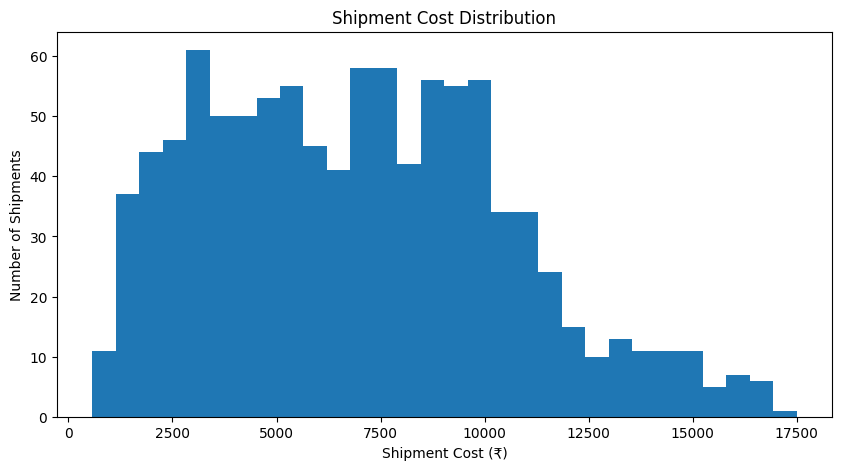

In [87]:
# ==========================================
# SHIPMENT COST ANALYSIS
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    data["total_shipment_cost"],
    bins=30
)

plt.title("Shipment Cost Distribution")
plt.xlabel("Shipment Cost (₹)")
plt.ylabel("Number of Shipments")

plt.show()

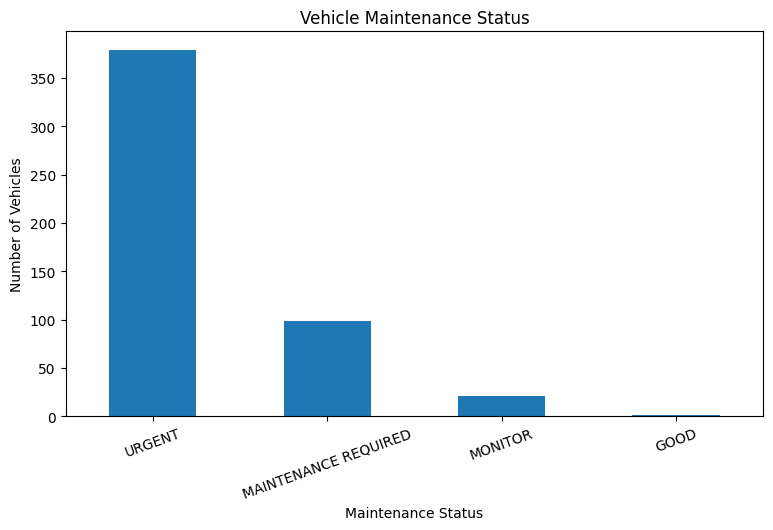

In [88]:
# ==========================================
# VEHICLE MAINTENANCE ANALYTICS
# ==========================================

maintenance_counts = (
    vehicle_data["maintenance_status"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

maintenance_counts.plot(kind="bar")

plt.title("Vehicle Maintenance Status")
plt.xlabel("Maintenance Status")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=20)

plt.show()

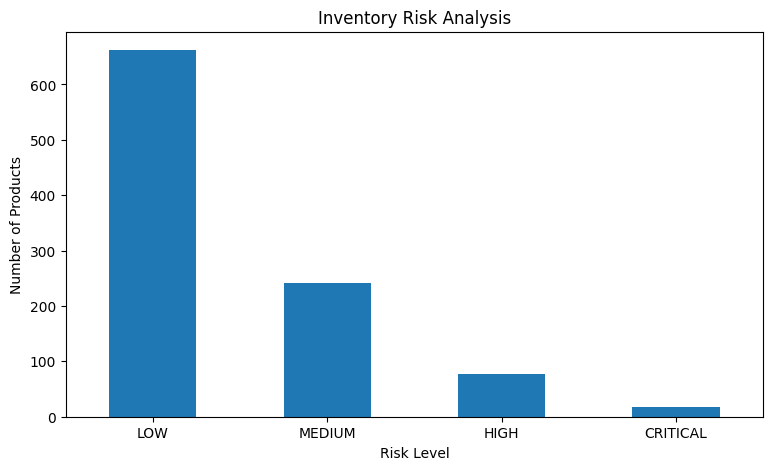

In [89]:
# ==========================================
# INVENTORY RISK ANALYTICS
# ==========================================

inventory_risk = (
    warehouse_data["risk_level"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

inventory_risk.plot(kind="bar")

plt.title("Inventory Risk Analysis")
plt.xlabel("Risk Level")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

plt.show()

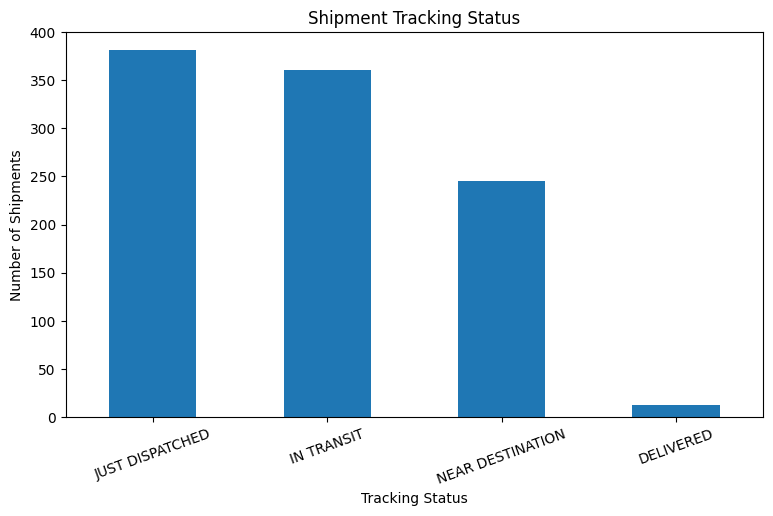

In [90]:
# ==========================================
# TRACKING ANALYTICS
# ==========================================

tracking_status_counts = (
    tracking_data["tracking_status"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

tracking_status_counts.plot(kind="bar")

plt.title("Shipment Tracking Status")
plt.xlabel("Tracking Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=20)

plt.show()

In [91]:
# ==========================================
# AI ALERT SUMMARY
# ==========================================

alert_counts = (
    tracking_data["delay_alert"]
    .value_counts()
)

print("==========================================")
print("          AI ALERT SUMMARY")
print("==========================================")

display(
    alert_counts.reset_index()
    .rename(
        columns={
            "index": "Alert Type",
            "delay_alert": "Shipments"
        }
    )
)

          AI ALERT SUMMARY


,Shipments,count
0,MEDIUM DELAY RISK,364
1,HIGH DELAY RISK,276
2,NORMAL,184
3,CRITICAL DELAY,176


In [92]:
# ==========================================
# TOP PRIORITY SHIPMENTS
# ==========================================

top_priority = data.sort_values(
    "priority_score",
    ascending=False
).head(10)

display(
    top_priority[[
        "shipment_id",
        "distance_km",
        "traffic_level",
        "weather",
        "status",
        "delivery_time_hours",
        "priority_score",
        "priority_level"
    ]]
)

,shipment_id,distance_km,traffic_level,weather,status,delivery_time_hours,priority_score,priority_level
258,SHP00259,984,Medium,Storm,Delayed,30.528557,70,CRITICAL
267,SHP00268,839,High,Rain,Delayed,27.694095,70,CRITICAL
105,SHP00106,872,High,Storm,Delayed,28.181087,69,HIGH
221,SHP00222,655,High,Storm,Delayed,26.991332,67,HIGH
899,SHP00900,938,High,Rain,Delayed,30.255805,67,HIGH
493,SHP00494,744,Medium,Storm,Delayed,25.873958,67,HIGH
352,SHP00353,955,Medium,Storm,Delayed,30.832315,67,HIGH
348,SHP00349,788,High,Rain,Delayed,25.343997,67,HIGH
36,SHP00037,757,Medium,Storm,Delayed,23.768131,67,HIGH
20,SHP00021,671,High,Storm,Delayed,26.869081,67,HIGH


In [93]:
# ==========================================
# FINAL KPI DASHBOARD
# ==========================================

print("\n")
print("╔══════════════════════════════════════════════╗")
print("║       AI LOGISTICS MANAGEMENT SYSTEM        ║")
print("╠══════════════════════════════════════════════╣")
print(f"║ Total Shipments       : {total_shipments:<15} ║")
print(f"║ On-Time Shipments     : {on_time_shipments:<15} ║")
print(f"║ Delayed Shipments     : {delayed_shipments:<15} ║")
print(f"║ Total Vehicles        : {total_vehicles:<15} ║")
print(f"║ Maintenance Required  : {maintenance_required:<15} ║")
print(f"║ Stock-Out Risk        : {stockout_risk_products:<15} ║")
print(f"║ Average ETA           : {average_eta:.2f} hours       ║")
print(f"║ Average Shipment Cost : ₹{average_cost:.2f}       ║")
print("╚══════════════════════════════════════════════╝")



╔══════════════════════════════════════════════╗
║       AI LOGISTICS MANAGEMENT SYSTEM        ║
╠══════════════════════════════════════════════╣
║ Total Shipments       : 1000            ║
║ On-Time Shipments     : 218             ║
║ Delayed Shipments     : 782             ║
║ Total Vehicles        : 500             ║
║ Maintenance Required  : 478             ║
║ Stock-Out Risk        : 83              ║
║ Average ETA           : 16.24 hours       ║
║ Average Shipment Cost : ₹6957.13       ║
╚══════════════════════════════════════════════╝


In [97]:
!pip install -q streamlit

In [98]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(
    page_title="AI Logistics Management",
    page_icon="🚚",
    layout="wide"
)

st.title("🚚 AI Logistics Management System")
st.subheader("Intelligent Shipment & Logistics Dashboard")

st.divider()

# ==========================================
# LOAD DATA
# ==========================================

# Demo data for dashboard
np.random.seed(42)

n = 100

dashboard_data = pd.DataFrame({
    "Shipment ID": [f"SHP{i:05d}" for i in range(1, n + 1)],
    "Distance (km)": np.random.randint(20, 1000, n),
    "Weight (kg)": np.random.randint(10, 500, n),
    "Status": np.random.choice(
        ["On Time", "Delayed"],
        n
    ),
    "Priority": np.random.choice(
        ["Low", "Medium", "High", "Critical"],
        n
    ),
    "Cost (₹)": np.random.randint(
        1000, 25000, n
    )
})

# ==========================================
# KPI SECTION
# ==========================================

total_shipments = len(dashboard_data)

delayed = len(
    dashboard_data[
        dashboard_data["Status"] == "Delayed"
    ]
)

on_time = total_shipments - delayed

average_cost = dashboard_data[
    "Cost (₹)"
].mean()

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "📦 Total Shipments",
    total_shipments
)

col2.metric(
    "✅ On-Time",
    on_time
)

col3.metric(
    "🚨 Delayed",
    delayed
)

col4.metric(
    "💰 Avg Cost",
    f"₹{average_cost:,.0f}"
)

st.divider()

# ==========================================
# SIDEBAR
# ==========================================

st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Select Module",
    [
        "Dashboard",
        "Shipments",
        "Delay Alerts",
        "Cost Analysis",
        "Inventory",
        "Vehicle Management"
    ]
)

# ==========================================
# DASHBOARD
# ==========================================

if page == "Dashboard":

    st.header("📊 Logistics Overview")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Shipment Status")

        status_count = (
            dashboard_data["Status"]
            .value_counts()
        )

        st.bar_chart(status_count)

    with col2:
        st.subheader("Priority Distribution")

        priority_count = (
            dashboard_data["Priority"]
            .value_counts()
        )

        st.bar_chart(priority_count)

# ==========================================
# SHIPMENTS
# ==========================================

elif page == "Shipments":

    st.header("📦 Shipment Management")

    search = st.text_input(
        "Search Shipment ID"
    )

    filtered_data = dashboard_data.copy()

    if search:
        filtered_data = filtered_data[
            filtered_data["Shipment ID"]
            .str.contains(
                search,
                case=False
            )
        ]

    st.dataframe(
        filtered_data,
        use_container_width=True
    )

# ==========================================
# DELAY ALERTS
# ==========================================

elif page == "Delay Alerts":

    st.header("🚨 AI Delay Alerts")

    delayed_data = dashboard_data[
        dashboard_data["Status"] == "Delayed"
    ]

    st.warning(
        f"{len(delayed_data)} shipments "
        "require attention."
    )

    st.dataframe(
        delayed_data,
        use_container_width=True
    )

# ==========================================
# COST ANALYSIS
# ==========================================

elif page == "Cost Analysis":

    st.header("💰 Shipment Cost Analysis")

    st.metric(
        "Total Transportation Cost",
        f"₹{dashboard_data['Cost (₹)'].sum():,.0f}"
    )

    st.line_chart(
        dashboard_data["Cost (₹)"]
    )

# ==========================================
# INVENTORY
# ==========================================

elif page == "Inventory":

    st.header("📦 AI Inventory Management")

    inventory = pd.DataFrame({
        "Product": [
            "P001", "P002", "P003",
            "P004", "P005"
        ],
        "Current Stock": [
            120, 45, 300, 20, 80
        ],
        "Predicted Demand": [
            100, 150, 250, 100, 70
        ]
    })

    inventory["Status"] = np.where(
        inventory["Current Stock"]
        < inventory["Predicted Demand"],
        "REORDER REQUIRED",
        "STOCK SUFFICIENT"
    )

    st.dataframe(
        inventory,
        use_container_width=True
    )

# ==========================================
# VEHICLE MANAGEMENT
# ==========================================

elif page == "Vehicle Management":

    st.header("🚚 Vehicle Management")

    vehicles = pd.DataFrame({
        "Vehicle ID": [
            "VH001",
            "VH002",
            "VH003",
            "VH004",
            "VH005"
        ],
        "Capacity (kg)": [
            100, 250, 500, 1000, 500
        ],
        "Status": [
            "Available",
            "In Transit",
            "Maintenance",
            "Available",
            "In Transit"
        ]
    })

    st.dataframe(
        vehicles,
        use_container_width=True
    )

st.divider()

st.caption(
    "AI-Integrated Intelligent Logistics "
    "and Shipment Management System"
)

Writing app.py


In [99]:
!streamlit run app.py &>/content/streamlit.log &

In [100]:
!pip install -q pyngrok

In [104]:
from pyngrok import ngrok

ngrok.kill()

In [105]:
!streamlit run app.py --server.port 8501 &>/content/streamlit.log &

In [107]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Dashboard URL:")
print(url)

Dashboard URL:
https://8501-m-s-kkb-usw3b1-op2u7jomtud1-b.us-west3-1.prod.colab.dev


In [108]:
!pkill -f streamlit

In [109]:
!pip install -q joblib

In [110]:
import joblib

joblib.dump(model, "delay_model.pkl")
joblib.dump(eta_model, "eta_model.pkl")
joblib.dump(demand_model, "demand_model.pkl")
joblib.dump(cost_model, "cost_model.pkl")
joblib.dump(maintenance_model, "maintenance_model.pkl")

print("======================================")
print(" AI MODELS SAVED SUCCESSFULLY")
print("======================================")
print("1. Delay Prediction Model")
print("2. ETA Prediction Model")
print("3. Demand Forecasting Model")
print("4. Cost Prediction Model")
print("5. Maintenance Prediction Model")

 AI MODELS SAVED SUCCESSFULLY
1. Delay Prediction Model
2. ETA Prediction Model
3. Demand Forecasting Model
4. Cost Prediction Model
5. Maintenance Prediction Model


In [111]:
data.to_csv("shipments.csv", index=False)
warehouse_data.to_csv("warehouse.csv", index=False)
vehicle_data.to_csv("vehicles.csv", index=False)
tracking_data.to_csv("tracking.csv", index=False)
drivers.to_csv("drivers.csv", index=False)
routes.to_csv("routes.csv", index=False)

print("======================================")
print(" LOGISTICS DATA SAVED")
print("======================================")
print("shipments.csv")
print("warehouse.csv")
print("vehicles.csv")
print("tracking.csv")
print("drivers.csv")
print("routes.csv")

 LOGISTICS DATA SAVED
shipments.csv
warehouse.csv
vehicles.csv
tracking.csv
drivers.csv
routes.csv


In [112]:
import os

files = [
    "delay_model.pkl",
    "eta_model.pkl",
    "demand_model.pkl",
    "cost_model.pkl",
    "maintenance_model.pkl",
    "shipments.csv",
    "warehouse.csv",
    "vehicles.csv",
    "tracking.csv",
    "drivers.csv",
    "routes.csv"
]

print("======================================")
print(" PROJECT FILE VERIFICATION")
print("======================================")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

 PROJECT FILE VERIFICATION
✅ delay_model.pkl
✅ eta_model.pkl
✅ demand_model.pkl
✅ cost_model.pkl
✅ maintenance_model.pkl
✅ shipments.csv
✅ warehouse.csv
✅ vehicles.csv
✅ tracking.csv
✅ drivers.csv
✅ routes.csv


In [113]:
loaded_delay_model = joblib.load("delay_model.pkl")
loaded_eta_model = joblib.load("eta_model.pkl")
loaded_demand_model = joblib.load("demand_model.pkl")
loaded_cost_model = joblib.load("cost_model.pkl")
loaded_maintenance_model = joblib.load("maintenance_model.pkl")

print("======================================")
print(" MODEL LOADING TEST")
print("======================================")
print("✅ All AI models loaded successfully")

 MODEL LOADING TEST
✅ All AI models loaded successfully


In [114]:
shipments_test = pd.read_csv("shipments.csv")

print("Shipment Records:", len(shipments_test))
print("Shipment Columns:", len(shipments_test.columns))

display(
    shipments_test[
        [
            "shipment_id",
            "distance_km",
            "traffic_level",
            "weather",
            "status",
            "priority_level"
        ]
    ].head(10)
)

Shipment Records: 1000
Shipment Columns: 23


,shipment_id,distance_km,traffic_level,weather,status,priority_level
0,SHP00001,112,Low,Clear,Delayed,MEDIUM
1,SHP00002,445,Medium,Rain,Delayed,HIGH
2,SHP00003,870,Low,Rain,Delayed,MEDIUM
3,SHP00004,280,Low,Rain,Delayed,MEDIUM
4,SHP00005,116,Medium,Clear,On Time,MEDIUM
5,SHP00006,81,Low,Rain,Delayed,MEDIUM
6,SHP00007,710,Medium,Rain,Delayed,HIGH
7,SHP00008,30,Medium,Rain,Delayed,MEDIUM
8,SHP00009,624,Low,Rain,Delayed,HIGH
9,SHP00010,131,Medium,Rain,Delayed,MEDIUM


In [115]:
print("""
==================================================
 AI-INTEGRATED INTELLIGENT LOGISTICS SYSTEM
==================================================

AI MODULES
-----------
✅ Shipment Delay Prediction
✅ ETA Prediction
✅ Shipment Priority Prediction
✅ Route Optimization
✅ Vehicle Allocation
✅ Inventory Demand Forecasting
✅ Stock-Out Risk Detection
✅ Shipment Cost Prediction
✅ Vehicle Maintenance Prediction
✅ Driver Assignment
✅ Real-Time Tracking
✅ AI Delay Alerts

DATA MODULES
------------
✅ Shipments
✅ Warehouse
✅ Vehicles
✅ Tracking
✅ Drivers
✅ Routes

STATUS: PROJECT DATA + AI MODELS READY
==================================================
""")


 AI-INTEGRATED INTELLIGENT LOGISTICS SYSTEM

AI MODULES
-----------
✅ Shipment Delay Prediction
✅ ETA Prediction
✅ Shipment Priority Prediction
✅ Route Optimization
✅ Vehicle Allocation
✅ Inventory Demand Forecasting
✅ Stock-Out Risk Detection
✅ Shipment Cost Prediction
✅ Vehicle Maintenance Prediction
✅ Driver Assignment
✅ Real-Time Tracking
✅ AI Delay Alerts

DATA MODULES
------------
✅ Shipments
✅ Warehouse
✅ Vehicles
✅ Tracking
✅ Drivers
✅ Routes

STATUS: PROJECT DATA + AI MODELS READY



In [116]:
!pip install -q plotly

In [117]:
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# ==========================================
# AI LOGISTICS MANAGEMENT DASHBOARD
# ==========================================

# ---------- KPI CALCULATIONS ----------

total_shipments = len(data)

delayed_shipments = int(data["delayed"].sum())

on_time_shipments = total_shipments - delayed_shipments

delay_rate = (delayed_shipments / total_shipments) * 100

average_eta = data["delivery_time_hours"].mean()

average_cost = data["total_shipment_cost"].mean()

total_cost = data["total_shipment_cost"].sum()

critical_shipments = len(
    data[data["priority_level"] == "CRITICAL"]
)

maintenance_alerts = len(
    vehicle_data[
        vehicle_data["maintenance_status"].isin(
            ["URGENT", "MAINTENANCE REQUIRED"]
        )
    ]
)

stockout_risk = len(
    warehouse_data[
        warehouse_data["stock_out_risk"] == 1
    ]
)


# ==========================================
# DASHBOARD HEADER
# ==========================================

display(HTML("""
<h1 style="text-align:center;">
🚚 AI-INTEGRATED INTELLIGENT LOGISTICS SYSTEM
</h1>

<h3 style="text-align:center;">
Shipment • Warehouse • Fleet • Tracking • AI Analytics
</h3>

<hr>
"""))


# ==========================================
# KPI CARDS
# ==========================================

kpi_html = f"""
<div style="display:flex; gap:15px;">

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; width:20%;">
<h3>📦 Shipments</h3>
<h2>{total_shipments}</h2>
</div>

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; width:20%;">
<h3>✅ On Time</h3>
<h2>{on_time_shipments}</h2>
</div>

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; width:20%;">
<h3>🚨 Delayed</h3>
<h2>{delayed_shipments}</h2>
</div>

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; width:20%;">
<h3>💰 Avg Cost</h3>
<h2>₹{average_cost:,.0f}</h2>
</div>

<div style="padding:20px; border:1px solid #ddd; border-radius:10px; width:20%;">
<h3>⏱️ Avg ETA</h3>
<h2>{average_eta:.2f} hrs</h2>
</div>

</div>
"""

display(HTML(kpi_html))


# ==========================================
# SHIPMENT STATUS
# ==========================================

status_count = data["status"].value_counts().reset_index()

status_count.columns = ["Status", "Count"]

fig1 = px.pie(
    status_count,
    names="Status",
    values="Count",
    title="📦 Shipment Status"
)

fig1.show()


# ==========================================
# PRIORITY ANALYSIS
# ==========================================

priority_count = (
    data["priority_level"]
    .value_counts()
    .reset_index()
)

priority_count.columns = ["Priority", "Count"]

fig2 = px.bar(
    priority_count,
    x="Priority",
    y="Count",
    title="🚨 Shipment Priority Distribution",
    text="Count"
)

fig2.show()


# ==========================================
# TRAFFIC ANALYSIS
# ==========================================

traffic_count = (
    data["traffic_level"]
    .value_counts()
    .reset_index()
)

traffic_count.columns = ["Traffic", "Shipments"]

fig3 = px.bar(
    traffic_count,
    x="Traffic",
    y="Shipments",
    title="🚦 Traffic Level Analysis",
    text="Shipments"
)

fig3.show()


# ==========================================
# WEATHER ANALYSIS
# ==========================================

weather_count = (
    data["weather"]
    .value_counts()
    .reset_index()
)

weather_count.columns = ["Weather", "Shipments"]

fig4 = px.bar(
    weather_count,
    x="Weather",
    y="Shipments",
    title="🌦️ Weather Impact on Shipments",
    text="Shipments"
)

fig4.show()


# ==========================================
# COST ANALYSIS
# ==========================================

fig5 = px.histogram(
    data,
    x="total_shipment_cost",
    nbins=30,
    title="💰 Shipment Cost Distribution"
)

fig5.update_xaxes(title="Shipment Cost (₹)")
fig5.update_yaxes(title="Number of Shipments")

fig5.show()


# ==========================================
# DISTANCE VS COST
# ==========================================

fig6 = px.scatter(
    data,
    x="distance_km",
    y="total_shipment_cost",
    color="status",
    title="📍 Distance vs Shipment Cost",
    hover_data=[
        "shipment_id",
        "weight_kg",
        "traffic_level"
    ]
)

fig6.show()


# ==========================================
# VEHICLE MAINTENANCE
# ==========================================

maintenance_count = (
    vehicle_data["maintenance_status"]
    .value_counts()
    .reset_index()
)

maintenance_count.columns = [
    "Maintenance Status",
    "Vehicles"
]

fig7 = px.bar(
    maintenance_count,
    x="Maintenance Status",
    y="Vehicles",
    title="🔧 Vehicle Maintenance Status",
    text="Vehicles"
)

fig7.show()


# ==========================================
# INVENTORY RISK
# ==========================================

risk_count = (
    warehouse_data["risk_level"]
    .value_counts()
    .reset_index()
)

risk_count.columns = [
    "Risk Level",
    "Products"
]

fig8 = px.bar(
    risk_count,
    x="Risk Level",
    y="Products",
    title="📦 AI Inventory Risk Analysis",
    text="Products"
)

fig8.show()


# ==========================================
# TRACKING STATUS
# ==========================================

tracking_count = (
    tracking_data["tracking_status"]
    .value_counts()
    .reset_index()
)

tracking_count.columns = [
    "Tracking Status",
    "Shipments"
]

fig9 = px.bar(
    tracking_count,
    x="Tracking Status",
    y="Shipments",
    title="📍 Real-Time Shipment Tracking",
    text="Shipments"
)

fig9.show()


# ==========================================
# AI DELAY ALERTS
# ==========================================

alert_count = (
    tracking_data["delay_alert"]
    .value_counts()
    .reset_index()
)

alert_count.columns = [
    "Alert",
    "Shipments"
]

fig10 = px.bar(
    alert_count,
    x="Alert",
    y="Shipments",
    title="🚨 AI Delay Alert Analysis",
    text="Shipments"
)

fig10.show()


# ==========================================
# TOP PRIORITY SHIPMENTS
# ==========================================

top_priority = data.sort_values(
    "priority_score",
    ascending=False
).head(15)

display(
    top_priority[
        [
            "shipment_id",
            "distance_km",
            "weight_kg",
            "traffic_level",
            "weather",
            "status",
            "priority_score",
            "priority_level"
        ]
    ].reset_index(drop=True)
)


# ==========================================
# FINAL SYSTEM SUMMARY
# ==========================================

display(HTML(f"""
<hr>

<h2>🤖 AI SYSTEM SUMMARY</h2>

<ul>
<li><b>Total Shipments:</b> {total_shipments}</li>
<li><b>On-Time Shipments:</b> {on_time_shipments}</li>
<li><b>Delayed Shipments:</b> {delayed_shipments}</li>
<li><b>Delay Rate:</b> {delay_rate:.2f}%</li>
<li><b>Critical Shipments:</b> {critical_shipments}</li>
<li><b>Average ETA:</b> {average_eta:.2f} hours</li>
<li><b>Total Logistics Cost:</b> ₹{total_cost:,.2f}</li>
<li><b>Maintenance Alerts:</b> {maintenance_alerts}</li>
<li><b>Stock-Out Risk Products:</b> {stockout_risk}</li>
</ul>

<h3>✅ AI Logistics Dashboard Generated Successfully</h3>

"""))

,shipment_id,distance_km,weight_kg,traffic_level,weather,status,priority_score,priority_level
0,SHP00259,984,228,Medium,Storm,Delayed,70,CRITICAL
1,SHP00268,839,83,High,Rain,Delayed,70,CRITICAL
2,SHP00106,872,30,High,Storm,Delayed,69,HIGH
3,SHP00222,655,111,High,Storm,Delayed,67,HIGH
4,SHP00900,938,450,High,Rain,Delayed,67,HIGH
5,SHP00494,744,436,Medium,Storm,Delayed,67,HIGH
6,SHP00353,955,356,Medium,Storm,Delayed,67,HIGH
7,SHP00349,788,38,High,Rain,Delayed,67,HIGH
8,SHP00037,757,85,Medium,Storm,Delayed,67,HIGH
9,SHP00021,671,476,High,Storm,Delayed,67,HIGH


In [118]:
!pip install -q ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 15.4 MB/s eta 0:00:00


In [119]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ==========================================
# AI SHIPMENT PREDICTION PANEL
# ==========================================

distance_input = widgets.IntSlider(
    value=300,
    min=10,
    max=1000,
    step=10,
    description="Distance:"
)

weight_input = widgets.IntSlider(
    value=100,
    min=1,
    max=500,
    step=1,
    description="Weight:"
)

capacity_input = widgets.Dropdown(
    options=[100, 250, 500, 1000],
    value=250,
    description="Capacity:"
)

traffic_input = widgets.Dropdown(
    options=["Low", "Medium", "High"],
    value="Medium",
    description="Traffic:"
)

weather_input = widgets.Dropdown(
    options=["Clear", "Rain", "Storm"],
    value="Clear",
    description="Weather:"
)

previous_delays_input = widgets.IntSlider(
    value=1,
    min=0,
    max=4,
    step=1,
    description="Prev. Delays:"
)

warehouse_input = widgets.FloatSlider(
    value=3,
    min=0.5,
    max=8,
    step=0.5,
    description="Warehouse Hrs:"
)

vehicle_age_input = widgets.IntSlider(
    value=3,
    min=1,
    max=15,
    step=1,
    description="Vehicle Age:"
)

predict_button = widgets.Button(
    description="🚀 RUN AI PREDICTION",
    button_style="success"
)

output = widgets.Output()


# ==========================================
# PREDICTION FUNCTION
# ==========================================

def run_ai_prediction(button):

    with output:

        clear_output()

        # ----------------------------------
        # INPUT VALUES
        # ----------------------------------

        distance = distance_input.value
        weight = weight_input.value
        capacity = capacity_input.value
        traffic = traffic_input.value
        weather = weather_input.value
        previous_delays = previous_delays_input.value
        warehouse_hours = warehouse_input.value
        vehicle_age = vehicle_age_input.value

        # ----------------------------------
        # AI SHIPMENT PREDICTION
        # ----------------------------------

        status, eta = predict_shipment(
            distance,
            weight,
            capacity,
            traffic,
            weather,
            previous_delays,
            warehouse_hours,
            vehicle_age
        )

        # ----------------------------------
        # PRIORITY
        # ----------------------------------

        priority_score, priority = calculate_priority(
            distance,
            weight,
            traffic,
            weather,
            previous_delays,
            warehouse_hours,
            status
        )

        # ----------------------------------
        # COST
        # ----------------------------------

        predicted_cost = predict_shipment_cost(
            distance,
            weight,
            capacity,
            traffic,
            weather,
            previous_delays,
            warehouse_hours,
            vehicle_age
        )

        # ----------------------------------
        # VEHICLE
        # ----------------------------------

        selected_vehicle = allocate_vehicle(
            weight,
            distance
        )

        # ----------------------------------
        # DRIVER
        # ----------------------------------

        selected_driver = assign_driver(distance)

        # ----------------------------------
        # ROUTE
        # ----------------------------------

        recommended_route = routes.loc[
            routes["route_score"].idxmin()
        ]

        # ==================================
        # DISPLAY RESULTS
        # ==================================

        display(HTML(f"""
        <h2>🤖 AI SHIPMENT ANALYSIS</h2>

        <hr>

        <h3>📦 Shipment Information</h3>

        <b>Distance:</b> {distance} km<br>
        <b>Weight:</b> {weight} kg<br>
        <b>Traffic:</b> {traffic}<br>
        <b>Weather:</b> {weather}<br>

        <hr>

        <h3>🧠 AI Predictions</h3>

        <b>🚨 Delivery Status:</b> {status}<br>
        <b>⏱️ Predicted ETA:</b> {eta:.2f} hours<br>
        <b>⭐ Priority Score:</b> {priority_score}/100<br>
        <b>📌 Priority Level:</b> {priority}<br>
        <b>💰 Estimated Shipment Cost:</b> ₹{predicted_cost:,.2f}<br>

        <hr>
        """))

        # ----------------------------------
        # VEHICLE RESULT
        # ----------------------------------

        if selected_vehicle is not None:

            display(HTML(f"""
            <h3>🚚 Vehicle Recommendation</h3>

            <b>Vehicle ID:</b>
            {selected_vehicle["vehicle_id"]}<br>

            <b>Vehicle Type:</b>
            {selected_vehicle["vehicle_type"]}<br>

            <b>Capacity:</b>
            {selected_vehicle["capacity_kg"]} kg<br>

            <b>Fuel Efficiency:</b>
            {selected_vehicle["fuel_efficiency_kmpl"]} km/l<br>
            """))

        else:

            display(HTML("""
            <h3>⚠️ Vehicle Recommendation</h3>
            No suitable vehicle available for this shipment.
            """))

        # ----------------------------------
        # DRIVER RESULT
        # ----------------------------------

        display(HTML(f"""
        <hr>

        <h3>👨‍✈️ Driver Recommendation</h3>

        <b>Driver ID:</b>
        {selected_driver["driver_id"]}<br>

        <b>Experience:</b>
        {selected_driver["experience_years"]} years<br>

        <b>Performance Score:</b>
        {selected_driver["performance_score"]}<br>

        <b>Driver AI Score:</b>
        {calculate_driver_score(
            selected_driver,
            distance
        ):.2f}<br>
        """))

        # ----------------------------------
        # ROUTE RESULT
        # ----------------------------------

        display(HTML(f"""
        <hr>

        <h3>🛣️ Recommended Route</h3>

        <b>Route:</b>
        {recommended_route["route_id"]}<br>

        <b>Distance:</b>
        {recommended_route["distance_km"]} km<br>

        <b>Traffic:</b>
        {recommended_route["traffic_level"]}<br>

        <b>Estimated Time:</b>
        {recommended_route["estimated_time_hours"]} hours<br>

        <b>Toll Cost:</b>
        ₹{recommended_route["toll_cost"]}<br>

        <hr>

        <h3>✅ AI Decision Complete</h3>
        """))


predict_button.on_click(run_ai_prediction)


# ==========================================
# DISPLAY INTERFACE
# ==========================================

display(
    HTML("""
    <h1>🚚 AI Shipment Decision Engine</h1>
    <p>
    Enter shipment information and let the AI system
    generate logistics recommendations.
    </p>
    """)
)

display(distance_input)
display(weight_input)
display(capacity_input)
display(traffic_input)
display(weather_input)
display(previous_delays_input)
display(warehouse_input)
display(vehicle_age_input)

display(predict_button)

display(output)

IntSlider(value=300, description='Distance:', max=1000, min=10, step=10)

IntSlider(value=100, description='Weight:', max=500, min=1)

Dropdown(description='Capacity:', index=1, options=(100, 250, 500, 1000), value=250)

Dropdown(description='Traffic:', index=1, options=('Low', 'Medium', 'High'), value='Medium')

Dropdown(description='Weather:', options=('Clear', 'Rain', 'Storm'), value='Clear')

IntSlider(value=1, description='Prev. Delays:', max=4)

FloatSlider(value=3.0, description='Warehouse Hrs:', max=8.0, min=0.5, step=0.5)

IntSlider(value=3, description='Vehicle Age:', max=15, min=1)

Button(button_style='success', description='🚀 RUN AI PREDICTION', style=ButtonStyle())

Output()

In [120]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ==========================================
# SHIPMENT SEARCH ENGINE
# ==========================================

shipment_search = widgets.Text(
    value="SHP00001",
    placeholder="Enter Shipment ID e.g. SHP00001",
    description="Shipment ID:"
)

search_button = widgets.Button(
    description="🔎 SEARCH SHIPMENT",
    button_style="info"
)

search_output = widgets.Output()


# ==========================================
# SEARCH FUNCTION
# ==========================================

def search_shipment(button):

    with search_output:

        clear_output()

        shipment_id = shipment_search.value.strip().upper()

        # Search shipment
        shipment_result = data[
            data["shipment_id"].str.upper() == shipment_id
        ]

        # Search tracking information
        tracking_result = tracking_data[
            tracking_data["shipment_id"].str.upper() == shipment_id
        ]

        # --------------------------------------
        # SHIPMENT NOT FOUND
        # --------------------------------------

        if shipment_result.empty:

            display(HTML(f"""
            <div style="
                padding:20px;
                border:1px solid #ddd;
                border-radius:10px;
            ">

            <h3>❌ Shipment Not Found</h3>

            No shipment found with ID:

            <b>{shipment_id}</b>

            <br><br>

            Try an ID such as:

            <b>SHP00001</b>

            </div>
            """))

            return

        # --------------------------------------
        # GET DATA
        # --------------------------------------

        shipment = shipment_result.iloc[0]

        # --------------------------------------
        # TRACKING DATA
        # --------------------------------------

        if not tracking_result.empty:
            tracking = tracking_result.iloc[0]

            progress = tracking["progress_percent"]
            tracking_status_value = tracking["tracking_status"]
            delay_risk = tracking["delay_risk_score"]
            delay_alert = tracking["delay_alert"]

        else:

            progress = 0
            tracking_status_value = "UNKNOWN"
            delay_risk = 0
            delay_alert = "UNKNOWN"

        # ======================================
        # DISPLAY SHIPMENT INFORMATION
        # ======================================

        display(HTML(f"""

        <h2>📦 SHIPMENT DETAILS</h2>

        <hr>

        <b>Shipment ID:</b>
        {shipment["shipment_id"]}<br><br>

        <b>Distance:</b>
        {shipment["distance_km"]} km<br>

        <b>Weight:</b>
        {shipment["weight_kg"]} kg<br>

        <b>Vehicle Capacity:</b>
        {shipment["vehicle_capacity_kg"]} kg<br>

        <b>Traffic:</b>
        {shipment["traffic_level"]}<br>

        <b>Weather:</b>
        {shipment["weather"]}<br>

        <b>Previous Delays:</b>
        {shipment["previous_delays"]}<br>

        <hr>

        <h3>🤖 AI ANALYSIS</h3>

        <b>Delivery Status:</b>
        {shipment["status"]}<br>

        <b>Predicted Delivery Time:</b>
        {shipment["delivery_time_hours"]:.2f} hours<br>

        <b>Priority Score:</b>
        {shipment["priority_score"]}/100<br>

        <b>Priority Level:</b>
        {shipment["priority_level"]}<br>

        <b>Estimated Shipment Cost:</b>
        ₹{shipment["total_shipment_cost"]:,.2f}<br>

        <hr>

        <h3>📍 LIVE TRACKING</h3>

        <b>Tracking Status:</b>
        {tracking_status_value}<br>

        <b>Progress:</b>
        {progress}%<br>

        <b>Distance Completed:</b>
        {tracking["distance_completed_km"]:.2f} km<br>

        <b>Distance Remaining:</b>
        {tracking["distance_remaining_km"]:.2f} km<br>

        <b>Estimated Remaining Time:</b>
        {tracking["estimated_remaining_hours"]:.2f} hours<br>

        <hr>

        <h3>🚨 AI DELAY MONITOR</h3>

        <b>Delay Risk Score:</b>
        {delay_risk}/100<br>

        <b>AI Alert:</b>
        {delay_alert}<br>

        </div>
        """))

        # ======================================
        # PROGRESS BAR
        # ======================================

        progress_html = f"""
        <h3>📍 Shipment Progress</h3>

        <div style="
            width:100%;
            background:#ddd;
            border-radius:10px;
            height:25px;
        ">

            <div style="
                width:{progress}%;
                height:25px;
                border-radius:10px;
                background:#2196F3;
                text-align:center;
                color:white;
            ">

            {progress}%

            </div>

        </div>
        """

        display(HTML(progress_html))


# ==========================================
# BUTTON EVENT
# ==========================================

search_button.on_click(search_shipment)


# ==========================================
# DISPLAY SEARCH INTERFACE
# ==========================================

display(HTML("""
<h1>🔎 AI Shipment Search & Tracking</h1>

<p>
Enter a Shipment ID to retrieve complete
shipment information and AI analysis.
</p>
"""))

display(shipment_search)
display(search_button)
display(search_output)

Text(value='SHP00001', description='Shipment ID:', placeholder='Enter Shipment ID e.g. SHP00001')

Button(button_style='info', description='🔎 SEARCH SHIPMENT', style=ButtonStyle())

Output()

In [122]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ==========================================
# AI LOGISTICS COMMAND CENTER
# ==========================================

command_shipment = widgets.Text(
    value="SHP00001",
    placeholder="Enter Shipment ID",
    description="Shipment ID:"
)

command_button = widgets.Button(
    description="🤖 RUN AI COMMAND CENTER",
    button_style="success"
)

command_output = widgets.Output()


# ==========================================
# COMMAND CENTER FUNCTION
# ==========================================

def run_command_center(button):

    with command_output:

        clear_output()

        shipment_id = command_shipment.value.strip().upper()

        # ----------------------------------
        # FIND SHIPMENT
        # ----------------------------------

        shipment_result = data[
            data["shipment_id"].str.upper() == shipment_id
        ]

        if shipment_result.empty:

            display(HTML(f"""
            <h2>❌ SHIPMENT NOT FOUND</h2>

            Shipment ID:
            <b>{shipment_id}</b>

            <br><br>

            Please enter a valid ID such as:
            <b>SHP00001</b>
            """))

            return

        shipment = shipment_result.iloc[0]

        # ----------------------------------
        # TRACKING
        # ----------------------------------

        tracking_result = tracking_data[
            tracking_data["shipment_id"].str.upper() == shipment_id
        ]

        if not tracking_result.empty:
            tracking = tracking_result.iloc[0]
        else:
            tracking = None

        # ----------------------------------
        # AI DELAY PREDICTION
        # ----------------------------------

        status, predicted_eta = predict_shipment(
            shipment["distance_km"],
            shipment["weight_kg"],
            shipment["vehicle_capacity_kg"],
            shipment["traffic_level"],
            shipment["weather"],
            shipment["previous_delays"],
            shipment["warehouse_processing_hours"],
            shipment["vehicle_age_years"]
        )

        # ----------------------------------
        # PRIORITY
        # ----------------------------------

        priority_score, priority = calculate_priority(
            shipment["distance_km"],
            shipment["weight_kg"],
            shipment["traffic_level"],
            shipment["weather"],
            shipment["previous_delays"],
            shipment["warehouse_processing_hours"],
            status
        )

        # ----------------------------------
        # COST
        # ----------------------------------

        predicted_cost = predict_shipment_cost(
            shipment["distance_km"],
            shipment["weight_kg"],
            shipment["vehicle_capacity_kg"],
            shipment["traffic_level"],
            shipment["weather"],
            shipment["previous_delays"],
            shipment["warehouse_processing_hours"],
            shipment["vehicle_age_years"]
        )

        # ----------------------------------
        # VEHICLE
        # ----------------------------------

        selected_vehicle = allocate_vehicle(
            shipment["weight_kg"],
            shipment["distance_km"]
        )

        # ----------------------------------
        # DRIVER
        # ----------------------------------

        selected_driver = assign_driver(
            shipment["distance_km"]
        )

        # ----------------------------------
        # ROUTE
        # ----------------------------------

        recommended_route = routes.loc[
            routes["route_score"].idxmin()
        ]

        # ==================================
        # FINAL AI DECISION
        # ==================================

        if priority == "CRITICAL":
            final_action = "IMMEDIATE ACTION REQUIRED"

        elif priority == "HIGH":
            final_action = "PRIORITY MONITORING REQUIRED"

        elif status == "DELAYED":
            final_action = "MONITOR SHIPMENT"

        else:
            final_action = "NORMAL OPERATIONS"

        # ==================================
        # COMMAND CENTER HEADER
        # ==================================

        display(HTML(f"""
        <div style="
            padding:20px;
            border-radius:12px;
            border:2px solid #333;
        ">

        <h1>🤖 AI LOGISTICS COMMAND CENTER</h1>

        <h2>Shipment: {shipment_id}</h2>

        </div>
        """))

        # ==================================
        # SHIPMENT OVERVIEW
        # ==================================

        display(HTML(f"""

        <h2>📦 SHIPMENT OVERVIEW</h2>

        <b>Distance:</b>
        {shipment["distance_km"]} km<br>

        <b>Weight:</b>
        {shipment["weight_kg"]} kg<br>

        <b>Traffic:</b>
        {shipment["traffic_level"]}<br>

        <b>Weather:</b>
        {shipment["weather"]}<br>

        <b>Previous Delays:</b>
        {shipment["previous_delays"]}<br>

        """))

        # ==================================
        # AI PREDICTION
        # ==================================

        display(HTML(f"""

        <hr>

        <h2>🧠 AI PREDICTION</h2>

        <b>🚨 Delivery Status:</b>
        {status}<br><br>

        <b>⏱️ Predicted ETA:</b>
        {predicted_eta:.2f} hours<br><br>

        <b>⭐ Priority Score:</b>
        {priority_score}/100<br><br>

        <b>📌 Priority Level:</b>
        {priority}<br><br>

        <b>💰 Predicted Cost:</b>
        ₹{predicted_cost:,.2f}

        """))

        # ==================================
        # VEHICLE
        # ==================================

        if selected_vehicle is not None:

            display(HTML(f"""

            <hr>

            <h2>🚚 VEHICLE ALLOCATION</h2>

            <b>Vehicle:</b>
            {selected_vehicle["vehicle_id"]}<br>

            <b>Type:</b>
            {selected_vehicle["vehicle_type"]}<br>

            <b>Capacity:</b>
            {selected_vehicle["capacity_kg"]} kg<br>

            <b>Fuel Efficiency:</b>
            {selected_vehicle["fuel_efficiency_kmpl"]} km/l

            """))

        else:

            display(HTML("""
            <hr>
            <h2>⚠️ VEHICLE ALLOCATION</h2>
            No suitable vehicle available.
            """))

        # ==================================
        # DRIVER
        # ==================================

        driver_score = calculate_driver_score(
            selected_driver,
            shipment["distance_km"]
        )

        display(HTML(f"""

        <hr>

        <h2>👨‍✈️ DRIVER ASSIGNMENT</h2>

        <b>Driver:</b>
        {selected_driver["driver_id"]}<br>

        <b>Experience:</b>
        {selected_driver["experience_years"]} years<br>

        <b>Performance:</b>
        {selected_driver["performance_score"]}<br>

        <b>AI Driver Score:</b>
        {driver_score:.2f}

        """))

        # ==================================
        # ROUTE
        # ==================================

        display(HTML(f"""

        <hr>

        <h2>🛣️ ROUTE RECOMMENDATION</h2>

        <b>Route:</b>
        {recommended_route["route_id"]}<br>

        <b>Distance:</b>
        {recommended_route["distance_km"]} km<br>

        <b>Traffic:</b>
        {recommended_route["traffic_level"]}<br>

        <b>Estimated Time:</b>
        {recommended_route["estimated_time_hours"]} hours<br>

        <b>Toll:</b>
        ₹{recommended_route["toll_cost"]}<br>

        <b>Route Score:</b>
        {recommended_route["route_score"]:.2f}

        """))

        # ==================================
        # TRACKING
        # ==================================

        if tracking is not None:

            display(HTML(f"""

            <hr>

            <h2>📍 SHIPMENT TRACKING</h2>

            <b>Status:</b>
            {tracking["tracking_status"]}<br>

            <b>Progress:</b>
            {tracking["progress_percent"]}%<br>

            <b>Distance Completed:</b>
            {tracking["distance_completed_km"]:.2f} km<br>

            <b>Distance Remaining:</b>
            {tracking["distance_remaining_km"]:.2f} km<br>

            <b>Delay Risk:</b>
            {tracking["delay_risk_score"]}/100<br>

            <b>AI Alert:</b>
            {tracking["delay_alert"]}

            """))

        # ==================================
        # FINAL DECISION
        # ==================================

        display(HTML(f"""

        <hr>

        <h2>🎯 FINAL AI DECISION</h2>

        <div style="
            padding:20px;
            border-radius:10px;
            border:2px solid #555;
        ">

        <h2>{final_action}</h2>

        <p>
        The AI system has analyzed shipment conditions,
        delivery risk, cost, vehicle availability,
        driver performance and route efficiency.
        </p>

        </div>

        <hr>

        <h2>✅ AI COMMAND CENTER ANALYSIS COMPLETE</h2>

        """))


# ==========================================
# BUTTON EVENT
# ==========================================

command_button.on_click(run_command_center)


# ==========================================
# DISPLAY
# ==========================================

display(HTML("""
<h1>🤖 AI Logistics Command Center</h1>

<p>
Enter a Shipment ID to generate a complete
AI-powered logistics decision report.
</p>
"""))

display(command_shipment)
display(command_button)
display(command_output)


Text(value='SHP00001', description='Shipment ID:', placeholder='Enter Shipment ID')

Button(button_style='success', description='🤖 RUN AI COMMAND CENTER', style=ButtonStyle())

Output()

In [123]:
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 11.5 MB/s eta 0:00:00


In [124]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak
)
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import inch

# ==========================================
# REPORT CALCULATIONS
# ==========================================

total_shipments = len(data)

delayed_shipments = int(data["delayed"].sum())

on_time_shipments = total_shipments - delayed_shipments

delay_rate = (
    delayed_shipments / total_shipments
) * 100

average_eta = data["delivery_time_hours"].mean()

average_cost = data["total_shipment_cost"].mean()

total_cost = data["total_shipment_cost"].sum()

critical_shipments = len(
    data[data["priority_level"] == "CRITICAL"]
)

high_priority_shipments = len(
    data[data["priority_level"] == "HIGH"]
)

maintenance_alerts = len(
    vehicle_data[
        vehicle_data["maintenance_status"].isin(
            ["URGENT", "MAINTENANCE REQUIRED"]
        )
    ]
)

stockout_risk = len(
    warehouse_data[
        warehouse_data["stock_out_risk"] == 1
    ]
)

critical_delay_alerts = len(
    tracking_data[
        tracking_data["delay_alert"] == "CRITICAL DELAY"
    ]
)

# ==========================================
# PDF SETUP
# ==========================================

pdf_file = "AI_Logistics_Management_Report.pdf"

doc = SimpleDocTemplate(
    pdf_file,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleStyle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=20,
    spaceAfter=15
)

heading_style = ParagraphStyle(
    "HeadingStyle",
    parent=styles["Heading2"],
    fontSize=14,
    spaceBefore=12,
    spaceAfter=8
)

normal_style = ParagraphStyle(
    "NormalStyle",
    parent=styles["BodyText"],
    fontSize=9,
    leading=13
)

story = []

# ==========================================
# TITLE
# ==========================================

story.append(
    Paragraph(
        "AI-INTEGRATED INTELLIGENT<br/>"
        "LOGISTICS & SHIPMENT MANAGEMENT SYSTEM",
        title_style
    )
)

story.append(
    Paragraph(
        "Automated Logistics Management Report",
        ParagraphStyle(
            "subtitle",
            parent=styles["BodyText"],
            alignment=TA_CENTER,
            fontSize=11
        )
    )
)

story.append(Spacer(1, 20))

# ==========================================
# EXECUTIVE SUMMARY
# ==========================================

story.append(
    Paragraph(
        "1. Executive Summary",
        heading_style
    )
)

summary_text = f"""
The AI Logistics Management System analyzed
{total_shipments} shipment records using machine
learning, rule-based optimization and logistics
analytics.

The system identified {delayed_shipments} delayed
shipments, {critical_shipments} critical-priority
shipments, {stockout_risk} inventory stock-out risks
and {maintenance_alerts} vehicle maintenance alerts.

The average predicted delivery time is
{average_eta:.2f} hours, while the average shipment
cost is ₹{average_cost:,.2f}.
"""

story.append(
    Paragraph(summary_text, normal_style)
)

story.append(Spacer(1, 10))

# ==========================================
# KPI TABLE
# ==========================================

story.append(
    Paragraph(
        "2. Key Performance Indicators",
        heading_style
    )
)

kpi_data = [
    ["Metric", "Value"],
    ["Total Shipments", f"{total_shipments}"],
    ["On-Time Shipments", f"{on_time_shipments}"],
    ["Delayed Shipments", f"{delayed_shipments}"],
    ["Delay Rate", f"{delay_rate:.2f}%"],
    ["Average ETA", f"{average_eta:.2f} hours"],
    ["Average Shipment Cost", f"₹{average_cost:,.2f}"],
    ["Total Logistics Cost", f"₹{total_cost:,.2f}"],
    ["Critical Shipments", f"{critical_shipments}"],
    ["High Priority Shipments", f"{high_priority_shipments}"],
]

kpi_table = Table(
    kpi_data,
    colWidths=[260, 180]
)

kpi_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("ALIGN", (1, 1), (1, -1), "RIGHT"),
        ("PADDING", (0, 0), (-1, -1), 6),
    ])
)

story.append(kpi_table)

# ==========================================
# AI MODULES
# ==========================================

story.append(
    Paragraph(
        "3. AI Modules Implemented",
        heading_style
    )
)

ai_modules = [
    "Shipment Delay Prediction",
    "ETA Prediction",
    "Shipment Priority Scoring",
    "Route Optimization",
    "Vehicle Allocation",
    "Inventory Demand Forecasting",
    "Stock-Out Risk Detection",
    "Shipment Cost Prediction",
    "Vehicle Maintenance Prediction",
    "Driver Assignment",
    "Real-Time Shipment Tracking",
    "AI Delay Alerts"
]

for module in ai_modules:
    story.append(
        Paragraph(
            "• " + module,
            normal_style
        )
    )

# ==========================================
# INVENTORY
# ==========================================

story.append(
    Paragraph(
        "4. Inventory Risk Analysis",
        heading_style
    )
)

inventory_data = [
    ["Risk Level", "Number of Products"]
]

risk_counts = (
    warehouse_data["risk_level"]
    .value_counts()
)

for level in ["CRITICAL", "HIGH", "MEDIUM", "LOW"]:
    inventory_data.append([
        level,
        str(risk_counts.get(level, 0))
    ])

inventory_table = Table(
    inventory_data,
    colWidths=[260, 180]
)

inventory_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("PADDING", (0, 0), (-1, -1), 6),
    ])
)

story.append(inventory_table)

# ==========================================
# VEHICLE MAINTENANCE
# ==========================================

story.append(
    Paragraph(
        "5. Vehicle Maintenance Analysis",
        heading_style
    )
)

maintenance_counts = (
    vehicle_data["maintenance_status"]
    .value_counts()
)

maintenance_table_data = [
    ["Status", "Vehicles"]
]

for status_name, count in maintenance_counts.items():
    maintenance_table_data.append([
        status_name,
        str(count)
    ])

maintenance_table = Table(
    maintenance_table_data,
    colWidths=[260, 180]
)

maintenance_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("PADDING", (0, 0), (-1, -1), 6),
    ])
)

story.append(maintenance_table)

# ==========================================
# DELAY ALERTS
# ==========================================

story.append(
    Paragraph(
        "6. AI Delay Alert Analysis",
        heading_style
    )
)

alert_counts = (
    tracking_data["delay_alert"]
    .value_counts()
)

alert_table_data = [
    ["AI Alert", "Shipments"]
]

for alert, count in alert_counts.items():
    alert_table_data.append([
        alert,
        str(count)
    ])

alert_table = Table(
    alert_table_data,
    colWidths=[260, 180]
)

alert_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("PADDING", (0, 0), (-1, -1), 6),
    ])
)

story.append(alert_table)

# ==========================================
# CRITICAL SHIPMENTS
# ==========================================

story.append(
    PageBreak()
)

story.append(
    Paragraph(
        "7. Top Critical Shipments",
        heading_style
    )
)

critical_data = data[
    data["priority_level"].isin(
        ["CRITICAL", "HIGH"]
    )
].sort_values(
    "priority_score",
    ascending=False
).head(15)

critical_table_data = [
    [
        "Shipment",
        "Distance",
        "Status",
        "Priority",
        "Score"
    ]
]

for _, row in critical_data.iterrows():

    critical_table_data.append([
        row["shipment_id"],
        f'{row["distance_km"]} km',
        row["status"],
        row["priority_level"],
        f'{row["priority_score"]}'
    ])

critical_table = Table(
    critical_table_data,
    colWidths=[100, 80, 90, 90, 70]
)

critical_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("PADDING", (0, 0), (-1, -1), 5),
        ("FONTSIZE", (0, 0), (-1, -1), 8),
    ])
)

story.append(critical_table)

# ==========================================
# RECOMMENDATIONS
# ==========================================

story.append(
    Paragraph(
        "8. AI-Based Management Recommendations",
        heading_style
    )
)

recommendations = [
    "Prioritize shipments classified as CRITICAL or HIGH.",
    "Monitor shipments with high AI delay-risk scores.",
    "Schedule preventive maintenance for vehicles marked URGENT.",
    "Reorder products with high stock-out risk.",
    "Use AI vehicle allocation to match shipment weight with suitable capacity.",
    "Assign experienced drivers to long-distance shipments.",
    "Use route optimization to reduce travel time and transportation cost.",
    "Continuously monitor traffic and weather conditions.",
    "Use ETA predictions for proactive customer communication.",
    "Retrain models periodically when real operational data becomes available."
]

for recommendation in recommendations:
    story.append(
        Paragraph(
            "• " + recommendation,
            normal_style
        )
    )

# ==========================================
# CONCLUSION
# ==========================================

story.append(
    Paragraph(
        "9. Conclusion",
        heading_style
    )
)

conclusion = """
The developed system integrates logistics management
with artificial intelligence to support shipment
prediction, tracking, cost estimation, inventory
planning, vehicle maintenance and operational
decision-making.

The current implementation uses synthetic data for
demonstration and academic development. For production
deployment, the models should be trained and validated
using real historical logistics data.
"""

story.append(
    Paragraph(
        conclusion,
        normal_style
    )
)

# ==========================================
# BUILD PDF
# ==========================================

doc.build(story)

print("==========================================")
print(" AI LOGISTICS REPORT GENERATED")
print("==========================================")
print("File:", pdf_file)

 AI LOGISTICS REPORT GENERATED
File: AI_Logistics_Management_Report.pdf


In [125]:
from google.colab import files

files.download("AI_Logistics_Management_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [126]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ==========================================
# AI LOGISTICS CHATBOT
# ==========================================

chat_input = widgets.Text(
    placeholder="Ask your logistics question...",
    description="You:"
)

chat_button = widgets.Button(
    description="🤖 ASK AI",
    button_style="success"
)

chat_output = widgets.Output()


# ==========================================
# CHATBOT ENGINE
# ==========================================

def logistics_chatbot(question):

    q = question.lower().strip()

    # --------------------------------------
    # TOTAL SHIPMENTS
    # --------------------------------------

    if (
        "total shipment" in q
        or "how many shipment" in q
        or "number of shipment" in q
    ):
        return f"""
        📦 Total Shipments: {len(data)}
        """

    # --------------------------------------
    # DELAYED SHIPMENTS
    # --------------------------------------

    elif (
        "delayed shipment" in q
        or "how many delayed" in q
        or "delay shipment" in q
    ):
        delayed = int(data["delayed"].sum())

        return f"""
        🚨 Delayed Shipments: {delayed}

        Delay Rate:
        {(delayed / len(data)) * 100:.2f}%
        """

    # --------------------------------------
    # ON-TIME SHIPMENTS
    # --------------------------------------

    elif (
        "on time" in q
        or "on-time" in q
        or "ontime" in q
    ):
        on_time = len(data) - int(data["delayed"].sum())

        return f"""
        ✅ On-Time Shipments: {on_time}

        On-Time Rate:
        {(on_time / len(data)) * 100:.2f}%
        """

    # --------------------------------------
    # HIGHEST PRIORITY
    # --------------------------------------

    elif (
        "highest priority" in q
        or "top priority" in q
        or "most critical shipment" in q
    ):

        row = data.loc[
            data["priority_score"].idxmax()
        ]

        return f"""
        🚨 Highest Priority Shipment

        Shipment ID: {row["shipment_id"]}
        Priority Score: {row["priority_score"]}/100
        Priority Level: {row["priority_level"]}
        Status: {row["status"]}
        Distance: {row["distance_km"]} km
        """

    # --------------------------------------
    # CRITICAL SHIPMENTS
    # --------------------------------------

    elif (
        "critical shipment" in q
        or "critical shipments" in q
    ):

        critical = data[
            data["priority_level"] == "CRITICAL"
        ]

        if critical.empty:
            return "✅ No critical shipments found."

        top = critical.sort_values(
            "priority_score",
            ascending=False
        ).head(10)

        result = "🚨 Critical Shipments:\n\n"

        for _, row in top.iterrows():
            result += (
                f'{row["shipment_id"]} | '
                f'Score: {row["priority_score"]} | '
                f'Status: {row["status"]}\n'
            )

        return result

    # --------------------------------------
    # AVERAGE COST
    # --------------------------------------

    elif (
        "average cost" in q
        or "avg cost" in q
        or "shipment cost" in q
    ):

        average_cost = data[
            "total_shipment_cost"
        ].mean()

        return f"""
        💰 Average Shipment Cost:
        ₹{average_cost:,.2f}

        Total Logistics Cost:
        ₹{data["total_shipment_cost"].sum():,.2f}
        """

    # --------------------------------------
    # ETA
    # --------------------------------------

    elif (
        "average eta" in q
        or "delivery time" in q
        or "average delivery" in q
    ):

        eta = data[
            "delivery_time_hours"
        ].mean()

        return f"""
        ⏱️ Average Delivery Time:
        {eta:.2f} hours
        """

    # --------------------------------------
    # VEHICLE MAINTENANCE
    # --------------------------------------

    elif (
        "maintenance" in q
        or "vehicle maintenance" in q
        or "vehicle need" in q
    ):

        maintenance = vehicle_data[
            vehicle_data["maintenance_status"].isin(
                ["URGENT", "MAINTENANCE REQUIRED"]
            )
        ]

        result = f"""
        🔧 Vehicles Requiring Maintenance:
        {len(maintenance)}

        """

        if not maintenance.empty:

            result += "\nTop Maintenance Alerts:\n\n"

            for _, row in maintenance.sort_values(
                "maintenance_risk",
                ascending=False
            ).head(10).iterrows():

                result += (
                    f'{row["vehicle_id"]} | '
                    f'Risk: {row["maintenance_risk"]:.1f} | '
                    f'Status: {row["maintenance_status"]}\n'
                )

        return result

    # --------------------------------------
    # INVENTORY / STOCK OUT
    # --------------------------------------

    elif (
        "stock out" in q
        or "stockout" in q
        or "inventory risk" in q
        or "inventory" in q
    ):

        risk = warehouse_data[
            warehouse_data["stock_out_risk"] == 1
        ]

        return f"""
        📦 Inventory Analysis

        Total Products:
        {len(warehouse_data)}

        Stock-Out Risk Products:
        {len(risk)}

        Critical Risk Products:
        {len(
            warehouse_data[
                warehouse_data["risk_level"] == "CRITICAL"
            ]
        )}
        """

    # --------------------------------------
    # DELAY ALERTS
    # --------------------------------------

    elif (
        "delay alert" in q
        or "delay risk" in q
        or "alert" in q
    ):

        critical_alerts = tracking_data[
            tracking_data["delay_alert"]
            == "CRITICAL DELAY"
        ]

        high_alerts = tracking_data[
            tracking_data["delay_alert"]
            == "HIGH DELAY RISK"
        ]

        return f"""
        🚨 AI Delay Monitoring

        Critical Delay Alerts:
        {len(critical_alerts)}

        High Delay Risk:
        {len(high_alerts)}
        """

    # --------------------------------------
    # SHIPMENT ID SEARCH
    # --------------------------------------

    elif "shp" in q:

        import re

        match = re.search(
            r"shp\d+",
            q
        )

        if match:

            shipment_id = match.group().upper()

            result = data[
                data["shipment_id"] == shipment_id
            ]

            if result.empty:
                return f"❌ Shipment {shipment_id} not found."

            row = result.iloc[0]

            return f"""
            📦 Shipment Information

            Shipment ID: {row["shipment_id"]}
            Status: {row["status"]}
            Distance: {row["distance_km"]} km
            Weight: {row["weight_kg"]} kg
            Traffic: {row["traffic_level"]}
            Weather: {row["weather"]}
            Delivery Time: {row["delivery_time_hours"]:.2f} hours
            Priority Score: {row["priority_score"]}/100
            Priority Level: {row["priority_level"]}
            Cost: ₹{row["total_shipment_cost"]:,.2f}
            """

    # --------------------------------------
    # VEHICLE COUNT
    # --------------------------------------

    elif (
        "how many vehicle" in q
        or "total vehicle" in q
        or "vehicles" in q
    ):

        return f"""
        🚚 Total Vehicles:
        {len(vehicle_data)}

        Maintenance Alerts:
        {len(
            vehicle_data[
                vehicle_data["maintenance_status"].isin(
                    ["URGENT", "MAINTENANCE REQUIRED"]
                )
            ]
        )}
        """

    # --------------------------------------
    # HELP
    # --------------------------------------

    elif (
        "help" in q
        or "what can you do" in q
        or "commands" in q
    ):

        return """
        🤖 I can answer questions about:

        📦 Shipments
        🚨 Delays
        ⭐ Priority
        ⏱️ ETA
        💰 Cost
        🚚 Vehicles
        🔧 Maintenance
        📦 Inventory
        🚨 Delay Alerts
        📍 Shipment Tracking

        Example:

        • How many shipments are delayed?
        • Which shipment has highest priority?
        • Show critical shipments.
        • Which vehicles need maintenance?
        • How many products have stock-out risk?
        • What is the average shipment cost?
        • Show SHP00001.
        """

    # --------------------------------------
    # UNKNOWN QUESTION
    # --------------------------------------

    else:

        return """
        🤔 I could not understand that question.

        Try:

        "How many shipments are delayed?"

        or

        "Which shipment has the highest priority?"

        or type:

        "help"
        """


# ==========================================
# BUTTON FUNCTION
# ==========================================

def ask_ai(button):

    with chat_output:

        clear_output()

        question = chat_input.value

        if not question.strip():
            display(HTML(
                "<b>⚠️ Please enter a question.</b>"
            ))
            return

        answer = logistics_chatbot(question)

        formatted_answer = answer.replace(
            "\n",
            "<br>"
        )

        display(HTML(f"""
        <div style="
            padding:20px;
            border:1px solid #ccc;
            border-radius:10px;
            margin-top:10px;
        ">

        <h3>👤 Your Question</h3>

        <p>{question}</p>

        <hr>

        <h3>🤖 AI Logistics Assistant</h3>

        <p>{formatted_answer}</p>

        </div>
        """))


chat_button.on_click(ask_ai)


# ==========================================
# DISPLAY CHATBOT
# ==========================================

display(HTML("""
<h1>🤖 AI Logistics Assistant</h1>

<p>
Ask questions about your shipments,
vehicles, inventory, costs and AI alerts.
</p>
"""))

display(chat_input)
display(chat_button)
display(chat_output)

Text(value='', description='You:', placeholder='Ask your logistics question...')

Button(button_style='success', description='🤖 ASK AI', style=ButtonStyle())

Output()

In [155]:
# ==========================================
# STEP 27 - NEW SHIPMENT
# ==========================================

import ipywidgets as widgets
from IPython.display import display, clear_output

customer = widgets.Text(
    value="Customer 001",
    description="Customer:"
)

distance = widgets.IntSlider(
    value=300,
    min=10,
    max=1000,
    step=10,
    description="Distance:"
)

weight = widgets.IntSlider(
    value=100,
    min=1,
    max=500,
    description="Weight:"
)

traffic = widgets.Dropdown(
    options=["Low", "Medium", "High"],
    value="Medium",
    description="Traffic:"
)

weather = widgets.Dropdown(
    options=["Clear", "Rain", "Storm"],
    value="Clear",
    description="Weather:"
)

create_btn = widgets.Button(
    description="CREATE SHIPMENT",
    button_style="success"
)

output = widgets.Output()


def create_shipment(button):

    with output:

        clear_output()

        # Generate ID
        existing_ids = pd.to_numeric(
            data["shipment_id"]
            .str.extract(r"(\d+)$")[0],
            errors="coerce"
        )

        next_id = (
            int(existing_ids.max()) + 1
            if not existing_ids.dropna().empty
            else 1
        )

        shipment_id = f"SHP{next_id:05d}"

        # AI prediction
        status, eta = predict_shipment(
            distance.value,
            weight.value,
            250,
            traffic.value,
            weather.value,
            0,
            2,
            3
        )

        # Priority
        priority_score, priority = calculate_priority(
            distance.value,
            weight.value,
            traffic.value,
            weather.value,
            0,
            2,
            status
        )

        # Cost
        cost = predict_shipment_cost(
            distance.value,
            weight.value,
            250,
            traffic.value,
            weather.value,
            0,
            2,
            3
        )

        # Create record
        new_record = {
            "shipment_id": shipment_id,
            "distance_km": distance.value,
            "weight_kg": weight.value,
            "vehicle_capacity_kg": 250,
            "traffic_level": traffic.value,
            "weather": weather.value,
            "previous_delays": 0,
            "warehouse_processing_hours": 2,
            "vehicle_age_years": 3,
            "delivery_time_hours": eta,
            "delayed": 1 if status == "DELAYED" else 0,
            "status": status,
            "priority_score": priority_score,
            "priority_level": priority,
            "total_shipment_cost": cost,
            "customer": customer.value
        }

        # ADD RECORD
        data = pd.concat(
            [
                data,
                pd.DataFrame([new_record])
            ],
            ignore_index=True
        )

        # Save
        data.to_csv(
            "shipments.csv",
            index=False
        )

        print("================================")
        print("✅ SHIPMENT CREATED")
        print("================================")
        print("Shipment ID:", shipment_id)
        print("Customer:", customer.value)
        print("Status:", status)
        print(f"ETA: {eta:.2f} hours")
        print(f"Priority: {priority}")
        print(f"Priority Score: {priority_score}")
        print(f"Estimated Cost: ₹{cost:,.2f}")
        print("================================")


create_btn.on_click(create_shipment)

display(customer)
display(distance)
display(weight)
display(traffic)
display(weather)
display(create_btn)
display(output)

Text(value='Customer 001', description='Customer:')

IntSlider(value=300, description='Distance:', max=1000, min=10, step=10)

IntSlider(value=100, description='Weight:', max=500, min=1)

Dropdown(description='Traffic:', index=1, options=('Low', 'Medium', 'High'), value='Medium')

Dropdown(description='Weather:', options=('Clear', 'Rain', 'Storm'), value='Clear')

Button(button_style='success', description='CREATE SHIPMENT', style=ButtonStyle())

Output()

In [129]:
global data

In [132]:
data.tail(5)

,shipment_id,distance_km,weight_kg,vehicle_capacity_kg,traffic_level,weather,previous_delays,warehouse_processing_hours,vehicle_age_years,delivery_time_hours,...,weather_encoded,priority_score,priority_level,fuel_efficiency_kmpl,fuel_consumption_litres,fuel_cost,driver_cost,toll_cost,maintenance_cost,total_shipment_cost
996,SHP00997,74,159,1000,High,Clear,0,7.00,2,10.976505,...,0.0,38,MEDIUM,16.078394,4.602450,460.244983,1646.475823,37.0,14.8,2158.520806
997,SHP00998,155,152,250,Medium,Clear,4,7.67,7,15.484334,...,0.0,45,MEDIUM,10.819328,14.326213,1432.621308,2322.650165,77.5,31.0,3863.771473
998,SHP00999,233,483,250,High,Rain,2,2.28,9,12.000315,...,1.0,48,MEDIUM,15.736683,14.806170,1480.616974,1800.047317,116.5,46.6,3443.764290
999,SHP01000,248,108,250,Low,Clear,3,7.12,4,14.216952,...,0.0,42,MEDIUM,16.128038,15.376948,1537.694795,2132.542742,124.0,49.6,3843.837536
1000,SHP01001,300,100,250,Medium,Clear,0,2.00,3,8.674226,...,NaN,32,MEDIUM,NaN,NaN,NaN,NaN,NaN,NaN,4458.254988


In [133]:
order_summary = data.tail(10)[[
    "shipment_id",
    "status",
    "distance_km",
    "weight_kg",
    "priority_level",
    "priority_score",
    "delivery_time_hours",
    "total_shipment_cost"
]].copy()

display(order_summary)

,shipment_id,status,distance_km,weight_kg,priority_level,priority_score,delivery_time_hours,total_shipment_cost
991,SHP00992,Delayed,886,443,HIGH,59,22.345391,12071.997062
992,SHP00993,On Time,14,490,LOW,28,5.731951,953.526696
993,SHP00994,Delayed,128,103,MEDIUM,44,12.922469,2683.116678
994,SHP00995,Delayed,810,273,HIGH,61,25.163225,9300.975835
995,SHP00996,On Time,383,14,MEDIUM,37,11.348753,3894.636548
996,SHP00997,Delayed,74,159,MEDIUM,38,10.976505,2158.520806
997,SHP00998,Delayed,155,152,MEDIUM,45,15.484334,3863.771473
998,SHP00999,Delayed,233,483,MEDIUM,48,12.000315,3443.764290
999,SHP01000,Delayed,248,108,MEDIUM,42,14.216952,3843.837536
1000,SHP01001,ON TIME,300,100,MEDIUM,32,8.674226,4458.254988


In [135]:
!pip install -q pyngrok

In [136]:
from pyngrok import ngrok

ngrok.set_auth_token("3JNA7hRbRQdxarFR1WWoOilC0Tf_3y2VtHoeeiNbLJo8up7Vv")

print("✅ Ngrok authentication successful")

✅ Ngrok authentication successful


In [137]:
import subprocess
import time
from pyngrok import ngrok

# Stop any previous Streamlit process
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Give Streamlit time to start
time.sleep(5)

# Create public ngrok tunnel
public_url = ngrok.connect(8501)

print("=" * 50)
print("🚀 AI LOGISTICS MANAGEMENT SYSTEM")
print("=" * 50)
print("Streamlit is running!")
print()
print("🌐 PUBLIC URL:")
print(public_url)
print("=" * 50)

🚀 AI LOGISTICS MANAGEMENT SYSTEM
Streamlit is running!

🌐 PUBLIC URL:
NgrokTunnel: "https://pretext-vendor-configure.ngrok-free.dev" -> "http://localhost:8501"


In [138]:
import streamlit as st

In [139]:
# ==========================================
# LIGHT / DARK MODE
# ==========================================

mode = st.sidebar.toggle(
    "🌙 Dark Mode",
    value=False
)

if mode:
    # DARK MODE
    st.markdown("""
    <style>

    .stApp {
        background-color: #0f172a;
        color: #f8fafc;
    }

    [data-testid="stSidebar"] {
        background-color: #111827;
    }

    [data-testid="stSidebar"] * {
        color: #f8fafc !important;
    }

    .kpi-card {
        background-color: #1e293b;
        color: #f8fafc;
        border: 1px solid #334155;
    }

    .dashboard-card {
        background-color: #1e293b;
        color: #f8fafc;
        border: 1px solid #334155;
    }

    </style>
    """, unsafe_allow_html=True)

    theme_name = "Dark"

else:
    # LIGHT MODE
    st.markdown("""
    <style>

    .stApp {
        background-color: #f8fafc;
        color: #111827;
    }

    [data-testid="stSidebar"] {
        background-color: #ffffff;
    }

    [data-testid="stSidebar"] * {
        color: #111827 !important;
    }

    .kpi-card {
        background-color: #ffffff;
        color: #111827;
        border: 1px solid #e5e7eb;
    }

    .dashboard-card {
        background-color: #ffffff;
        color: #111827;
        border: 1px solid #e5e7eb;
    }

    </style>
    """, unsafe_allow_html=True)

    theme_name = "Light"

2026-09-15 17:59:45.610 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 17:59:45.616 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 17:59:45.617 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 17:59:46.008 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-15 17:59:46.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 17:59:46.010 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 17:59:46.011 Thread 'MainThread'

In [140]:
st.markdown("""
<div style="
    display:flex;
    justify-content:space-between;
    align-items:center;
    padding:10px 0 20px 0;
">
    <div>
        <h1 style="margin:0;">🚚 AI Logistics</h1>
        <p style="margin:5px 0;">
            Intelligent Logistics & Shipment Management System
        </p>
    </div>
</div>
""", unsafe_allow_html=True)

st.caption(f"Current Theme: {theme_name} Mode")

2026-09-15 18:00:00.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:00.975 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:00.976 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:00.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:00.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:00.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [141]:
# ==========================================
# 🤖 AI LOGISTICS CHATBOT
# ==========================================

st.sidebar.markdown("---")

menu = st.sidebar.radio(
    "Navigation",
    [
        "📊 Control Tower",
        "📦 Shipments",
        "📍 Track Shipments",
        "🤖 AI Chatbot",
        "👥 Customer Portal",
        "📈 Analytics"
    ]
)

2026-09-15 18:00:35.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:35.010 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:35.010 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:35.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:35.013 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:35.014 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00:35.014 Session state does not function when running a script without `streamlit run`
2026-09-15 18:00:35.016 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:00

In [142]:
# ==========================================
# 🤖 AI CHATBOT PAGE
# ==========================================

if menu == "🤖 AI Chatbot":

    st.title("🤖 AI Logistics Assistant")
    st.caption(
        "Ask questions about shipments, delays, inventory, vehicles and logistics."
    )

    # Initialize chat history
    if "messages" not in st.session_state:
        st.session_state.messages = []

    # Display previous messages
    for message in st.session_state.messages:

        with st.chat_message(message["role"]):
            st.markdown(message["content"])

    # Chat input
    user_question = st.chat_input(
        "Ask AI Logistics Assistant..."
    )

    if user_question:

        # Show user message
        st.session_state.messages.append({
            "role": "user",
            "content": user_question
        })

        with st.chat_message("user"):
            st.markdown(user_question)

        # AI response
        with st.chat_message("assistant"):

            response = logistics_chatbot(
                user_question
            )

            st.markdown(response)

        # Save AI response
        st.session_state.messages.append({
            "role": "assistant",
            "content": response
        })

In [143]:
st.markdown("### 💡 Quick Questions")

col1, col2, col3, col4 = st.columns(4)

with col1:
    if st.button("📦 Total Shipments"):
        st.session_state.messages.append({
            "role": "user",
            "content": "How many total shipments are there?"
        })
        st.rerun()

with col2:
    if st.button("⚠️ Delayed Shipments"):
        st.session_state.messages.append({
            "role": "user",
            "content": "How many shipments are delayed?"
        })
        st.rerun()

with col3:
    if st.button("🚚 Vehicles"):
        st.session_state.messages.append({
            "role": "user",
            "content": "How many vehicles are available?"
        })
        st.rerun()

with col4:
    if st.button("📊 Inventory"):
        st.session_state.messages.append({
            "role": "user",
            "content": "Show inventory stock-out risk."
        })
        st.rerun()

2026-09-15 18:01:02.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:02.403 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:02.406 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:02.409 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:02.413 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:02.414 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:02.422 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:02.426 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [144]:
# ==========================================
# FLOATING AI CHATBOT DESIGN
# ==========================================

st.markdown("""
<style>

.chatbot-button {
    position: fixed;
    bottom: 25px;
    right: 25px;
    background: #111827;
    color: white;
    padding: 14px 20px;
    border-radius: 30px;
    font-size: 16px;
    font-weight: bold;
    box-shadow: 0 4px 15px rgba(0,0,0,0.25);
    z-index: 9999;
}

.chatbot-title {
    font-size: 22px;
    font-weight: bold;
}

</style>
""", unsafe_allow_html=True)

2026-09-15 18:01:57.281 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:57.287 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:01:57.290 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [145]:
st.markdown("""
<div class="chatbot-button">
💬 AI Logistics Assistant
</div>
""", unsafe_allow_html=True)

2026-09-15 18:02:24.742 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:24.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:24.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [146]:
# ==========================================
# AI CHATBOT PANEL
# ==========================================

with st.expander("💬 Open AI Logistics Assistant"):

    st.markdown(
        "### 🤖 AI Logistics Assistant"
    )

    st.caption(
        "Ask about shipments, delays, ETA, vehicles, "
        "inventory, costs and tracking."
    )

    if "chat_history" not in st.session_state:
        st.session_state.chat_history = []

    # Display chat history
    for role, message in st.session_state.chat_history:

        if role == "user":
            st.markdown(f"**👤 You:** {message}")

        else:
            st.markdown(f"**🤖 AI:** {message}")

    question = st.chat_input(
        "Ask your logistics question..."
    )

    if question:

        # User message
        st.session_state.chat_history.append(
            ("user", question)
        )

        # Generate AI response
        response = logistics_chatbot(question)

        # AI message
        st.session_state.chat_history.append(
            ("assistant", response)
        )

        st.rerun()

2026-09-15 18:02:59.261 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:59.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:59.263 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:59.263 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:59.264 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:59.265 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:59.266 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 18:02:59.266 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [147]:
!pkill -f streamlit

In [148]:
# ==========================================
# CUSTOMER DATA PREPARATION
# ==========================================

# Add customer column if it does not already exist
if "customer" not in data.columns:

    customer_names = [
        f"Customer {((i - 1) % 20) + 1:03d}"
        for i in range(1, len(data) + 1)
    ]

    data["customer"] = customer_names

    data.to_csv(
        "shipments.csv",
        index=False
    )

In [149]:
# ==========================================
# 👤 CUSTOMER PORTAL
# ==========================================

if menu == "👥 Customer Portal":

    st.title("👤 Customer Portal")

    st.caption(
        "Search customer orders, track shipments and manage delivery status."
    )

    # --------------------------------------
    # CUSTOMER SELECTION
    # --------------------------------------

    customers = sorted(
        data["customer"].dropna().unique()
    )

    selected_customer = st.selectbox(
        "🔎 Select Customer",
        customers
    )

    # --------------------------------------
    # CUSTOMER ORDERS
    # --------------------------------------

    customer_orders = data[
        data["customer"] == selected_customer
    ].copy()

    st.markdown("### 📦 Order History")

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            "Total Orders",
            len(customer_orders)
        )

    with col2:
        delayed = int(
            customer_orders["delayed"].sum()
        )

        st.metric(
            "Delayed",
            delayed
        )

    with col3:
        delivered = 0

        if "shipment_id" in tracking_data.columns:

            customer_ids = customer_orders[
                "shipment_id"
            ].tolist()

            delivered = len(
                tracking_data[
                    (tracking_data["shipment_id"].isin(customer_ids)) &
                    (tracking_data["tracking_status"] == "DELIVERED")
                ]
            )

        st.metric(
            "Delivered",
            delivered
        )

    with col4:

        avg_cost = customer_orders[
            "total_shipment_cost"
        ].mean()

        st.metric(
            "Average Cost",
            f"₹{avg_cost:,.0f}"
        )

    st.divider()

    # --------------------------------------
    # ORDER TABLE
    # --------------------------------------

    display_columns = [
        "shipment_id",
        "distance_km",
        "weight_kg",
        "status",
        "priority_level",
        "total_shipment_cost"
    ]

    available_columns = [
        col for col in display_columns
        if col in customer_orders.columns
    ]

    st.dataframe(
        customer_orders[available_columns],
        use_container_width=True,
        hide_index=True
    )

    st.divider()

    # --------------------------------------
    # TRACK A SHIPMENT
    # --------------------------------------

    st.markdown("### 📍 Track Customer Shipment")

    customer_shipments = customer_orders[
        "shipment_id"
    ].tolist()

    if customer_shipments:

        selected_shipment = st.selectbox(
            "Select Shipment",
            customer_shipments
        )

        shipment = data[
            data["shipment_id"] == selected_shipment
        ].iloc[0]

        tracking_match = tracking_data[
            tracking_data["shipment_id"] == selected_shipment
        ]

        # ----------------------------------
        # SHIPMENT INFORMATION
        # ----------------------------------

        c1, c2, c3 = st.columns(3)

        with c1:
            st.metric(
                "Shipment",
                selected_shipment
            )

        with c2:
            st.metric(
                "AI Status",
                shipment["status"]
            )

        with c3:
            st.metric(
                "Priority",
                shipment["priority_level"]
            )

        # ----------------------------------
        # TRACKING INFORMATION
        # ----------------------------------

        if not tracking_match.empty:

            tracking = tracking_match.iloc[0]

            progress = float(
                tracking["progress_percent"]
            )

            tracking_status = tracking[
                "tracking_status"
            ]

            st.markdown(
                f"### 🚚 {tracking_status}"
            )

            st.progress(
                min(max(progress / 100, 0), 1)
            )

            st.write(
                f"**Delivery Progress:** {progress:.1f}%"
            )

            c1, c2, c3 = st.columns(3)

            with c1:
                st.metric(
                    "Completed",
                    f"{tracking['distance_completed_km']:.1f} km"
                )

            with c2:
                st.metric(
                    "Remaining",
                    f"{tracking['distance_remaining_km']:.1f} km"
                )

            with c3:
                st.metric(
                    "Remaining Time",
                    f"{tracking['estimated_remaining_hours']:.1f} hrs"
                )

            # Delay alert

            st.info(
                f"⚠️ AI Alert: {tracking['delay_alert']}"
            )

        else:

            st.warning(
                "Tracking information is not available for this shipment."
            )

In [151]:
# ==========================================
# STEP 7 - CUSTOMER PORTAL
# ==========================================

import streamlit as st

# ------------------------------------------
# CUSTOMER DATA
# ------------------------------------------

if "customer" not in data.columns:

    customer_names = [
        f"Customer {((i - 1) % 20) + 1:03d}"
        for i in range(1, len(data) + 1)
    ]

    data["customer"] = customer_names

    data.to_csv("shipments.csv", index=False)


# ==========================================
# CUSTOMER PORTAL
# ==========================================

if menu == "👥 Customer Portal":

    st.title("👤 Customer Portal")

    st.caption(
        "Search orders, track shipments and update delivery status."
    )

    # --------------------------------------
    # CUSTOMER SELECTION
    # --------------------------------------

    customers = sorted(
        data["customer"].dropna().unique().tolist()
    )

    selected_customer = st.selectbox(
        "🔎 Select Customer",
        customers
    )

    customer_orders = data[
        data["customer"] == selected_customer
    ].copy()

    # --------------------------------------
    # KPI CARDS
    # --------------------------------------

    total_orders = len(customer_orders)

    delayed_orders = int(
        customer_orders["delayed"].sum()
    )

    avg_cost = customer_orders[
        "total_shipment_cost"
    ].mean()

    customer_ids = customer_orders[
        "shipment_id"
    ].tolist()

    delivered_orders = len(
        tracking_data[
            (tracking_data["shipment_id"].isin(customer_ids)) &
            (tracking_data["tracking_status"] == "DELIVERED")
        ]
    )

    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.metric(
            "📦 Total Orders",
            total_orders
        )

    with c2:
        st.metric(
            "⚠️ Delayed",
            delayed_orders
        )

    with c3:
        st.metric(
            "✅ Delivered",
            delivered_orders
        )

    with c4:
        st.metric(
            "💰 Avg Cost",
            f"₹{avg_cost:,.0f}"
        )

    st.divider()

    # ======================================
    # ORDER HISTORY
    # ======================================

    st.subheader("📦 Order History")

    display_columns = [
        "shipment_id",
        "distance_km",
        "weight_kg",
        "status",
        "priority_level",
        "total_shipment_cost"
    ]

    available_columns = [
        col for col in display_columns
        if col in customer_orders.columns
    ]

    st.dataframe(
        customer_orders[available_columns],
        use_container_width=True,
        hide_index=True
    )

    st.divider()

    # ======================================
    # SHIPMENT TRACKING
    # ======================================

    st.subheader("📍 Track Shipment")

    customer_shipments = customer_orders[
        "shipment_id"
    ].tolist()

    if len(customer_shipments) == 0:

        st.warning(
            "No shipments found for this customer."
        )

    else:

        selected_shipment = st.selectbox(
            "Select Shipment",
            customer_shipments
        )

        # ----------------------------------
        # GET SHIPMENT
        # ----------------------------------

        shipment_rows = data[
            data["shipment_id"] == selected_shipment
        ]

        if shipment_rows.empty:

            st.error("Shipment not found.")

        else:

            shipment = shipment_rows.iloc[0]

            # ----------------------------------
            # GET TRACKING
            # ----------------------------------

            tracking_match = tracking_data[
                tracking_data["shipment_id"] ==
                selected_shipment
            ]

            # ----------------------------------
            # SHIPMENT INFO
            # ----------------------------------

            c1, c2, c3, c4 = st.columns(4)

            with c1:
                st.metric(
                    "Shipment",
                    selected_shipment
                )

            with c2:
                st.metric(
                    "AI Status",
                    shipment["status"]
                )

            with c3:
                st.metric(
                    "Priority",
                    shipment["priority_level"]
                )

            with c4:
                st.metric(
                    "ETA",
                    f"{shipment['delivery_time_hours']:.1f} hrs"
                )

            # ==================================
            # IF TRACKING EXISTS
            # ==================================

            if not tracking_match.empty:

                tracking = tracking_match.iloc[0]

                progress = float(
                    tracking["progress_percent"]
                )

                tracking_status = tracking[
                    "tracking_status"
                ]

                st.markdown(
                    f"### 🚚 {tracking_status}"
                )

                st.progress(
                    min(max(progress / 100, 0), 1)
                )

                st.write(
                    f"**Delivery Progress:** {progress:.0f}%"
                )

                c1, c2, c3 = st.columns(3)

                with c1:
                    st.metric(
                        "Completed",
                        f"{tracking['distance_completed_km']:.1f} km"
                    )

                with c2:
                    st.metric(
                        "Remaining",
                        f"{tracking['distance_remaining_km']:.1f} km"
                    )

                with c3:
                    st.metric(
                        "Remaining Time",
                        f"{tracking['estimated_remaining_hours']:.1f} hrs"
                    )

                st.info(
                    f"🤖 AI Alert: {tracking['delay_alert']}"
                )

            # ==================================
            # IF TRACKING DOES NOT EXIST
            # ==================================

            else:

                st.warning(
                    "Tracking record does not exist for this shipment."
                )

                st.info(
                    "Create a tracking record before updating its status."
                )

                tracking = None

            # ==================================
            # UPDATE STATUS
            # ==================================

            st.divider()

            st.subheader(
                "🔄 Update Shipment Status"
            )

            status_options = [
                "JUST DISPATCHED",
                "IN TRANSIT",
                "NEAR DESTINATION",
                "DELIVERED",
                "DELAYED"
            ]

            new_status = st.selectbox(
                "Operational Status",
                status_options,
                key=f"status_{selected_shipment}"
            )

            current_progress = 0

            if tracking is not None:

                current_progress = int(
                    tracking["progress_percent"]
                )

            new_progress = st.slider(
                "Shipment Progress (%)",
                0,
                100,
                current_progress,
                5,
                key=f"progress_{selected_shipment}"
            )

            update_button = st.button(
                "💾 UPDATE SHIPMENT",
                type="primary",
                key=f"update_{selected_shipment}"
            )

            # ==================================
            # UPDATE BUTTON
            # ==================================

            if update_button:

                # --------------------------------
                # CREATE TRACKING RECORD IF MISSING
                # --------------------------------

                if tracking_match.empty:

                    distance = float(
                        shipment["distance_km"]
                    )

                    traffic = shipment[
                        "traffic_level"
                    ]

                    weather = shipment[
                        "weather"
                    ]

                    speed_map = {
                        "Low": 60,
                        "Medium": 45,
                        "High": 30
                    }

                    speed = speed_map.get(
                        traffic,
                        45
                    )

                    completed = (
                        distance * new_progress / 100
                    )

                    remaining = (
                        distance - completed
                    )

                    remaining_hours = (
                        remaining / speed
                        if speed > 0
                        else 0
                    )

                    if new_status == "DELIVERED":

                        alert = "DELIVERY COMPLETED"
                        risk_score = 0

                    elif new_status == "DELAYED":

                        alert = "HIGH DELAY RISK"
                        risk_score = 80

                    elif new_progress >= 80:

                        alert = "MEDIUM DELAY RISK"
                        risk_score = 40

                    else:

                        alert = "NORMAL"
                        risk_score = 10

                    new_tracking = {

                        "shipment_id":
                            selected_shipment,

                        "distance_km":
                            distance,

                        "delivery_time_hours":
                            shipment["delivery_time_hours"],

                        "traffic_level":
                            traffic,

                        "weather":
                            weather,

                        "status":
                            shipment["status"],

                        "priority_level":
                            shipment["priority_level"],

                        "progress_percent":
                            new_progress,

                        "distance_completed_km":
                            completed,

                        "distance_remaining_km":
                            remaining,

                        "average_speed_kmph":
                            speed,

                        "estimated_remaining_hours":
                            remaining_hours,

                        "delay_risk_score":
                            risk_score,

                        "delay_alert":
                            alert,

                        "tracking_status":
                            new_status
                    }

                    tracking_data = pd.concat(
                        [
                            tracking_data,
                            pd.DataFrame([new_tracking])
                        ],
                        ignore_index=True
                    )

                # --------------------------------
                # UPDATE EXISTING RECORD
                # --------------------------------

                else:

                    idx = tracking_match.index[0]

                    distance = float(
                        shipment["distance_km"]
                    )

                    completed = (
                        distance * new_progress / 100
                    )

                    remaining = (
                        distance - completed
                    )

                    traffic = shipment[
                        "traffic_level"
                    ]

                    speed_map = {
                        "Low": 60,
                        "Medium": 45,
                        "High": 30
                    }

                    speed = speed_map.get(
                        traffic,
                        45
                    )

                    remaining_hours = (
                        remaining / speed
                    )

                    # Update tracking
                    tracking_data.loc[
                        idx,
                        "tracking_status"
                    ] = new_status

                    tracking_data.loc[
                        idx,
                        "progress_percent"
                    ] = new_progress

                    tracking_data.loc[
                        idx,
                        "distance_completed_km"
                    ] = completed

                    tracking_data.loc[
                        idx,
                        "distance_remaining_km"
                    ] = remaining

                    tracking_data.loc[
                        idx,
                        "average_speed_kmph"
                    ] = speed

                    tracking_data.loc[
                        idx,
                        "estimated_remaining_hours"
                    ] = remaining_hours

                    # --------------------------------
                    # AI DELAY ALERT
                    # --------------------------------

                    if new_status == "DELIVERED":

                        alert = "DELIVERY COMPLETED"
                        risk_score = 0

                    elif new_status == "DELAYED":

                        alert = "HIGH DELAY RISK"
                        risk_score = 80

                    elif new_progress >= 80:

                        alert = "MEDIUM DELAY RISK"
                        risk_score = 40

                    else:

                        alert = "NORMAL"
                        risk_score = 10

                    tracking_data.loc[
                        idx,
                        "delay_alert"
                    ] = alert

                    tracking_data.loc[
                        idx,
                        "delay_risk_score"
                    ] = risk_score

                # ==================================
                # UPDATE MAIN SHIPMENT DATA
                # ==================================

                shipment_index = data[
                    data["shipment_id"] ==
                    selected_shipment
                ].index[0]

                if new_status == "DELAYED":

                    data.loc[
                        shipment_index,
                        "status"
                    ] = "DELAYED"

                    data.loc[
                        shipment_index,
                        "delayed"
                    ] = 1

                else:

                    data.loc[
                        shipment_index,
                        "status"
                    ] = "On Time"

                    data.loc[
                        shipment_index,
                        "delayed"
                    ] = 0

                # ==================================
                # SAVE
                # ==================================

                data.to_csv(
                    "shipments.csv",
                    index=False
                )

                tracking_data.to_csv(
                    "tracking.csv",
                    index=False
                )

                st.success(
                    f"✅ {selected_shipment} updated successfully!"
                )

                st.info(
                    f"Status: {new_status} | "
                    f"Progress: {new_progress}%"
                )

                st.rerun()

In [154]:
data.loc[len(data)] = new_record

NameError: name 'new_record' is not defined

In [156]:
def create_shipment(button):

    global data

    with output:
        clear_output()

In [157]:
def create_shipment(button):

    global data

    with output:
        clear_output()

        # Generate Shipment ID
        existing_ids = pd.to_numeric(
            data["shipment_id"].str.extract(r"(\d+)$")[0],
            errors="coerce"
        )

        next_id = (
            int(existing_ids.max()) + 1
            if not existing_ids.dropna().empty
            else 1
        )

        shipment_id = f"SHP{next_id:05d}"

        # AI Prediction
        status, eta = predict_shipment(
            distance.value,
            weight.value,
            250,
            traffic.value,
            weather.value,
            0,
            2,
            3
        )

        # Priority
        priority_score, priority = calculate_priority(
            distance.value,
            weight.value,
            traffic.value,
            weather.value,
            0,
            2,
            status
        )

        # Cost
        cost = predict_shipment_cost(
            distance.value,
            weight.value,
            250,
            traffic.value,
            weather.value,
            0,
            2,
            3
        )

        # New Shipment Record
        new_record = {
            "shipment_id": shipment_id,
            "distance_km": distance.value,
            "weight_kg": weight.value,
            "vehicle_capacity_kg": 250,
            "traffic_level": traffic.value,
            "weather": weather.value,
            "previous_delays": 0,
            "warehouse_processing_hours": 2,
            "vehicle_age_years": 3,
            "delivery_time_hours": eta,
            "delayed": 1 if status == "DELAYED" else 0,
            "status": status,
            "priority_score": priority_score,
            "priority_level": priority,
            "total_shipment_cost": cost,
            "customer": customer.value
        }

        # Add to dataset
        data = pd.concat(
            [
                data,
                pd.DataFrame([new_record])
            ],
            ignore_index=True
        )

        # Save
        data.to_csv(
            "shipments.csv",
            index=False
        )

        print("================================")
        print("✅ SHIPMENT CREATED")
        print("================================")
        print("Shipment ID:", shipment_id)
        print("Customer:", customer.value)
        print("Status:", status)
        print(f"ETA: {eta:.2f} hours")
        print("Priority:", priority)
        print(f"Priority Score: {priority_score:.2f}")
        print(f"Estimated Cost: ₹{cost:,.2f}")
        print("================================")


# Connect button to function
create_btn.on_click(create_shipment)

In [159]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# STEP 27 - NEW SHIPMENT FORM
# ==========================================

customer = widgets.Text(
    value="Customer 001",
    description="Customer:"
)

distance = widgets.IntSlider(
    value=300,
    min=10,
    max=1000,
    step=10,
    description="Distance:"
)

weight = widgets.IntSlider(
    value=100,
    min=1,
    max=500,
    step=1,
    description="Weight:"
)

traffic = widgets.Dropdown(
    options=["Low", "Medium", "High"],
    value="Medium",
    description="Traffic:"
)

weather = widgets.Dropdown(
    options=["Clear", "Rain", "Storm"],
    value="Clear",
    description="Weather:"
)

create_btn = widgets.Button(
    description="CREATE SHIPMENT",
    button_style="success",
    icon="check"
)

output = widgets.Output()


def create_shipment(button):

    global data

    with output:

        clear_output()

        # Generate Shipment ID
        existing_ids = pd.to_numeric(
            data["shipment_id"]
            .str.extract(r"(\d+)$")[0],
            errors="coerce"
        )

        if existing_ids.dropna().empty:
            next_id = 1
        else:
            next_id = int(existing_ids.max()) + 1

        shipment_id = f"SHP{next_id:05d}"

        # AI Prediction
        status, eta = predict_shipment(
            distance.value,
            weight.value,
            250,
            traffic.value,
            weather.value,
            0,
            2,
            3
        )

        # Priority
        priority_score, priority = calculate_priority(
            distance.value,
            weight.value,
            traffic.value,
            weather.value,
            0,
            2,
            status
        )

        # Cost
        cost = predict_shipment_cost(
            distance.value,
            weight.value,
            250,
            traffic.value,
            weather.value,
            0,
            2,
            3
        )

        # New record
        new_record = {
            "shipment_id": shipment_id,
            "distance_km": distance.value,
            "weight_kg": weight.value,
            "vehicle_capacity_kg": 250,
            "traffic_level": traffic.value,
            "weather": weather.value,
            "previous_delays": 0,
            "warehouse_processing_hours": 2,
            "vehicle_age_years": 3,
            "delivery_time_hours": eta,
            "delayed": 1 if status == "DELAYED" else 0,
            "status": status,
            "priority_score": priority_score,
            "priority_level": priority,
            "total_shipment_cost": cost,
            "customer": customer.value
        }

        # Add shipment
        data = pd.concat(
            [
                data,
                pd.DataFrame([new_record])
            ],
            ignore_index=True
        )

        # Save
        data.to_csv(
            "shipments.csv",
            index=False
        )

        print("======================================")
        print("       ✅ SHIPMENT CREATED")
        print("======================================")
        print("Shipment ID :", shipment_id)
        print("Customer    :", customer.value)
        print("Status      :", status)
        print(f"ETA         : {eta:.2f} hours")
        print("Priority    :", priority)
        print(f"Score       : {priority_score:.2f}")
        print(f"Cost        : ₹{cost:,.2f}")
        print("======================================")


# Connect button
create_btn.on_click(create_shipment)

# Display
display(customer)
display(distance)
display(weight)
display(traffic)
display(weather)
display(create_btn)
display(output)

Text(value='Customer 001', description='Customer:')

IntSlider(value=300, description='Distance:', max=1000, min=10, step=10)

IntSlider(value=100, description='Weight:', max=500, min=1)

Dropdown(description='Traffic:', index=1, options=('Low', 'Medium', 'High'), value='Medium')

Dropdown(description='Weather:', options=('Clear', 'Rain', 'Storm'), value='Clear')

Button(button_style='success', description='CREATE SHIPMENT', icon='check', style=ButtonStyle())

Output()

In [160]:
data.tail(1)

,shipment_id,distance_km,weight_kg,vehicle_capacity_kg,traffic_level,weather,previous_delays,warehouse_processing_hours,vehicle_age_years,delivery_time_hours,...,priority_score,priority_level,fuel_efficiency_kmpl,fuel_consumption_litres,fuel_cost,driver_cost,toll_cost,maintenance_cost,total_shipment_cost,customer
1001,SHP01002,300,100,250,Medium,Clear,0,2.0,3,8.674226,...,32,MEDIUM,NaN,NaN,NaN,NaN,NaN,NaN,4458.254988,Customer 001


In [163]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="AI Logistics Management System",
    page_icon="🚚",
    layout="wide"
)

# =========================================================
# LOAD DATA
# =========================================================

data = pd.read_csv("shipments.csv")
tracking_data = pd.read_csv("tracking.csv")

# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.title("🚚 AI Logistics")

page = st.sidebar.radio(
    "Navigation",
    [
        "📊 Control Tower",
        "📦 Shipments",
        "📍 Track Shipments",
        "🤖 AI Chatbot",
        "📈 Analytics"
    ]
)

# =========================================================
# CONTROL TOWER
# =========================================================

if page == "📊 Control Tower":

    st.title("🚚 AI Logistics Control Tower")

    st.caption(
        "AI-powered logistics monitoring and decision support"
    )

    # KPI
    total_shipments = len(data)

    delayed_shipments = int(
        data["delayed"].sum()
    )

    on_time_shipments = (
        total_shipments - delayed_shipments
    )

    avg_eta = data[
        "delivery_time_hours"
    ].mean()

    avg_cost = data[
        "total_shipment_cost"
    ].mean()

    critical_count = len(
        data[
            data["priority_level"] == "CRITICAL"
        ]
    )

    # =====================================================
    # KPI CARDS
    # =====================================================

    c1, c2, c3, c4, c5 = st.columns(5)

    c1.metric(
        "📦 Total Shipments",
        f"{total_shipments:,}"
    )

    c2.metric(
        "🟢 On Time",
        f"{on_time_shipments:,}"
    )

    c3.metric(
        "🔴 Delayed",
        f"{delayed_shipments:,}"
    )

    c4.metric(
        "⏱️ Average ETA",
        f"{avg_eta:.1f} hrs"
    )

    c5.metric(
        "🚨 Critical",
        f"{critical_count:,}"
    )

    st.divider()

    # =====================================================
    # ANALYTICS
    # =====================================================

    col1, col2 = st.columns(2)

    with col1:

        st.subheader("📊 Shipment Performance")

        st.bar_chart(
            data["status"].value_counts()
        )

    with col2:

        st.subheader("🎯 Priority Distribution")

        st.bar_chart(
            data["priority_level"].value_counts()
        )

    st.divider()

    # =====================================================
    # TRAFFIC & WEATHER
    # =====================================================

    col3, col4 = st.columns(2)

    with col3:

        st.subheader("🚦 Traffic Conditions")

        st.bar_chart(
            data["traffic_level"].value_counts()
        )

    with col4:

        st.subheader("🌦️ Weather Conditions")

        st.bar_chart(
            data["weather"].value_counts()
        )

    st.divider()

    # =====================================================
    # ALERT CENTER
    # =====================================================

    st.subheader("🚨 AI Alert Center")

    if "delay_alert" in tracking_data.columns:

        alerts = tracking_data[
            tracking_data["delay_alert"].isin(
                [
                    "HIGH DELAY RISK",
                    "CRITICAL DELAY"
                ]
            )
        ]

        if len(alerts) > 0:

            st.warning(
                f"⚠️ {len(alerts)} shipments require attention."
            )

            st.dataframe(
                alerts.head(20),
                use_container_width=True
            )

        else:

            st.success(
                "✅ No high-risk shipment alerts."
            )

    st.divider()

    # =====================================================
    # TOP PRIORITY SHIPMENTS
    # =====================================================

    st.subheader("🔥 Top Priority Shipments")

    priority_table = (
        data
        .sort_values(
            "priority_score",
            ascending=False
        )
        .head(10)
    )

    st.dataframe(
        priority_table[
            [
                "shipment_id",
                "distance_km",
                "weight_kg",
                "traffic_level",
                "weather",
                "status",
                "priority_score",
                "priority_level"
            ]
        ],
        use_container_width=True
    )

    st.divider()

    # =====================================================
    # COST
    # =====================================================

    st.subheader("💰 Cost Analysis")

    col5, col6 = st.columns(2)

    with col5:

        st.metric(
            "Average Shipment Cost",
            f"₹{avg_cost:,.2f}"
        )

    with col6:

        total_cost = data[
            "total_shipment_cost"
        ].sum()

        st.metric(
            "Total Logistics Cost",
            f"₹{total_cost:,.2f}"
        )

    st.divider()

    # =====================================================
    # LIVE TRACKING
    # =====================================================

    st.subheader("📍 Live Shipment Tracking")

    tracking_columns = [
        "shipment_id",
        "tracking_status",
        "progress_percent",
        "distance_remaining_km",
        "estimated_remaining_hours"
    ]

    available_columns = [
        c for c in tracking_columns
        if c in tracking_data.columns
    ]

    st.dataframe(
        tracking_data[available_columns].head(20),
        use_container_width=True
    )

    st.divider()

    # =====================================================
    # AI SUMMARY
    # =====================================================

    st.subheader("🤖 AI Management Summary")

    if critical_count > 0:

        st.error(
            f"🚨 {critical_count} critical shipments "
            "require immediate attention."
        )

    elif delayed_shipments > 0:

        st.warning(
            f"⚠️ {delayed_shipments} shipments "
            "are currently delayed."
        )

    else:

        st.success(
            "✅ Logistics operations are currently stable."
        )


# =========================================================
# SHIPMENTS
# =========================================================

elif page == "📦 Shipments":

    st.title("📦 Shipment Management")

    st.dataframe(
        data,
        use_container_width=True
    )


# =========================================================
# TRACK SHIPMENTS
# =========================================================

elif page == "📍 Track Shipments":

    st.title("📍 Shipment Tracking")

    shipment_id = st.text_input(
        "Enter Shipment ID",
        placeholder="Example: SHP00001"
    )

    if shipment_id:

        result = tracking_data[
            tracking_data["shipment_id"] == shipment_id
        ]

        if len(result) > 0:

            st.success(
                f"Shipment {shipment_id} found"
            )

            st.dataframe(
                result,
                use_container_width=True
            )

        else:

            st.error(
                "Shipment ID not found."
            )


# =========================================================
# AI CHATBOT
# =========================================================

elif page == "🤖 AI Chatbot":

    st.title("🤖 AI Logistics Assistant")

    question = st.text_input(
        "Ask your logistics question"
    )

    if question:

        q = question.lower()

        if "total" in q and "shipment" in q:

            st.success(
                f"Total shipments: {len(data)}"
            )

        elif "delay" in q:

            st.warning(
                f"Delayed shipments: "
                f"{int(data['delayed'].sum())}"
            )

        elif "cost" in q:

            st.info(
                f"Average shipment cost: "
                f"₹{data['total_shipment_cost'].mean():,.2f}"
            )

        elif "critical" in q:

            critical = len(
                data[
                    data["priority_level"] == "CRITICAL"
                ]
            )

            st.error(
                f"Critical shipments: {critical}"
            )

        else:

            st.info(
                "Try asking: total shipments, "
                "delayed shipments, cost, or critical shipments."
            )


# =========================================================
# ANALYTICS
# =========================================================

elif page == "📈 Analytics":

    st.title("📈 Logistics Analytics")

    st.subheader("Shipment Distance")

    st.line_chart(
        data["distance_km"].head(100)
    )

    st.subheader("Shipment Cost")

    st.line_chart(
        data["total_shipment_cost"].head(100)
    )

Overwriting app.py


In [164]:
!pkill -f streamlit

In [165]:
import subprocess
import time

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ]
)

time.sleep(5)

print("✅ Streamlit started on port 8501")

✅ Streamlit started on port 8501


In [166]:
from pyngrok import ngrok

ngrok.set_auth_token("3JNA7hRbRQdxarFR1WWoOilC0Tf_3y2VtHoeeiNbLJo8up7Vv")

public_url = ngrok.connect(8501)

print("🚀 AI LOGISTICS DASHBOARD")
print(public_url)

🚀 AI LOGISTICS DASHBOARD
NgrokTunnel: "https://pretext-vendor-configure.ngrok-free.dev" -> "http://localhost:8501"


In [167]:
!pip install -q kaggle
print("✅ Kaggle installed successfully")

✅ Kaggle installed successfully


In [172]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [173]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("amazon_dataset")

print("✅ Dataset extracted successfully")

print("\nFiles:")
for file in os.listdir("amazon_dataset"):
    print(file)


✅ Dataset extracted successfully

Files:
amazon_delivery.csv


In [174]:
import os

for root, dirs, files_list in os.walk("amazon_dataset"):
    for file in files_list:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

amazon_dataset/amazon_delivery.csv


In [175]:
import pandas as pd

df = pd.read_csv("amazon_dataset/amazon_delivery.csv")

print("✅ Amazon Delivery Dataset Loaded")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

✅ Amazon Delivery Dataset Loaded
Rows: 43739
Columns: 16


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [176]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Column Names:
['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 no

In [177]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nData Types:")
display(df.dtypes)

Dataset Shape: (43739, 16)

Column Names:
['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']

Missing Values:


,0
Order_ID,0
Agent_Age,0
Agent_Rating,54
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0



Data Types:


,0
Order_ID,object
Agent_Age,int64
Agent_Rating,float64
Store_Latitude,float64
Store_Longitude,float64
Drop_Latitude,float64
Drop_Longitude,float64
Order_Date,object
Order_Time,object
Pickup_Time,object


In [178]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [179]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (43739, 16)


In [180]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,43739,43739,nsyz997960170,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agent_Age,43739.0,NaN,NaN,NaN,29.567137,5.815155,15.0,25.0,30.0,35.0,50.0
Agent_Rating,43685.0,NaN,NaN,NaN,4.63378,0.334716,1.0,4.5,4.7,4.9,6.0
Store_Latitude,43739.0,NaN,NaN,NaN,17.21096,7.764225,-30.902872,12.933298,18.55144,22.732225,30.914057
Store_Longitude,43739.0,NaN,NaN,NaN,70.661177,21.475005,-88.366217,73.170283,75.898497,78.045359,88.433452
Drop_Latitude,43739.0,NaN,NaN,NaN,17.459031,7.34295,0.01,12.985996,18.633626,22.785049,31.054057
Drop_Longitude,43739.0,NaN,NaN,NaN,70.821842,21.153148,0.01,73.28,76.002574,78.104095,88.563452
Order_Date,43739,44,2022-03-15,1141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Time,43739,177,21:55:00,460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup_Time,43739,193,21:30:00,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [181]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts().head(10))


===== Order_ID =====
Order_ID
nsyz997960170    1
ialx566343618    1
akqg208421122    1
njpu434582536    1
rjto796129700    1
zguw716275638    1
fxuu788413734    1
njmo150975311    1
jvjc772545076    1
uaeb808891380    1
Name: count, dtype: int64

===== Order_Date =====
Order_Date
2022-03-15    1141
2022-04-03    1133
2022-03-13    1123
2022-03-26    1119
2022-03-03    1119
2022-03-09    1117
2022-03-05    1112
2022-03-24    1112
2022-03-21    1107
2022-04-05    1106
Name: count, dtype: int64

===== Order_Time =====
Order_Time
21:55:00    460
17:55:00    453
22:20:00    446
20:00:00    446
21:35:00    445
19:50:00    444
21:20:00    437
21:15:00    437
22:45:00    435
18:10:00    435
Name: count, dtype: int64

===== Pickup_Time =====
Pickup_Time
21:30:00    481
22:50:00    450
21:45:00    445
22:25:00    441
17:55:00    440
18:05:00    439
23:50:00    438
18:40:00    437
22:40:00    437
23:35:00    434
Name: count, dtype: int64

===== Weather =====
Weather
Fog           7440
Stormy    

In [182]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Delivery_Time']


In [183]:
print("=" * 50)
print("🚚 AMAZON DELIVERY DATASET")
print("=" * 50)
print("Total Records :", len(df))
print("Total Features:", len(df.columns))
print("Duplicates     :", df.duplicated().sum())
print("=" * 50)

display(df.head())

🚚 AMAZON DELIVERY DATASET
Total Records : 43739
Total Features: 16
Duplicates     : 0


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [184]:
print(df.columns.tolist())

['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']


In [185]:
# STEP 3.1 — Working Dataset

data = df.copy()

print("✅ Working dataset created")
print("Shape:", data.shape)

✅ Working dataset created
Shape: (43739, 16)


In [186]:
# STEP 3.2 — Clean Column Names

data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(data.columns.tolist())

['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category']


In [187]:
# STEP 3.3 — Missing Values

missing = data.isnull().sum()

print("Missing values:")
display(missing[missing > 0].sort_values(ascending=False))

Missing values:


,0
weather,91
agent_rating,54


In [188]:
# STEP 3.4 — Remove Duplicates

before = len(data)

data = data.drop_duplicates().reset_index(drop=True)

after = len(data)

print("Duplicates removed:", before - after)
print("Remaining records:", after)

Duplicates removed: 0
Remaining records: 43739


In [189]:
# STEP 3.5 — Date/Time Conversion

for col in ["order_date", "order_time", "pickup_time"]:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors="coerce")

print("✅ Date/time conversion completed")

✅ Date/time conversion completed


/tmp/ipykernel_1128/2659433667.py:5: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_1128/2659433667.py:5: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [190]:
# STEP 3.6 — Time Features

if "order_date" in data.columns:
    data["order_day"] = data["order_date"].dt.day
    data["order_month"] = data["order_date"].dt.month
    data["order_dayofweek"] = data["order_date"].dt.dayofweek

print("✅ Time features created")

✅ Time features created


In [191]:
# STEP 3.7 — Final Check

print("=" * 50)
print("🚚 CLEANED AMAZON DELIVERY DATA")
print("=" * 50)
print("Records :", len(data))
print("Features:", len(data.columns))
print("=" * 50)

display(data.head())

🚚 CLEANED AMAZON DELIVERY DATA
Records : 43739
Features: 19


,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_day,order_month,order_dayofweek
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-09-15 11:30:00,2026-09-15 11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,19,3,5
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-09-15 19:45:00,2026-09-15 19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,25,3,4
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-09-15 08:30:00,2026-09-15 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,19,3,5
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-09-15 18:00:00,2026-09-15 18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,5,4,1
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-09-15 13:30:00,2026-09-15 13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,26,3,5


In [192]:
# STEP 3.8 — Save Clean Dataset

data.to_csv("amazon_delivery_cleaned.csv", index=False)

print("✅ amazon_delivery_cleaned.csv saved")

✅ amazon_delivery_cleaned.csv saved


In [193]:
print(data.columns.tolist())

['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category', 'order_day', 'order_month', 'order_dayofweek']


In [194]:
# STEP 4.1 — Find Target Column

print("Available columns:")
print(data.columns.tolist())

possible_targets = [
    "delivery_status",
    "delivery_status_",
    "status",
    "delivery_status"
]

target_col = None

for col in possible_targets:
    if col in data.columns:
        target_col = col
        break

print("\nTarget column:", target_col)

Available columns:
['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category', 'order_day', 'order_month', 'order_dayofweek']

Target column: None


In [195]:
# STEP 4.2 — Check Target Values

if target_col:
    print(data[target_col].value_counts())
else:
    print("⚠️ Target column not found.")

⚠️ Target column not found.


In [196]:
# STEP 4.3 — Create Binary Delay Target

if target_col:
    data["delay_target"] = (
        data[target_col]
        .astype(str)
        .str.lower()
        .str.contains("delay")
        .astype(int)
    )

    print(data["delay_target"].value_counts())
else:
    print("⚠️ Cannot create delay target.")

⚠️ Cannot create delay target.


In [197]:
# STEP 4.4 — Select Features

candidate_features = [
    "agent_age",
    "agent_rating",
    "store_latitude",
    "store_longitude",
    "drop_latitude",
    "drop_longitude",
    "delivery_distance",
    "weather",
    "traffic",
    "vehicle",
    "area",
    "category",
    "order_month",
    "order_dayofweek"
]

features = [col for col in candidate_features if col in data.columns]

print("Features selected:")
print(features)

Features selected:
['agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'weather', 'traffic', 'vehicle', 'area', 'category', 'order_month', 'order_dayofweek']


In [199]:
print(data.columns.tolist())

['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category', 'order_day', 'order_month', 'order_dayofweek']


In [200]:
for col in data.columns:
    print(f"{col}:")
    print(data[col].dropna().astype(str).unique()[:10])
    print()

order_id:
['ialx566343618' 'akqg208421122' 'njpu434582536' 'rjto796129700'
 'zguw716275638' 'fxuu788413734' 'njmo150975311' 'jvjc772545076'
 'uaeb808891380' 'bgvc052754213']

agent_age:
['37' '34' '23' '38' '32' '22' '33' '35' '36' '21']

agent_rating:
['4.9' '4.5' '4.4' '4.7' '4.6' '4.8' '4.2' '4.3' '4.0' '4.1']

store_latitude:
['22.745049' '12.913041' '12.914264' '11.003669' '12.972793' '17.431668'
 '23.369746' '12.352058' '17.433809' '30.327968']

store_longitude:
['75.892471' '77.683237' '77.6784' '76.976494' '80.249982' '78.408321'
 '85.33982' '76.60665' '78.386744' '78.046106']

drop_latitude:
['22.765049' '13.043041' '12.924264' '11.053669' '13.012793' '17.461668'
 '23.479746' '12.482058' '17.563809' '30.397968']

drop_longitude:
['75.912471' '77.813237' '77.6884' '77.026494' '80.289982' '78.438321'
 '85.44982' '76.73665' '78.516744' '78.116106']

order_date:
['2022-03-19' '2022-03-25' '2022-04-05' '2022-03-26' '2022-03-11'
 '2022-03-04' '2022-03-14' '2022-03-20' '2022-02-12' '

In [202]:
print("ACTUAL COLUMNS IN YOUR DATASET:")
print("=" * 60)

for i, col in enumerate(data.columns):
    print(i, "->", repr(col))

ACTUAL COLUMNS IN YOUR DATASET:
0 -> 'order_id'
1 -> 'agent_age'
2 -> 'agent_rating'
3 -> 'store_latitude'
4 -> 'store_longitude'
5 -> 'drop_latitude'
6 -> 'drop_longitude'
7 -> 'order_date'
8 -> 'order_time'
9 -> 'pickup_time'
10 -> 'weather'
11 -> 'traffic'
12 -> 'vehicle'
13 -> 'area'
14 -> 'delivery_time'
15 -> 'category'
16 -> 'order_day'
17 -> 'order_month'
18 -> 'order_dayofweek'


In [203]:
print("\nFIRST 5 ROWS:")
display(data.head())


FIRST 5 ROWS:


,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_day,order_month,order_dayofweek
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-09-15 11:30:00,2026-09-15 11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,19,3,5
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-09-15 19:45:00,2026-09-15 19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,25,3,4
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-09-15 08:30:00,2026-09-15 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,19,3,5
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-09-15 18:00:00,2026-09-15 18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,5,4,1
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-09-15 13:30:00,2026-09-15 13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,26,3,5


In [204]:
# STEP 4 — Detect Delivery Status / Delay Column

print("Dataset columns:")
print(data.columns.tolist())

# Search for columns related to delivery/status/time
possible_columns = [
    col for col in data.columns
    if any(word in col.lower() for word in
           ["delivery", "status", "delay", "time"])
]

print("\nPossible relevant columns:")
print(possible_columns)

# Show unique values for relevant columns
for col in possible_columns:
    print(f"\n--- {col} ---")
    print(data[col].dropna().astype(str).unique()[:20])

Dataset columns:
['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category', 'order_day', 'order_month', 'order_dayofweek']

Possible relevant columns:
['order_time', 'pickup_time', 'delivery_time']

--- order_time ---
['2026-09-15 11:30:00' '2026-09-15 19:45:00' '2026-09-15 08:30:00'
 '2026-09-15 18:00:00' '2026-09-15 13:30:00' '2026-09-15 21:20:00'
 '2026-09-15 19:15:00' '2026-09-15 17:25:00' '2026-09-15 20:55:00'
 '2026-09-15 21:55:00' '2026-09-15 14:55:00' '2026-09-15 17:30:00'
 '2026-09-15 09:20:00' '2026-09-15 19:50:00' '2026-09-15 20:25:00'
 '2026-09-15 20:30:00' '2026-09-15 20:40:00' '2026-09-15 21:15:00'
 '2026-09-15 20:20:00' '2026-09-15 22:30:00']

--- pickup_time ---
['2026-09-15 11:45:00' '2026-09-15 19:50:00' '2026-09-15 08:45:00'
 '2026-09-15 18:10:00' '2026-09-15 13:45:00' '2026-09-15 21:30:00'
 '2026-09-1

In [205]:
# Check the dataset dimensions

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

display(data.head())

Rows: 43739
Columns: 19


,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_day,order_month,order_dayofweek
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-09-15 11:30:00,2026-09-15 11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,19,3,5
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-09-15 19:45:00,2026-09-15 19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,25,3,4
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-09-15 08:30:00,2026-09-15 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,19,3,5
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-09-15 18:00:00,2026-09-15 18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,5,4,1
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-09-15 13:30:00,2026-09-15 13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,26,3,5


In [206]:
# STEP 4 — Inspect the actual Amazon dataset

print("Shape:", data.shape)
print("\nActual columns:")
for col in data.columns:
    print("-", col)

print("\nSample data:")
display(data.head())

Shape: (43739, 19)

Actual columns:
- order_id
- agent_age
- agent_rating
- store_latitude
- store_longitude
- drop_latitude
- drop_longitude
- order_date
- order_time
- pickup_time
- weather
- traffic
- vehicle
- area
- delivery_time
- category
- order_day
- order_month
- order_dayofweek

Sample data:


,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_day,order_month,order_dayofweek
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-09-15 11:30:00,2026-09-15 11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,19,3,5
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-09-15 19:45:00,2026-09-15 19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,25,3,4
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-09-15 08:30:00,2026-09-15 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,19,3,5
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-09-15 18:00:00,2026-09-15 18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,5,4,1
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-09-15 13:30:00,2026-09-15 13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,26,3,5


In [207]:
# STEP 4 — Find Delivery Target

import pandas as pd

# Find columns containing useful keywords
keywords = ["status", "delay", "delivery", "time"]

possible_cols = [
    col for col in data.columns
    if any(keyword in col.lower() for keyword in keywords)
]

print("Possible delivery-related columns:")
for col in possible_cols:
    print("➡️", col)

print("\nUnique values:")
for col in possible_cols:
    print(f"\n{col}")
    print(data[col].dropna().astype(str).value_counts().head(15))

Possible delivery-related columns:
➡️ order_time
➡️ pickup_time
➡️ delivery_time

Unique values:

order_time
order_time
2026-09-15 21:55:00    460
2026-09-15 17:55:00    453
2026-09-15 20:00:00    446
2026-09-15 22:20:00    446
2026-09-15 21:35:00    445
2026-09-15 19:50:00    444
2026-09-15 21:20:00    437
2026-09-15 21:15:00    437
2026-09-15 22:45:00    435
2026-09-15 18:10:00    435
2026-09-15 23:30:00    434
2026-09-15 21:25:00    434
2026-09-15 22:10:00    434
2026-09-15 19:55:00    433
2026-09-15 17:25:00    432
Name: count, dtype: int64

pickup_time
pickup_time
2026-09-15 21:30:00    481
2026-09-15 22:50:00    450
2026-09-15 21:45:00    445
2026-09-15 22:25:00    441
2026-09-15 17:55:00    440
2026-09-15 18:05:00    439
2026-09-15 23:50:00    438
2026-09-15 18:40:00    437
2026-09-15 22:40:00    437
2026-09-15 23:35:00    434
2026-09-15 20:50:00    433
2026-09-15 18:45:00    430
2026-09-15 19:55:00    428
2026-09-15 21:55:00    428
2026-09-15 18:25:00    428
Name: count, dtype:

In [208]:
# Automatically identify a likely delay/status column

target_candidates = [
    col for col in data.columns
    if any(x in col.lower() for x in ["status", "delay"])
]

if len(target_candidates) > 0:
    target_col = target_candidates[0]
    print("✅ Target column detected:", target_col)
else:
    print("⚠️ No status/delay column detected.")
    print("Delivery-related columns:", possible_cols)

⚠️ No status/delay column detected.
Delivery-related columns: ['order_time', 'pickup_time', 'delivery_time']


In [209]:
# Create binary delay target

if target_col:
    values = data[target_col].astype(str).str.lower()

    data["delay_target"] = values.apply(
        lambda x: 1 if "delay" in x or "late" in x else 0
    )

    print("✅ delay_target created")
    print(data["delay_target"].value_counts())

In [210]:
# STEP 5 — Prepare Dataset Automatically

import numpy as np
from sklearn.preprocessing import LabelEncoder

ml_data = data.copy()

# Convert categorical columns to numerical values
encoders = {}

for col in ml_data.select_dtypes(include="object").columns:
    le = LabelEncoder()
    ml_data[col] = ml_data[col].fillna("Unknown").astype(str)
    ml_data[col] = le.fit_transform(ml_data[col])
    encoders[col] = le

# Fill missing numerical values
numeric_cols = ml_data.select_dtypes(include=np.number).columns

for col in numeric_cols:
    ml_data[col] = ml_data[col].fillna(ml_data[col].median())

print("✅ Categorical columns encoded")
print("✅ Missing numerical values handled")
print("ML Dataset Shape:", ml_data.shape)

display(ml_data.head())

✅ Categorical columns encoded
✅ Missing numerical values handled
ML Dataset Shape: (43739, 19)


,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_day,order_month,order_dayofweek
0,13500,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-09-15 11:30:00,2026-09-15 11:45:00,4,0,1,3,120,2,19,3,5
1,678,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-09-15 19:45:00,2026-09-15 19:50:00,3,1,2,0,165,4,25,3,4
2,22553,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-09-15 08:30:00,2026-09-15 08:45:00,2,2,1,3,130,14,19,3,5
3,29214,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-09-15 18:00:00,2026-09-15 18:10:00,4,3,1,0,105,3,5,4,1
4,42487,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-09-15 13:30:00,2026-09-15 13:45:00,0,0,2,0,150,15,26,3,5


In [211]:
print("Data types after preprocessing:")
display(ml_data.dtypes)

print("\nMissing values remaining:")
print(ml_data.isnull().sum().sum())

Data types after preprocessing:


,0
order_id,int64
agent_age,int64
agent_rating,float64
store_latitude,float64
store_longitude,float64
drop_latitude,float64
drop_longitude,float64
order_date,datetime64[ns]
order_time,datetime64[ns]
pickup_time,datetime64[ns]



Missing values remaining:
91


In [212]:
ml_data.to_csv("amazon_delivery_ml_ready.csv", index=False)

print("✅ ML-ready dataset saved")

✅ ML-ready dataset saved


In [213]:
# STEP 6.1 — Check Target

if "delay_target" not in ml_data.columns:
    print("⚠️ delay_target is not available.")
    print("Available columns:")
    print(ml_data.columns.tolist())
else:
    print("✅ delay_target found")
    print(ml_data["delay_target"].value_counts())

⚠️ delay_target is not available.
Available columns:
['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category', 'order_day', 'order_month', 'order_dayofweek']


In [215]:
# STEP 6 — Inspect Actual Dataset

print("Total columns:", len(data.columns))
print("\nACTUAL COLUMN NAMES:")
print("=" * 60)

for i, col in enumerate(data.columns):
    print(i, "->", col)

print("\nFIRST 5 ROWS:")
display(data.head())

Total columns: 19

ACTUAL COLUMN NAMES:
0 -> order_id
1 -> agent_age
2 -> agent_rating
3 -> store_latitude
4 -> store_longitude
5 -> drop_latitude
6 -> drop_longitude
7 -> order_date
8 -> order_time
9 -> pickup_time
10 -> weather
11 -> traffic
12 -> vehicle
13 -> area
14 -> delivery_time
15 -> category
16 -> order_day
17 -> order_month
18 -> order_dayofweek

FIRST 5 ROWS:


,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_day,order_month,order_dayofweek
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-09-15 11:30:00,2026-09-15 11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,19,3,5
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-09-15 19:45:00,2026-09-15 19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,25,3,4
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-09-15 08:30:00,2026-09-15 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,19,3,5
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-09-15 18:00:00,2026-09-15 18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,5,4,1
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-09-15 13:30:00,2026-09-15 13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,26,3,5


In [216]:
# Check columns related to delivery

print("\nDELIVERY-RELATED COLUMNS:")
print("=" * 60)

for col in data.columns:
    if any(word in col.lower() for word in
           ["delivery", "delay", "status", "time", "traffic", "weather"]):
        print(col)


DELIVERY-RELATED COLUMNS:
order_time
pickup_time
weather
traffic
delivery_time


In [217]:
# STEP 6 — Inspect the actual dataset

print("Dataset shape:", data.shape)

print("\nACTUAL COLUMN NAMES:")
for i, col in enumerate(data.columns):
    print(f"{i}: {col}")

print("\nFIRST 5 RECORDS:")
display(data.head())

Dataset shape: (43739, 19)

ACTUAL COLUMN NAMES:
0: order_id
1: agent_age
2: agent_rating
3: store_latitude
4: store_longitude
5: drop_latitude
6: drop_longitude
7: order_date
8: order_time
9: pickup_time
10: weather
11: traffic
12: vehicle
13: area
14: delivery_time
15: category
16: order_day
17: order_month
18: order_dayofweek

FIRST 5 RECORDS:


,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_day,order_month,order_dayofweek
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-09-15 11:30:00,2026-09-15 11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,19,3,5
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-09-15 19:45:00,2026-09-15 19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,25,3,4
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-09-15 08:30:00,2026-09-15 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,19,3,5
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-09-15 18:00:00,2026-09-15 18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,5,4,1
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-09-15 13:30:00,2026-09-15 13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,26,3,5


In [218]:
# Find useful delivery-related columns

print("\nDELIVERY / TIME / STATUS COLUMNS:")

for col in data.columns:
    name = col.lower()

    if any(word in name for word in [
        "delivery", "delay", "status", "time",
        "traffic", "weather", "vehicle"
    ]):
        print("➡️", col)


DELIVERY / TIME / STATUS COLUMNS:
➡️ order_time
➡️ pickup_time
➡️ weather
➡️ traffic
➡️ vehicle
➡️ delivery_time


In [219]:
# STEP 6 — Inspect Amazon Delivery Dataset

print("=" * 70)
print("AMAZON DELIVERY DATASET")
print("=" * 70)

print("Shape:", data.shape)

print("\nCOLUMN NAMES:")
for i, col in enumerate(data.columns):
    print(f"{i}. {col}")

print("\nDATA TYPES:")
print(data.dtypes)

print("\nFIRST 5 RECORDS:")
display(data.head())

AMAZON DELIVERY DATASET
Shape: (43739, 19)

COLUMN NAMES:
0. order_id
1. agent_age
2. agent_rating
3. store_latitude
4. store_longitude
5. drop_latitude
6. drop_longitude
7. order_date
8. order_time
9. pickup_time
10. weather
11. traffic
12. vehicle
13. area
14. delivery_time
15. category
16. order_day
17. order_month
18. order_dayofweek

DATA TYPES:
order_id                   object
agent_age                   int64
agent_rating              float64
store_latitude            float64
store_longitude           float64
drop_latitude             float64
drop_longitude            float64
order_date         datetime64[ns]
order_time         datetime64[ns]
pickup_time        datetime64[ns]
weather                    object
traffic                    object
vehicle                    object
area                       object
delivery_time               int64
category                   object
order_day                   int32
order_month                 int32
order_dayofweek             int32
d

,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category,order_day,order_month,order_dayofweek
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-09-15 11:30:00,2026-09-15 11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,19,3,5
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-09-15 19:45:00,2026-09-15 19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,25,3,4
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-09-15 08:30:00,2026-09-15 08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,19,3,5
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-09-15 18:00:00,2026-09-15 18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,5,4,1
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-09-15 13:30:00,2026-09-15 13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,26,3,5


In [220]:
# Find important logistics columns

print("=" * 70)
print("LOGISTICS-RELATED COLUMNS")
print("=" * 70)

keywords = [
    "delivery",
    "delay",
    "status",
    "time",
    "traffic",
    "weather",
    "vehicle",
    "agent",
    "distance",
    "area"
]

for col in data.columns:
    if any(word in col.lower() for word in keywords):
        print("➡️", col)

LOGISTICS-RELATED COLUMNS
➡️ agent_age
➡️ agent_rating
➡️ order_time
➡️ pickup_time
➡️ weather
➡️ traffic
➡️ vehicle
➡️ area
➡️ delivery_time


In [221]:
# STEP 6.1 — Find delivery time column automatically

time_columns = [
    col for col in data.columns
    if "time" in col.lower() or "delivery" in col.lower()
]

print("Possible target columns:")
for col in time_columns:
    print("➡️", col)

Possible target columns:
➡️ order_time
➡️ pickup_time
➡️ delivery_time


In [222]:
# STEP 6.2 — Show values of the possible target columns

for col in time_columns:
    print("\n==============================")
    print("COLUMN:", col)
    print("==============================")
    print(data[col].head(10))


COLUMN: order_time
0   2026-09-15 11:30:00
1   2026-09-15 19:45:00
2   2026-09-15 08:30:00
3   2026-09-15 18:00:00
4   2026-09-15 13:30:00
5   2026-09-15 21:20:00
6   2026-09-15 19:15:00
7   2026-09-15 17:25:00
8   2026-09-15 20:55:00
9   2026-09-15 21:55:00
Name: order_time, dtype: datetime64[ns]

COLUMN: pickup_time
0   2026-09-15 11:45:00
1   2026-09-15 19:50:00
2   2026-09-15 08:45:00
3   2026-09-15 18:10:00
4   2026-09-15 13:45:00
5   2026-09-15 21:30:00
6   2026-09-15 19:30:00
7   2026-09-15 17:30:00
8   2026-09-15 21:05:00
9   2026-09-15 22:10:00
Name: pickup_time, dtype: datetime64[ns]

COLUMN: delivery_time
0    120
1    165
2    130
3    105
4    150
5    130
6    200
7    160
8    170
9    230
Name: delivery_time, dtype: int64


In [223]:
# STEP 6 — Find the actual target column

print("All columns:")
print(data.columns.tolist())

print("\nPossible target columns:")
for col in data.columns:
    if any(x in col.lower() for x in ["delivery", "status", "delay", "time"]):
        print(f"➡️ {col}")

All columns:
['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category', 'order_day', 'order_month', 'order_dayofweek']

Possible target columns:
➡️ order_time
➡️ pickup_time
➡️ delivery_time


In [224]:
# Show sample values for every possible target

for col in data.columns:
    if any(x in col.lower() for x in ["delivery", "status", "delay", "time"]):
        print(f"\n{col}")
        print(data[col].dropna().head(10).tolist())


order_time
[Timestamp('2026-09-15 11:30:00'), Timestamp('2026-09-15 19:45:00'), Timestamp('2026-09-15 08:30:00'), Timestamp('2026-09-15 18:00:00'), Timestamp('2026-09-15 13:30:00'), Timestamp('2026-09-15 21:20:00'), Timestamp('2026-09-15 19:15:00'), Timestamp('2026-09-15 17:25:00'), Timestamp('2026-09-15 20:55:00'), Timestamp('2026-09-15 21:55:00')]

pickup_time
[Timestamp('2026-09-15 11:45:00'), Timestamp('2026-09-15 19:50:00'), Timestamp('2026-09-15 08:45:00'), Timestamp('2026-09-15 18:10:00'), Timestamp('2026-09-15 13:45:00'), Timestamp('2026-09-15 21:30:00'), Timestamp('2026-09-15 19:30:00'), Timestamp('2026-09-15 17:30:00'), Timestamp('2026-09-15 21:05:00'), Timestamp('2026-09-15 22:10:00')]

delivery_time
[120, 165, 130, 105, 150, 130, 200, 160, 170, 230]


In [225]:
# STEP 6 — Automatic target detection

import pandas as pd
import numpy as np

# Work from the original dataset
data = df.copy()

# Clean column names
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

print("Columns found:")
print(data.columns.tolist())

# Find likely status/delay columns
target_candidates = [
    c for c in data.columns
    if any(word in c for word in ["status", "delay", "late", "ontime"])
]

print("\nPossible target columns:")
print(target_candidates)

# Display values
for col in target_candidates:
    print(f"\n--- {col} ---")
    print(data[col].value_counts(dropna=False).head(15))

Columns found:
['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category']

Possible target columns:
[]


In [227]:
# STEP 6.1 — Find time-related columns

time_cols = [
    col for col in data.columns
    if any(word in col.lower() for word in [
        "time", "delivery", "duration", "taken", "estimated"
    ])
]

print("Time-related columns:")
for col in time_cols:
    print("➡️", col)


Time-related columns:
➡️ order_time
➡️ pickup_time
➡️ delivery_time


In [228]:
# STEP 6.2 — Inspect time columns

for col in time_cols:
    print("\n" + "=" * 50)
    print("COLUMN:", col)
    print("=" * 50)
    print(data[col].head(10).tolist())


COLUMN: order_time
['11:30:00', '19:45:00', '08:30:00', '18:00:00', '13:30:00', '21:20:00', '19:15:00', '17:25:00', '20:55:00', '21:55:00']

COLUMN: pickup_time
['11:45:00', '19:50:00', '08:45:00', '18:10:00', '13:45:00', '21:30:00', '19:30:00', '17:30:00', '21:05:00', '22:10:00']

COLUMN: delivery_time
[120, 165, 130, 105, 150, 130, 200, 160, 170, 230]


In [229]:
# STEP 6.3 — Numeric time candidates

numeric_time_cols = []

for col in time_cols:
    if pd.api.types.is_numeric_dtype(data[col]):
        numeric_time_cols.append(col)

print("Numeric time candidates:")
print(numeric_time_cols)

Numeric time candidates:
['delivery_time']


In [230]:
# ============================================================
# STEP 7 — AI ETA PREDICTION MODEL
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------------------
# 1. Identify target column
# ------------------------------------------------------------

if "delivery_time" in data.columns:
    target_col = "delivery_time"
else:
    candidates = [
        c for c in data.columns
        if ("delivery" in c or "time" in c)
        and pd.api.types.is_numeric_dtype(data[c])
    ]

    if not candidates:
        raise ValueError(
            "❌ Delivery-time target not found. "
            "Run: print(data.columns.tolist())"
        )

    target_col = candidates[0]

print("🎯 Target Column:", target_col)


# ------------------------------------------------------------
# 2. Convert target to numeric
# ------------------------------------------------------------

data[target_col] = pd.to_numeric(
    data[target_col],
    errors="coerce"
)

model_data = data.dropna(
    subset=[target_col]
).copy()

print("Rows available for training:", len(model_data))


# ------------------------------------------------------------
# 3. Select useful logistics features
# ------------------------------------------------------------

candidate_features = [
    "agent_age",
    "agent_rating",
    "store_latitude",
    "store_longitude",
    "drop_latitude",
    "drop_longitude",
    "weather",
    "traffic",
    "vehicle",
    "area",
    "category",
    "order_month",
    "order_dayofweek"
]

features = [
    col for col in candidate_features
    if col in model_data.columns
]

print("\nFeatures used:")
for feature in features:
    print("➡️", feature)


# ------------------------------------------------------------
# 4. Prepare X and y
# ------------------------------------------------------------

X = model_data[features].copy()
y = model_data[target_col]

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]


# ------------------------------------------------------------
# 5. Data preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),

        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 6. Random Forest ETA Model
# ------------------------------------------------------------

eta_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])


# ------------------------------------------------------------
# 7. Train/Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# 8. Train model
# ------------------------------------------------------------

print("\n🤖 Training AI ETA Model...")

eta_model.fit(
    X_train,
    y_train
)

print("✅ Model training completed!")


# ------------------------------------------------------------
# 9. Prediction
# ------------------------------------------------------------

y_pred = eta_model.predict(X_test)


# ------------------------------------------------------------
# 10. Model Evaluation
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n" + "=" * 50)
print("🚚 AI ETA MODEL PERFORMANCE")
print("=" * 50)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


# ------------------------------------------------------------
# 11. Save trained model
# ------------------------------------------------------------

joblib.dump(
    eta_model,
    "amazon_eta_model.pkl"
)

print("\n✅ Model saved successfully:")
print("amazon_eta_model.pkl")

🎯 Target Column: delivery_time
Rows available for training: 43739

Features used:
➡️ agent_age
➡️ agent_rating
➡️ store_latitude
➡️ store_longitude
➡️ drop_latitude
➡️ drop_longitude
➡️ weather
➡️ traffic
➡️ vehicle
➡️ area
➡️ category

Training samples: 34991
Testing samples: 8748

🤖 Training AI ETA Model...
✅ Model training completed!

🚚 AI ETA MODEL PERFORMANCE
MAE  : 20.24
RMSE : 26.60
R²   : 0.7344

✅ Model saved successfully:
amazon_eta_model.pkl


In [231]:
# ============================================================
# STEP 8 — AI DELAY RISK ENGINE
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Generate ETA predictions for the complete dataset
# ------------------------------------------------------------

model_data["predicted_delivery_time"] = eta_model.predict(
    model_data[features]
)

print("✅ ETA predictions generated")


# ------------------------------------------------------------
# 2. Calculate risk thresholds from dataset
# ------------------------------------------------------------

low_threshold = model_data["predicted_delivery_time"].quantile(0.50)
high_threshold = model_data["predicted_delivery_time"].quantile(0.80)

print("\nRisk Thresholds:")
print(f"LOW threshold    : {low_threshold:.2f}")
print(f"HIGH threshold   : {high_threshold:.2f}")


# ------------------------------------------------------------
# 3. Create Delay Risk
# ------------------------------------------------------------

def calculate_risk(eta):

    if eta <= low_threshold:
        return "LOW"

    elif eta <= high_threshold:
        return "MEDIUM"

    else:
        return "HIGH"


model_data["delay_risk"] = (
    model_data["predicted_delivery_time"]
    .apply(calculate_risk)
)


# ------------------------------------------------------------
# 4. Create risk score
# ------------------------------------------------------------

model_data["risk_score"] = (
    (model_data["predicted_delivery_time"] /
     model_data["predicted_delivery_time"].max()) * 100
).round(2)


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

result_columns = [
    "predicted_delivery_time",
    "delay_risk",
    "risk_score"
]

print("\n🚚 AI DELAY RISK RESULTS")
print("=" * 50)

display(
    model_data[result_columns].head(20)
)


# ------------------------------------------------------------
# 6. Risk summary
# ------------------------------------------------------------

risk_summary = (
    model_data["delay_risk"]
    .value_counts()
    .reindex(
        ["LOW", "MEDIUM", "HIGH"],
        fill_value=0
    )
)

print("\n📊 Risk Summary")
print("=" * 50)

print(risk_summary)


# ------------------------------------------------------------
# 7. Risk percentage
# ------------------------------------------------------------

risk_percentage = (
    model_data["delay_risk"]
    .value_counts(normalize=True)
    .reindex(
        ["LOW", "MEDIUM", "HIGH"],
        fill_value=0
    ) * 100
).round(2)

print("\n📈 Risk Percentage")
print("=" * 50)

print(risk_percentage)


# ------------------------------------------------------------
# 8. Save AI results
# ------------------------------------------------------------

model_data.to_csv(
    "amazon_delivery_ai_predictions.csv",
    index=False
)

print("\n✅ AI prediction dataset saved:")
print("amazon_delivery_ai_predictions.csv")

✅ ETA predictions generated

Risk Thresholds:
LOW threshold    : 121.65
HIGH threshold   : 169.60

🚚 AI DELAY RISK RESULTS


,predicted_delivery_time,delay_risk,risk_score
0,110.150,LOW,41.29
1,159.725,MEDIUM,59.88
2,124.425,MEDIUM,46.64
3,109.325,LOW,40.98
4,145.250,MEDIUM,54.45
5,137.150,MEDIUM,51.42
6,208.200,HIGH,78.05
7,185.325,HIGH,69.48
8,155.600,MEDIUM,58.33
9,218.000,HIGH,81.72



📊 Risk Summary
delay_risk
LOW       21871
MEDIUM    13125
HIGH       8743
Name: count, dtype: int64

📈 Risk Percentage
delay_risk
LOW       50.00
MEDIUM    30.01
HIGH      19.99
Name: proportion, dtype: float64

✅ AI prediction dataset saved:
amazon_delivery_ai_predictions.csv


In [232]:
# ============================================================
# STEP 9 — AI SHIPMENT PRIORITY ENGINE
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create base priority score
# ------------------------------------------------------------

model_data["priority_score"] = 0.0

# Delay risk contribution
model_data.loc[
    model_data["delay_risk"] == "LOW",
    "priority_score"
] += 10

model_data.loc[
    model_data["delay_risk"] == "MEDIUM",
    "priority_score"
] += 40

model_data.loc[
    model_data["delay_risk"] == "HIGH",
    "priority_score"
] += 70


# ------------------------------------------------------------
# 2. Traffic contribution
# ------------------------------------------------------------

if "traffic" in model_data.columns:

    traffic_score = {
        "Low": 5,
        "Medium": 15,
        "High": 25
    }

    model_data["priority_score"] += (
        model_data["traffic"]
        .astype(str)
        .str.strip()
        .str.title()
        .map(traffic_score)
        .fillna(0)
    )


# ------------------------------------------------------------
# 3. Weather contribution
# ------------------------------------------------------------

if "weather" in model_data.columns:

    weather_score = {
        "Sunny": 0,
        "Cloudy": 5,
        "Fog": 15,
        "Windy": 15,
        "Rainy": 20,
        "Stormy": 25
    }

    model_data["priority_score"] += (
        model_data["weather"]
        .astype(str)
        .str.strip()
        .str.title()
        .map(weather_score)
        .fillna(0)
    )


# ------------------------------------------------------------
# 4. Agent rating contribution
# ------------------------------------------------------------

if "agent_rating" in model_data.columns:

    rating = pd.to_numeric(
        model_data["agent_rating"],
        errors="coerce"
    )

    model_data["priority_score"] += np.where(
        rating < 3.5,
        10,
        0
    )


# ------------------------------------------------------------
# 5. Convert score into operational priority
# ------------------------------------------------------------

def assign_priority(score):

    if score >= 85:
        return "CRITICAL"

    elif score >= 60:
        return "HIGH"

    elif score >= 35:
        return "MEDIUM"

    else:
        return "NORMAL"


model_data["shipment_priority"] = (
    model_data["priority_score"]
    .apply(assign_priority)
)


# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

display_columns = [
    "delay_risk",
    "priority_score",
    "shipment_priority"
]

print("=" * 60)
print("🚨 AI SHIPMENT PRIORITY ENGINE")
print("=" * 60)

display(
    model_data[display_columns].head(20)
)


# ------------------------------------------------------------
# 7. Priority summary
# ------------------------------------------------------------

priority_summary = (
    model_data["shipment_priority"]
    .value_counts()
    .reindex(
        ["CRITICAL", "HIGH", "MEDIUM", "NORMAL"],
        fill_value=0
    )
)

print("\n📊 PRIORITY SUMMARY")
print("=" * 60)

print(priority_summary)


# ------------------------------------------------------------
# 8. Priority percentage
# ------------------------------------------------------------

priority_percentage = (
    model_data["shipment_priority"]
    .value_counts(normalize=True)
    .reindex(
        ["CRITICAL", "HIGH", "MEDIUM", "NORMAL"],
        fill_value=0
    ) * 100
).round(2)

print("\n📈 PRIORITY PERCENTAGE")
print("=" * 60)

print(priority_percentage)


# ------------------------------------------------------------
# 9. Save updated AI dataset
# ------------------------------------------------------------

model_data.to_csv(
    "amazon_logistics_ai_dataset.csv",
    index=False
)

print("\n✅ Updated AI logistics dataset saved:")
print("amazon_logistics_ai_dataset.csv")

🚨 AI SHIPMENT PRIORITY ENGINE


,delay_risk,priority_score,shipment_priority
0,LOW,35.0,MEDIUM
1,MEDIUM,65.0,HIGH
2,MEDIUM,45.0,MEDIUM
3,LOW,25.0,NORMAL
4,MEDIUM,70.0,HIGH
5,MEDIUM,45.0,MEDIUM
6,HIGH,85.0,CRITICAL
7,HIGH,90.0,CRITICAL
8,MEDIUM,65.0,HIGH
9,HIGH,85.0,CRITICAL



📊 PRIORITY SUMMARY
shipment_priority
CRITICAL     6327
HIGH        10037
MEDIUM      11968
NORMAL      15407
Name: count, dtype: int64

📈 PRIORITY PERCENTAGE
shipment_priority
CRITICAL    14.47
HIGH        22.95
MEDIUM      27.36
NORMAL      35.22
Name: proportion, dtype: float64

✅ Updated AI logistics dataset saved:
amazon_logistics_ai_dataset.csv


In [233]:
# ============================================================
# STEP 10 — ROUTE & DISTANCE INTELLIGENCE
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Check required coordinates
# ------------------------------------------------------------

required_columns = [
    "store_latitude",
    "store_longitude",
    "drop_latitude",
    "drop_longitude"
]

missing = [
    col for col in required_columns
    if col not in model_data.columns
]

if missing:
    raise ValueError(
        f"❌ Missing coordinate columns: {missing}"
    )

print("✅ All coordinate columns found")


# ------------------------------------------------------------
# 2. Convert coordinates to numeric
# ------------------------------------------------------------

for col in required_columns:
    model_data[col] = pd.to_numeric(
        model_data[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# 3. Haversine distance function
# ------------------------------------------------------------

def haversine_distance(
    lat1,
    lon1,
    lat2,
    lon2
):
    """
    Calculate distance between two GPS coordinates.
    Result is in kilometers.
    """

    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return R * c


# ------------------------------------------------------------
# 4. Calculate shipment distance
# ------------------------------------------------------------

model_data["route_distance_km"] = haversine_distance(
    model_data["store_latitude"],
    model_data["store_longitude"],
    model_data["drop_latitude"],
    model_data["drop_longitude"]
)


# ------------------------------------------------------------
# 5. Clean invalid distances
# ------------------------------------------------------------

model_data["route_distance_km"] = (
    model_data["route_distance_km"]
    .replace([np.inf, -np.inf], np.nan)
)

model_data["route_distance_km"] = (
    model_data["route_distance_km"]
    .fillna(
        model_data["route_distance_km"].median()
    )
)


# ------------------------------------------------------------
# 6. Create route category
# ------------------------------------------------------------

def route_category(distance):

    if distance <= 5:
        return "SHORT"

    elif distance <= 15:
        return "MEDIUM"

    elif distance <= 30:
        return "LONG"

    else:
        return "VERY LONG"


model_data["route_category"] = (
    model_data["route_distance_km"]
    .apply(route_category)
)


# ------------------------------------------------------------
# 7. Traffic-aware route severity
# ------------------------------------------------------------

traffic_multiplier = {
    "Low": 1.00,
    "Medium": 1.15,
    "High": 1.35
}

if "traffic" in model_data.columns:

    traffic_clean = (
        model_data["traffic"]
        .astype(str)
        .str.strip()
        .str.title()
    )

    model_data["traffic_multiplier"] = (
        traffic_clean
        .map(traffic_multiplier)
        .fillna(1.0)
    )

else:

    model_data["traffic_multiplier"] = 1.0


# ------------------------------------------------------------
# 8. Estimate traffic-adjusted route distance
# ------------------------------------------------------------

model_data["traffic_adjusted_distance_km"] = (
    model_data["route_distance_km"]
    * model_data["traffic_multiplier"]
)


# ------------------------------------------------------------
# 9. Display route intelligence
# ------------------------------------------------------------

route_columns = [
    "route_distance_km",
    "route_category",
    "traffic_multiplier",
    "traffic_adjusted_distance_km"
]

print("\n" + "=" * 60)
print("🗺️ ROUTE & DISTANCE INTELLIGENCE")
print("=" * 60)

display(
    model_data[route_columns].head(20)
)


# ------------------------------------------------------------
# 10. Route statistics
# ------------------------------------------------------------

print("\n📊 ROUTE STATISTICS")
print("=" * 60)

print(
    model_data["route_distance_km"]
    .describe()
)


# ------------------------------------------------------------
# 11. Route category summary
# ------------------------------------------------------------

print("\n🚚 ROUTE CATEGORY SUMMARY")
print("=" * 60)

print(
    model_data["route_category"]
    .value_counts()
)


# ------------------------------------------------------------
# 12. Save updated dataset
# ------------------------------------------------------------

model_data.to_csv(
    "amazon_logistics_ai_dataset.csv",
    index=False
)

print("\n✅ Route intelligence added successfully!")
print("📁 amazon_logistics_ai_dataset.csv")

✅ All coordinate columns found

🗺️ ROUTE & DISTANCE INTELLIGENCE


,route_distance_km,route_category,traffic_multiplier,traffic_adjusted_distance_km
0,3.025149,SHORT,1.35,4.083952
1,20.183530,LONG,1.00,20.183530
2,1.552758,SHORT,1.00,1.552758
3,7.790401,MEDIUM,1.15,8.958962
4,6.210138,MEDIUM,1.35,8.383686
5,4.610365,SHORT,1.00,4.610365
6,16.600361,LONG,1.00,16.600361
7,20.205253,LONG,1.15,23.236041
8,19.975520,LONG,1.00,19.975520
9,10.280582,MEDIUM,1.00,10.280582



📊 ROUTE STATISTICS
count    43739.000000
mean        38.561752
std        534.564299
min          1.465067
25%          4.663432
50%          9.220450
75%         13.682379
max      19692.674606
Name: route_distance_km, dtype: float64

🚚 ROUTE CATEGORY SUMMARY
route_category
MEDIUM       23513
SHORT        11722
LONG          8316
VERY LONG      188
Name: count, dtype: int64

✅ Route intelligence added successfully!
📁 amazon_logistics_ai_dataset.csv


In [234]:
# ============================================================
# STEP 11 — VEHICLE INTELLIGENCE & ALLOCATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Check vehicle column
# ------------------------------------------------------------

if "vehicle" not in model_data.columns:
    raise ValueError("❌ 'vehicle' column not found.")

print("✅ Vehicle column found")

print("\nVehicle Types:")
print(model_data["vehicle"].value_counts())


# ------------------------------------------------------------
# 2. Clean vehicle names
# ------------------------------------------------------------

model_data["vehicle"] = (
    model_data["vehicle"]
    .astype(str)
    .str.strip()
    .str.title()
)


# ------------------------------------------------------------
# 3. Vehicle performance analysis
# ------------------------------------------------------------

vehicle_performance = (
    model_data
    .groupby("vehicle")
    .agg(
        shipments=("vehicle", "size"),
        avg_delivery_time=("predicted_delivery_time", "mean"),
        avg_distance_km=("route_distance_km", "mean"),
        avg_priority_score=("priority_score", "mean"),
        high_risk_shipments=(
            "delay_risk",
            lambda x: (x == "HIGH").sum()
        )
    )
    .reset_index()
)

vehicle_performance["high_risk_percentage"] = (
    vehicle_performance["high_risk_shipments"]
    / vehicle_performance["shipments"]
    * 100
).round(2)

vehicle_performance = vehicle_performance.round(2)


# ------------------------------------------------------------
# 4. Display vehicle intelligence
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🚛 VEHICLE PERFORMANCE INTELLIGENCE")
print("=" * 70)

display(vehicle_performance)


# ------------------------------------------------------------
# 5. Create vehicle suitability score
# ------------------------------------------------------------

vehicle_stats = vehicle_performance.copy()

# Lower delivery time = better
vehicle_stats["time_score"] = (
    1 /
    vehicle_stats["avg_delivery_time"].clip(lower=0.1)
)

vehicle_stats["time_score"] = (
    vehicle_stats["time_score"]
    / vehicle_stats["time_score"].max()
    * 100
)

# Lower high-risk percentage = better
vehicle_stats["risk_score"] = (
    1 /
    (vehicle_stats["high_risk_percentage"] + 1)
)

vehicle_stats["risk_score"] = (
    vehicle_stats["risk_score"]
    / vehicle_stats["risk_score"].max()
    * 100
)

# Combined suitability
vehicle_stats["suitability_score"] = (
    vehicle_stats["time_score"] * 0.60
    +
    vehicle_stats["risk_score"] * 0.40
).round(2)


# ------------------------------------------------------------
# 6. Vehicle ranking
# ------------------------------------------------------------

vehicle_stats = vehicle_stats.sort_values(
    "suitability_score",
    ascending=False
).reset_index(drop=True)

vehicle_stats["vehicle_rank"] = (
    vehicle_stats.index + 1
)


print("\n🏆 VEHICLE SUITABILITY RANKING")
print("=" * 70)

display(
    vehicle_stats[
        [
            "vehicle",
            "avg_delivery_time",
            "high_risk_percentage",
            "suitability_score",
            "vehicle_rank"
        ]
    ]
)


# ------------------------------------------------------------
# 7. Recommended vehicle
# ------------------------------------------------------------

best_vehicle = vehicle_stats.iloc[0]["vehicle"]

print("\n🤖 AI RECOMMENDATION")
print("=" * 70)
print(f"Recommended vehicle: {best_vehicle}")


# ------------------------------------------------------------
# 8. Shipment-level vehicle recommendation
# ------------------------------------------------------------

def recommend_vehicle(row):

    distance = row["route_distance_km"]
    risk = row["delay_risk"]

    # For long/high-risk deliveries, use the
    # best-performing vehicle.
    if distance > 30 or risk == "HIGH":
        return best_vehicle

    # Otherwise use the most commonly used vehicle
    # for operational consistency.
    return model_data["vehicle"].mode()[0]


model_data["recommended_vehicle"] = (
    model_data.apply(
        recommend_vehicle,
        axis=1
    )
)


# ------------------------------------------------------------
# 9. Display recommendations
# ------------------------------------------------------------

print("\n🚚 AI VEHICLE ALLOCATION")
print("=" * 70)

display(
    model_data[
        [
            "route_distance_km",
            "delay_risk",
            "shipment_priority",
            "vehicle",
            "recommended_vehicle"
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 10. Vehicle recommendation summary
# ------------------------------------------------------------

print("\n📊 RECOMMENDED VEHICLE DISTRIBUTION")
print("=" * 70)

print(
    model_data["recommended_vehicle"]
    .value_counts()
)


# ------------------------------------------------------------
# 11. Save updated dataset
# ------------------------------------------------------------

model_data.to_csv(
    "amazon_logistics_ai_dataset.csv",
    index=False
)

vehicle_stats.to_csv(
    "vehicle_intelligence.csv",
    index=False
)

print("\n✅ Vehicle intelligence completed!")
print("📁 amazon_logistics_ai_dataset.csv")
print("📁 vehicle_intelligence.csv")

✅ Vehicle column found

Vehicle Types:
vehicle
motorcycle     25527
scooter        14639
van             3558
bicycle           15
Name: count, dtype: int64

🚛 VEHICLE PERFORMANCE INTELLIGENCE


,vehicle,shipments,avg_delivery_time,avg_distance_km,avg_priority_score,high_risk_shipments,high_risk_percentage
0,Bicycle,15,142.44,4783.76,51.33,4,26.67
1,Motorcycle,25527,131.14,29.53,51.63,5995,23.48
2,Scooter,14639,116.42,36.96,45.22,2223,15.19
3,Van,3558,116.22,89.95,45.01,521,14.64



🏆 VEHICLE SUITABILITY RANKING


,vehicle,avg_delivery_time,high_risk_percentage,suitability_score,vehicle_rank
0,Van,116.22,14.64,100.00,1
1,Scooter,116.42,15.19,98.54,2
2,Motorcycle,131.14,23.48,78.73,3
3,Bicycle,142.44,26.67,71.56,4



🤖 AI RECOMMENDATION
Recommended vehicle: Van

🚚 AI VEHICLE ALLOCATION


,route_distance_km,delay_risk,shipment_priority,vehicle,recommended_vehicle
0,3.025149,LOW,MEDIUM,Motorcycle,Motorcycle
1,20.183530,MEDIUM,HIGH,Scooter,Motorcycle
2,1.552758,MEDIUM,MEDIUM,Motorcycle,Motorcycle
3,7.790401,LOW,NORMAL,Motorcycle,Motorcycle
4,6.210138,MEDIUM,HIGH,Scooter,Motorcycle
5,4.610365,MEDIUM,MEDIUM,Motorcycle,Motorcycle
6,16.600361,HIGH,CRITICAL,Scooter,Van
7,20.205253,HIGH,CRITICAL,Motorcycle,Van
8,19.975520,MEDIUM,HIGH,Motorcycle,Motorcycle
9,10.280582,HIGH,CRITICAL,Motorcycle,Van



📊 RECOMMENDED VEHICLE DISTRIBUTION
recommended_vehicle
Motorcycle    34831
Van            8908
Name: count, dtype: int64

✅ Vehicle intelligence completed!
📁 amazon_logistics_ai_dataset.csv
📁 vehicle_intelligence.csv


📊 AI LOGISTICS COMMAND CENTER — KPIs
Total Shipments       : 43,739
Average Delivery Time : 125.00
Average Route         : 38.56 km
High Risk Shipments   : 8,743
High Risk %           : 19.99%
Critical Shipments    : 6,327

🚨 DELAY RISK DISTRIBUTION
delay_risk
LOW       21871
MEDIUM    13125
HIGH       8743
Name: count, dtype: int64


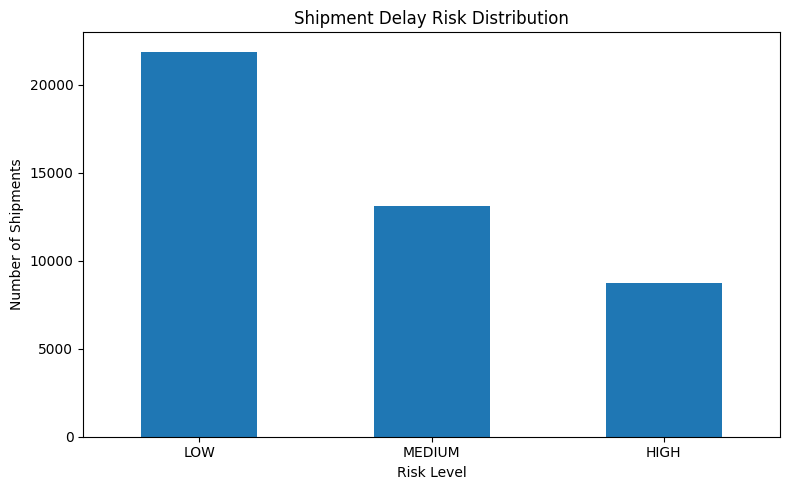


⚡ PRIORITY DISTRIBUTION
shipment_priority
NORMAL      15407
MEDIUM      11968
HIGH        10037
CRITICAL     6327
Name: count, dtype: int64


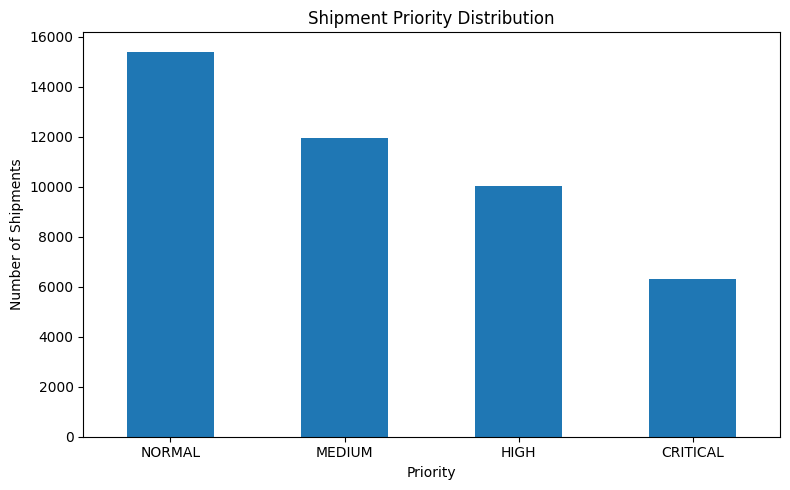


🚛 VEHICLE PERFORMANCE
vehicle
Van           116.22
Scooter       116.42
Motorcycle    131.14
Bicycle       142.44
Name: predicted_delivery_time, dtype: float64


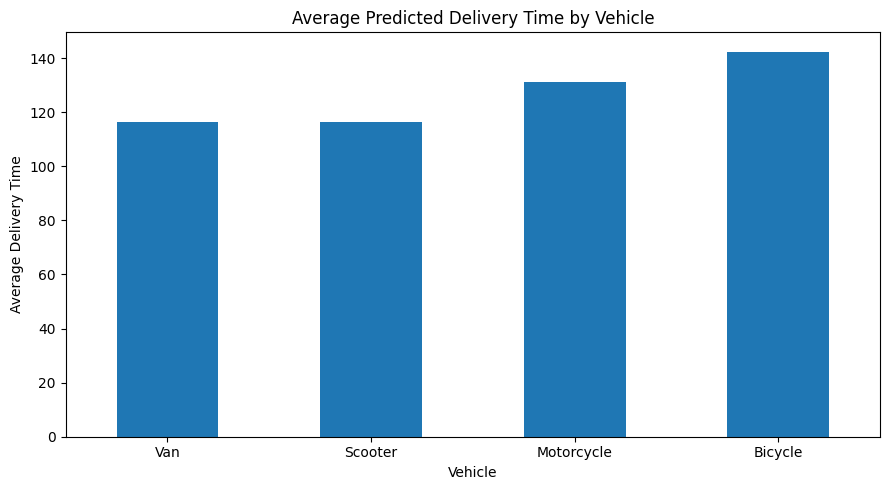


🚦 TRAFFIC ANALYSIS
traffic
Low        101.39
NaN        126.98
Medium     127.15
High       128.96
Jam        147.90
Name: predicted_delivery_time, dtype: float64


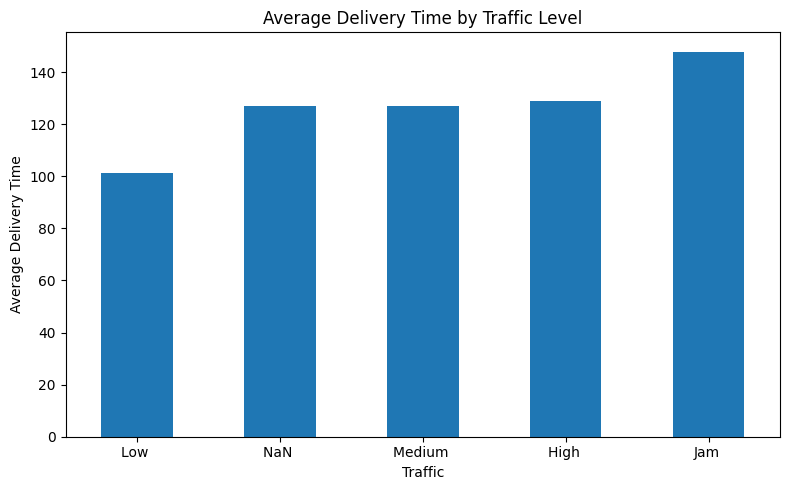


🌦️ WEATHER ANALYSIS
weather
Sunny         103.84
Sandstorms    123.19
Stormy        123.19
Windy         123.51
Fog           136.85
Cloudy        138.55
Name: predicted_delivery_time, dtype: float64


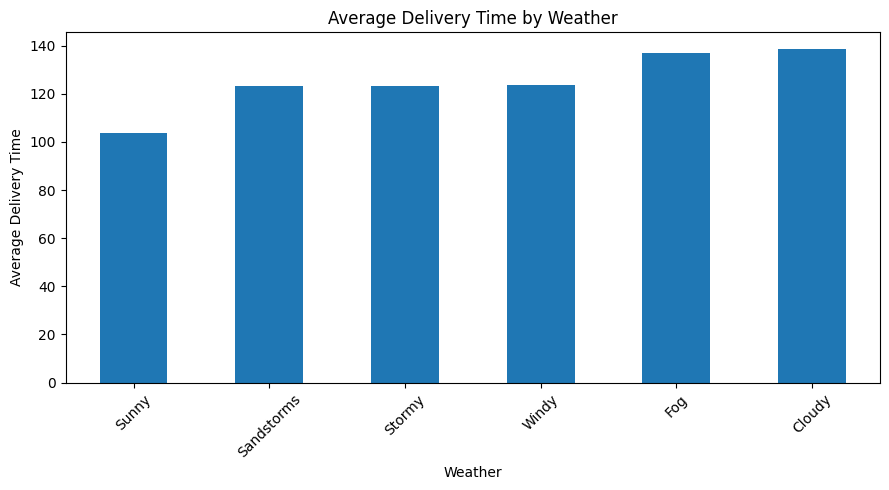


🗺️ ROUTE ANALYSIS


,route_category,shipments,avg_distance,avg_delivery_time
0,LONG,8316,18.52,139.03
1,MEDIUM,23513,9.95,128.89
2,SHORT,11722,3.06,107.27
3,VERY LONG,188,6716.63,123.70



🚨 AI LOGISTICS ALERTS
🚨 6,327 shipments require CRITICAL priority.

📋 ANALYTICS SUMMARY


,Metric,Value
0,Total Shipments,43739.00
1,Average Delivery Time,125.00
2,Average Route Distance,38.56
3,High Risk Shipments,8743.00
4,High Risk Percentage,19.99
5,Critical Shipments,6327.00



✅ Analytics files created successfully!
📁 logistics_analytics_summary.csv
📁 risk_distribution.csv
📁 priority_distribution.csv
📁 route_analytics.csv


In [235]:
# ============================================================
# STEP 12 — LOGISTICS ANALYTICS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. KPI METRICS
# ------------------------------------------------------------

total_shipments = len(model_data)

avg_delivery_time = (
    model_data["predicted_delivery_time"].mean()
)

avg_distance = (
    model_data["route_distance_km"].mean()
)

high_risk_count = (
    model_data["delay_risk"].eq("HIGH").sum()
)

critical_count = (
    model_data["shipment_priority"].eq("CRITICAL").sum()
)

high_risk_percentage = (
    high_risk_count / total_shipments * 100
)

print("=" * 60)
print("📊 AI LOGISTICS COMMAND CENTER — KPIs")
print("=" * 60)

print(f"Total Shipments       : {total_shipments:,}")
print(f"Average Delivery Time : {avg_delivery_time:.2f}")
print(f"Average Route         : {avg_distance:.2f} km")
print(f"High Risk Shipments   : {high_risk_count:,}")
print(f"High Risk %           : {high_risk_percentage:.2f}%")
print(f"Critical Shipments    : {critical_count:,}")


# ------------------------------------------------------------
# 2. RISK DISTRIBUTION
# ------------------------------------------------------------

risk_counts = (
    model_data["delay_risk"]
    .value_counts()
    .reindex(
        ["LOW", "MEDIUM", "HIGH"],
        fill_value=0
    )
)

print("\n🚨 DELAY RISK DISTRIBUTION")
print(risk_counts)


plt.figure(figsize=(8, 5))

risk_counts.plot(
    kind="bar"
)

plt.title("Shipment Delay Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. PRIORITY DISTRIBUTION
# ------------------------------------------------------------

priority_counts = (
    model_data["shipment_priority"]
    .value_counts()
    .reindex(
        ["NORMAL", "MEDIUM", "HIGH", "CRITICAL"],
        fill_value=0
    )
)

print("\n⚡ PRIORITY DISTRIBUTION")
print(priority_counts)


plt.figure(figsize=(8, 5))

priority_counts.plot(
    kind="bar"
)

plt.title("Shipment Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. VEHICLE PERFORMANCE
# ------------------------------------------------------------

vehicle_chart = (
    model_data
    .groupby("vehicle")["predicted_delivery_time"]
    .mean()
    .sort_values()
)

print("\n🚛 VEHICLE PERFORMANCE")
print(vehicle_chart.round(2))


plt.figure(figsize=(9, 5))

vehicle_chart.plot(
    kind="bar"
)

plt.title("Average Predicted Delivery Time by Vehicle")
plt.xlabel("Vehicle")
plt.ylabel("Average Delivery Time")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. TRAFFIC ANALYSIS
# ------------------------------------------------------------

if "traffic" in model_data.columns:

    traffic_chart = (
        model_data
        .groupby("traffic")["predicted_delivery_time"]
        .mean()
        .sort_values()
    )

    print("\n🚦 TRAFFIC ANALYSIS")
    print(traffic_chart.round(2))

    plt.figure(figsize=(8, 5))

    traffic_chart.plot(
        kind="bar"
    )

    plt.title("Average Delivery Time by Traffic Level")
    plt.xlabel("Traffic")
    plt.ylabel("Average Delivery Time")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. WEATHER ANALYSIS
# ------------------------------------------------------------

if "weather" in model_data.columns:

    weather_chart = (
        model_data
        .groupby("weather")["predicted_delivery_time"]
        .mean()
        .sort_values()
    )

    print("\n🌦️ WEATHER ANALYSIS")
    print(weather_chart.round(2))

    plt.figure(figsize=(9, 5))

    weather_chart.plot(
        kind="bar"
    )

    plt.title("Average Delivery Time by Weather")
    plt.xlabel("Weather")
    plt.ylabel("Average Delivery Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. ROUTE ANALYSIS
# ------------------------------------------------------------

route_chart = (
    model_data
    .groupby("route_category")
    .agg(
        shipments=("route_category", "size"),
        avg_distance=("route_distance_km", "mean"),
        avg_delivery_time=(
            "predicted_delivery_time",
            "mean"
        )
    )
    .reset_index()
)

print("\n🗺️ ROUTE ANALYSIS")
display(route_chart.round(2))


# ------------------------------------------------------------
# 8. AI ALERT SUMMARY
# ------------------------------------------------------------

alerts = []

if high_risk_percentage > 20:
    alerts.append(
        "⚠️ High number of shipments are classified as HIGH risk."
    )

if critical_count > 0:
    alerts.append(
        f"🚨 {critical_count:,} shipments require CRITICAL priority."
    )

if "traffic" in model_data.columns:

    high_traffic = model_data[
        model_data["traffic"]
        .astype(str)
        .str.lower()
        .eq("high")
    ]

    if len(high_traffic) > 0:
        alerts.append(
            f"🚦 {len(high_traffic):,} shipments are affected by high traffic."
        )

if not alerts:
    alerts.append(
        "✅ No major operational alerts detected."
    )


print("\n🚨 AI LOGISTICS ALERTS")
print("=" * 60)

for alert in alerts:
    print(alert)


# ------------------------------------------------------------
# 9. CREATE ANALYTICS SUMMARY
# ------------------------------------------------------------

analytics_summary = pd.DataFrame({
    "Metric": [
        "Total Shipments",
        "Average Delivery Time",
        "Average Route Distance",
        "High Risk Shipments",
        "High Risk Percentage",
        "Critical Shipments"
    ],
    "Value": [
        total_shipments,
        round(avg_delivery_time, 2),
        round(avg_distance, 2),
        high_risk_count,
        round(high_risk_percentage, 2),
        critical_count
    ]
})

print("\n📋 ANALYTICS SUMMARY")
display(analytics_summary)


# ------------------------------------------------------------
# 10. SAVE ANALYTICS DATA
# ------------------------------------------------------------

analytics_summary.to_csv(
    "logistics_analytics_summary.csv",
    index=False
)

risk_counts.to_csv(
    "risk_distribution.csv"
)

priority_counts.to_csv(
    "priority_distribution.csv"
)

route_chart.to_csv(
    "route_analytics.csv",
    index=False
)

print("\n✅ Analytics files created successfully!")
print("📁 logistics_analytics_summary.csv")
print("📁 risk_distribution.csv")
print("📁 priority_distribution.csv")
print("📁 route_analytics.csv")

In [236]:
# ============================================================
# STEP 13 — INTERACTIVE SHIPMENT SEARCH & TRACKING
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Check Order ID
# ------------------------------------------------------------

if "order_id" not in model_data.columns:
    raise ValueError("❌ 'order_id' column not found.")

print("✅ Order ID column found")


# ------------------------------------------------------------
# 2. Create tracking dataset
# ------------------------------------------------------------

tracking_columns = [
    "order_id",
    "predicted_delivery_time",
    "delay_risk",
    "risk_score",
    "priority_score",
    "shipment_priority",
    "route_distance_km",
    "route_category",
    "traffic",
    "weather",
    "vehicle",
    "recommended_vehicle"
]

tracking_columns = [
    col for col in tracking_columns
    if col in model_data.columns
]

tracking_data = model_data[tracking_columns].copy()

print(f"✅ Tracking records available: {len(tracking_data):,}")


# ------------------------------------------------------------
# 3. Shipment search function
# ------------------------------------------------------------

def track_shipment(order_id):

    order_id = str(order_id).strip()

    result = tracking_data[
        tracking_data["order_id"]
        .astype(str)
        .str.strip()
        .str.lower()
        == order_id.lower()
    ]

    if result.empty:

        print("\n❌ Shipment not found.")
        print("Please check the Order ID.")

        return None

    shipment = result.iloc[0]

    print("\n" + "=" * 65)
    print("📦 AI SHIPMENT TRACKING")
    print("=" * 65)

    print(f"Order ID              : {shipment['order_id']}")
    print(
        f"Predicted Delivery    : "
        f"{shipment['predicted_delivery_time']:.2f}"
    )
    print(f"Delay Risk            : {shipment['delay_risk']}")
    print(f"Risk Score            : {shipment['risk_score']:.2f}")
    print(f"Priority Score        : {shipment['priority_score']:.2f}")
    print(f"Shipment Priority     : {shipment['shipment_priority']}")
    print(
        f"Route Distance        : "
        f"{shipment['route_distance_km']:.2f} km"
    )
    print(f"Route Category        : {shipment['route_category']}")
    print(f"Traffic               : {shipment['traffic']}")
    print(f"Weather               : {shipment['weather']}")
    print(f"Current Vehicle       : {shipment['vehicle']}")
    print(
        f"AI Recommended Vehicle: "
        f"{shipment['recommended_vehicle']}"
    )

    print("=" * 65)

    # AI operational recommendation
    if shipment["shipment_priority"] == "CRITICAL":

        recommendation = (
            "🚨 Immediate operational intervention required."
        )

    elif shipment["shipment_priority"] == "HIGH":

        recommendation = (
            "⚠️ Closely monitor shipment and consider route optimization."
        )

    elif shipment["shipment_priority"] == "MEDIUM":

        recommendation = (
            "🟡 Monitor shipment during transit."
        )

    else:

        recommendation = (
            "🟢 Shipment operating under normal conditions."
        )

    print("\n🤖 AI RECOMMENDATION:")
    print(recommendation)

    return shipment


# ------------------------------------------------------------
# 4. Show available sample Order IDs
# ------------------------------------------------------------

print("\n🔎 SAMPLE ORDER IDs")
print("=" * 65)

sample_orders = (
    tracking_data["order_id"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .head(10)
    .tolist()
)

for i, order in enumerate(sample_orders, 1):
    print(f"{i}. {order}")


# ------------------------------------------------------------
# 5. Test tracking
# ------------------------------------------------------------

test_order = sample_orders[0]

print("\n🔍 Testing tracking engine...")
track_shipment(test_order)

✅ Order ID column found
✅ Tracking records available: 43,739

🔎 SAMPLE ORDER IDs
1. ialx566343618
2. akqg208421122
3. njpu434582536
4. rjto796129700
5. zguw716275638
6. fxuu788413734
7. njmo150975311
8. jvjc772545076
9. uaeb808891380
10. bgvc052754213

🔍 Testing tracking engine...

📦 AI SHIPMENT TRACKING
Order ID              : ialx566343618
Predicted Delivery    : 110.15
Delay Risk            : LOW
Risk Score            : 41.29
Priority Score        : 35.00
Shipment Priority     : MEDIUM
Route Distance        : 3.03 km
Route Category        : SHORT
Traffic               : High 
Weather               : Sunny
Current Vehicle       : Motorcycle
AI Recommended Vehicle: Motorcycle

🤖 AI RECOMMENDATION:
🟡 Monitor shipment during transit.


,0
order_id,ialx566343618
predicted_delivery_time,110.15
delay_risk,LOW
risk_score,41.29
priority_score,35.0
shipment_priority,MEDIUM
route_distance_km,3.025149
route_category,SHORT
traffic,High
weather,Sunny


In [237]:
track_shipment("123456")


❌ Shipment not found.
Please check the Order ID.


In [238]:
# ============================================================
# STEP 14 — LIVE LOGISTICS CONTROL TOWER
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. CONTROL TOWER KPIs
# ------------------------------------------------------------

total_shipments = len(model_data)

high_risk = (
    model_data["delay_risk"].eq("HIGH").sum()
)

medium_risk = (
    model_data["delay_risk"].eq("MEDIUM").sum()
)

critical_shipments = (
    model_data["shipment_priority"].eq("CRITICAL").sum()
)

high_priority = (
    model_data["shipment_priority"].eq("HIGH").sum()
)

avg_eta = (
    model_data["predicted_delivery_time"].mean()
)

avg_distance = (
    model_data["route_distance_km"].mean()
)


# ------------------------------------------------------------
# 2. TRAFFIC STATUS
# ------------------------------------------------------------

traffic_summary = {}

if "traffic" in model_data.columns:

    traffic_summary = (
        model_data["traffic"]
        .astype(str)
        .str.strip()
        .str.title()
        .value_counts()
        .to_dict()
    )


# ------------------------------------------------------------
# 3. WEATHER STATUS
# ------------------------------------------------------------

weather_summary = {}

if "weather" in model_data.columns:

    weather_summary = (
        model_data["weather"]
        .astype(str)
        .str.strip()
        .str.title()
        .value_counts()
        .to_dict()
    )


# ------------------------------------------------------------
# 4. VEHICLE STATUS
# ------------------------------------------------------------

vehicle_summary = (
    model_data["recommended_vehicle"]
    .value_counts()
    .to_dict()
)


# ------------------------------------------------------------
# 5. DISPLAY COMMAND CENTER
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("              🚚 AI LOGISTICS CONTROL TOWER")
print("=" * 75)

print("\n📊 OPERATIONAL KPIs")
print("-" * 75)

print(f"Total Shipments        : {total_shipments:,}")
print(f"Average ETA            : {avg_eta:.2f}")
print(f"Average Route Distance : {avg_distance:.2f} km")
print(f"High Risk Shipments    : {high_risk:,}")
print(f"Medium Risk Shipments  : {medium_risk:,}")
print(f"Critical Shipments     : {critical_shipments:,}")
print(f"High Priority          : {high_priority:,}")


# ------------------------------------------------------------
# 6. TRAFFIC CONTROL
# ------------------------------------------------------------

print("\n🚦 TRAFFIC CONTROL")
print("-" * 75)

for traffic, count in traffic_summary.items():
    print(f"{traffic:<15} : {count:,}")


# ------------------------------------------------------------
# 7. WEATHER CONTROL
# ------------------------------------------------------------

print("\n🌦️ WEATHER CONDITIONS")
print("-" * 75)

for weather, count in weather_summary.items():
    print(f"{weather:<15} : {count:,}")


# ------------------------------------------------------------
# 8. VEHICLE CONTROL
# ------------------------------------------------------------

print("\n🚛 VEHICLE ALLOCATION")
print("-" * 75)

for vehicle, count in vehicle_summary.items():
    print(f"{vehicle:<20} : {count:,}")


# ------------------------------------------------------------
# 9. AI ALERT GENERATOR
# ------------------------------------------------------------

print("\n🚨 AI OPERATIONAL ALERTS")
print("-" * 75)

alerts = []

if critical_shipments > 0:

    alerts.append(
        f"CRITICAL: {critical_shipments:,} shipments "
        "require immediate attention."
    )

if high_risk > 0:

    alerts.append(
        f"HIGH RISK: {high_risk:,} shipments "
        "have elevated delay risk."
    )

if "High" in traffic_summary:

    alerts.append(
        f"TRAFFIC: {traffic_summary['High']:,} shipments "
        "are operating under high traffic."
    )

if not alerts:

    alerts.append(
        "SYSTEM: No major operational alerts detected."
    )


for i, alert in enumerate(alerts, 1):

    print(f"{i}. {alert}")


# ------------------------------------------------------------
# 10. TOP PRIORITY SHIPMENTS
# ------------------------------------------------------------

print("\n🔥 TOP PRIORITY SHIPMENTS")
print("-" * 75)

priority_columns = [
    "order_id",
    "shipment_priority",
    "delay_risk",
    "predicted_delivery_time",
    "route_distance_km",
    "traffic",
    "vehicle"
]

priority_columns = [
    col
    for col in priority_columns
    if col in model_data.columns
]

top_shipments = (
    model_data
    .sort_values(
        ["priority_score", "risk_score"],
        ascending=False
    )
    [priority_columns]
    .head(10)
)

display(top_shipments)


# ------------------------------------------------------------
# 11. CONTROL TOWER SUMMARY DATAFRAME
# ------------------------------------------------------------

control_tower_summary = pd.DataFrame({
    "Metric": [
        "Total Shipments",
        "Average ETA",
        "Average Route Distance",
        "High Risk Shipments",
        "Medium Risk Shipments",
        "Critical Shipments",
        "High Priority Shipments"
    ],

    "Value": [
        total_shipments,
        round(avg_eta, 2),
        round(avg_distance, 2),
        high_risk,
        medium_risk,
        critical_shipments,
        high_priority
    ]
})


print("\n📋 CONTROL TOWER SUMMARY")

display(control_tower_summary)


# ------------------------------------------------------------
# 12. SAVE CONTROL TOWER DATA
# ------------------------------------------------------------

control_tower_summary.to_csv(
    "control_tower_summary.csv",
    index=False
)

top_shipments.to_csv(
    "top_priority_shipments.csv",
    index=False
)

print("\n✅ CONTROL TOWER CREATED")
print("📁 control_tower_summary.csv")
print("📁 top_priority_shipments.csv")



              🚚 AI LOGISTICS CONTROL TOWER

📊 OPERATIONAL KPIs
---------------------------------------------------------------------------
Total Shipments        : 43,739
Average ETA            : 125.00
Average Route Distance : 38.56 km
High Risk Shipments    : 8,743
Medium Risk Shipments  : 13,125
Critical Shipments     : 6,327
High Priority          : 10,037

🚦 TRAFFIC CONTROL
---------------------------------------------------------------------------
Low             : 14,999
Jam             : 13,725
Medium          : 10,628
High            : 4,296
Nan             : 91

🌦️ WEATHER CONDITIONS
---------------------------------------------------------------------------
Fog             : 7,440
Stormy          : 7,374
Cloudy          : 7,288
Sandstorms      : 7,245
Windy           : 7,223
Sunny           : 7,078
Nan             : 91

🚛 VEHICLE ALLOCATION
---------------------------------------------------------------------------
Motorcycle           : 34,831
Van                  : 8,908

,order_id,shipment_priority,delay_risk,predicted_delivery_time,route_distance_km,traffic,vehicle
41117,zgpn342197890,CRITICAL,HIGH,246.525,6.050551,High,Motorcycle
7069,dhsc528296331,CRITICAL,HIGH,220.275,1.544206,High,Motorcycle
19226,ojms408727953,CRITICAL,HIGH,218.200,6.128684,High,Motorcycle
42363,pzfs928729179,CRITICAL,HIGH,217.800,6.081441,High,Motorcycle
19076,mjho850441583,CRITICAL,HIGH,217.175,1.552417,High,Motorcycle
11244,uthh855051037,CRITICAL,HIGH,214.525,6.210169,High,Motorcycle
14459,bxcx649144766,CRITICAL,HIGH,214.325,3.064486,High,Motorcycle
5544,gzxz130283478,CRITICAL,HIGH,213.375,3.109125,High,Motorcycle
7115,ubha734377825,CRITICAL,HIGH,213.125,3.061134,High,Motorcycle
1990,foct048214564,CRITICAL,HIGH,213.075,1.536792,High,Motorcycle



📋 CONTROL TOWER SUMMARY


,Metric,Value
0,Total Shipments,43739.00
1,Average ETA,125.00
2,Average Route Distance,38.56
3,High Risk Shipments,8743.00
4,Medium Risk Shipments,13125.00
5,Critical Shipments,6327.00
6,High Priority Shipments,10037.00



✅ CONTROL TOWER CREATED
📁 control_tower_summary.csv
📁 top_priority_shipments.csv


In [239]:
# ============================================================
# STEP 15.1 — PLOTLY SETUP
# ============================================================

!pip install -q plotly

import plotly.express as px
import plotly.graph_objects as go

print("✅ Plotly ready")

✅ Plotly ready


In [240]:
# ============================================================
# STEP 15.2 — INTERACTIVE LOGISTICS DASHBOARD
# ============================================================

import plotly.express as px
import plotly.graph_objects as go

# ------------------------------------------------------------
# KPI VALUES
# ------------------------------------------------------------

total_shipments = len(model_data)

avg_eta = model_data[
    "predicted_delivery_time"
].mean()

avg_distance = model_data[
    "route_distance_km"
].mean()

high_risk = (
    model_data["delay_risk"] == "HIGH"
).sum()

critical = (
    model_data["shipment_priority"] == "CRITICAL"
).sum()


# ============================================================
# 1. KPI CARDS
# ============================================================

fig_kpi = go.Figure()

kpis = [
    ("Total Shipments", f"{total_shipments:,}"),
    ("Average ETA", f"{avg_eta:.2f}"),
    ("Avg Distance", f"{avg_distance:.2f} km"),
    ("High Risk", f"{high_risk:,}"),
    ("Critical", f"{critical:,}")
]

for i, (title, value) in enumerate(kpis):

    fig_kpi.add_trace(
        go.Indicator(
            mode="number",
            value=(
                float(
                    value.replace(",", "")
                    .replace(" km", "")
                )
                if value.replace(",", "")
                .replace(" km", "")
                .replace(".", "", 1)
                .isdigit()
                else 0
            ),
            title={
                "text": f"<b>{title}</b>"
            },
            domain={
                "row": 0,
                "column": i
            }
        )
    )

fig_kpi.update_layout(
    grid={
        "rows": 1,
        "columns": 5
    },
    height=180,
    title="🚚 AI Logistics KPIs"
)

fig_kpi.show()


# ============================================================
# 2. DELAY RISK CHART
# ============================================================

risk_chart = (
    model_data["delay_risk"]
    .value_counts()
    .reindex(
        ["LOW", "MEDIUM", "HIGH"],
        fill_value=0
    )
    .reset_index()
)

risk_chart.columns = [
    "Risk",
    "Shipments"
]

fig_risk = px.bar(
    risk_chart,
    x="Risk",
    y="Shipments",
    title="🚨 Shipment Delay Risk",
    text="Shipments"
)

fig_risk.update_traces(
    textposition="outside"
)

fig_risk.show()


# ============================================================
# 3. PRIORITY CHART
# ============================================================

priority_chart = (
    model_data["shipment_priority"]
    .value_counts()
    .reindex(
        ["NORMAL", "MEDIUM", "HIGH", "CRITICAL"],
        fill_value=0
    )
    .reset_index()
)

priority_chart.columns = [
    "Priority",
    "Shipments"
]

fig_priority = px.bar(
    priority_chart,
    x="Priority",
    y="Shipments",
    title="⚡ Shipment Priority",
    text="Shipments"
)

fig_priority.update_traces(
    textposition="outside"
)

fig_priority.show()


# ============================================================
# 4. VEHICLE PERFORMANCE
# ============================================================

vehicle_chart = (
    model_data
    .groupby("vehicle")[
        "predicted_delivery_time"
    ]
    .mean()
    .reset_index()
)

vehicle_chart.columns = [
    "Vehicle",
    "Average ETA"
]

fig_vehicle = px.bar(
    vehicle_chart,
    x="Vehicle",
    y="Average ETA",
    title="🚛 Vehicle Performance",
    text_auto=".2f"
)

fig_vehicle.show()


# ============================================================
# 5. TRAFFIC IMPACT
# ============================================================

if "traffic" in model_data.columns:

    traffic_chart = (
        model_data
        .groupby("traffic")[
            "predicted_delivery_time"
        ]
        .mean()
        .reset_index()
    )

    traffic_chart.columns = [
        "Traffic",
        "Average ETA"
    ]

    fig_traffic = px.bar(
        traffic_chart,
        x="Traffic",
        y="Average ETA",
        title="🚦 Traffic Impact on Delivery Time",
        text_auto=".2f"
    )

    fig_traffic.show()


# ============================================================
# 6. WEATHER IMPACT
# ============================================================

if "weather" in model_data.columns:

    weather_chart = (
        model_data
        .groupby("weather")[
            "predicted_delivery_time"
        ]
        .mean()
        .reset_index()
    )

    weather_chart.columns = [
        "Weather",
        "Average ETA"
    ]

    fig_weather = px.bar(
        weather_chart,
        x="Weather",
        y="Average ETA",
        title="🌦️ Weather Impact",
        text_auto=".2f"
    )

    fig_weather.show()


# ============================================================
# 7. ROUTE DISTANCE DISTRIBUTION
# ============================================================

fig_distance = px.histogram(
    model_data,
    x="route_distance_km",
    nbins=40,
    title="🗺️ Shipment Route Distance Distribution",
    labels={
        "route_distance_km": "Distance (km)"
    }
)

fig_distance.show()


# ============================================================
# 8. ETA VS DISTANCE
# ============================================================

fig_eta_distance = px.scatter(
    model_data.sample(
        min(5000, len(model_data)),
        random_state=42
    ),
    x="route_distance_km",
    y="predicted_delivery_time",
    color="delay_risk",
    title="🤖 Predicted ETA vs Route Distance",
    labels={
        "route_distance_km": "Distance (km)",
        "predicted_delivery_time": "Predicted Delivery Time"
    },
    hover_data=[
        "delay_risk",
        "shipment_priority"
    ]
)

fig_eta_distance.show()


print("\n" + "=" * 60)
print("✅ INTERACTIVE LOGISTICS DASHBOARD CREATED")
print("=" * 60)


✅ INTERACTIVE LOGISTICS DASHBOARD CREATED


In [241]:
# ============================================================
# STEP 16.1 — CREATE STREAMLIT APPLICATION
# ============================================================

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import joblib
import os

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="AI Logistics Command Center",
    page_icon="🚚",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# LOAD DATA
# ============================================================

DATA_FILE = "amazon_logistics_ai_dataset.csv"

if not os.path.exists(DATA_FILE):
    st.error(
        "Dataset not found. Please make sure "
        "amazon_logistics_ai_dataset.csv exists."
    )
    st.stop()

data = pd.read_csv(DATA_FILE)


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title("🚚 AI LOGISTICS")

st.sidebar.caption(
    "Intelligent Shipment Management System"
)

st.sidebar.divider()

page = st.sidebar.radio(
    "NAVIGATION",
    [
        "Control Tower",
        "Track Shipments",
        "AI Console",
        "Analytics",
        "Vehicle Intelligence"
    ]
)

st.sidebar.divider()

st.sidebar.success(
    "🟢 AI System Online"
)

st.sidebar.caption(
    f"Shipments Loaded: {len(data):,}"
)


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown(
    """
    <style>

    .main-title {
        font-size: 32px;
        font-weight: 700;
        margin-bottom: 5px;
    }

    .subtitle {
        font-size: 15px;
        opacity: 0.7;
        margin-bottom: 25px;
    }

    .metric-card {
        padding: 20px;
        border-radius: 12px;
        border: 1px solid rgba(128,128,128,0.25);
        text-align: left;
    }

    .section-title {
        font-size: 22px;
        font-weight: 650;
        margin-top: 20px;
        margin-bottom: 15px;
    }

    </style>
    """,
    unsafe_allow_html=True
)


# ============================================================
# CONTROL TOWER
# ============================================================

if page == "Control Tower":

    st.markdown(
        '<div class="main-title">'
        '🚚 AI Logistics Command Center'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="subtitle">'
        'Real-time intelligent shipment operations dashboard'
        '</div>',
        unsafe_allow_html=True
    )

    # --------------------------------------------------------
    # KPI DATA
    # --------------------------------------------------------

    total_shipments = len(data)

    avg_eta = (
        data["predicted_delivery_time"].mean()
        if "predicted_delivery_time" in data.columns
        else 0
    )

    avg_distance = (
        data["route_distance_km"].mean()
        if "route_distance_km" in data.columns
        else 0
    )

    high_risk = (
        data["delay_risk"].eq("HIGH").sum()
        if "delay_risk" in data.columns
        else 0
    )

    critical = (
        data["shipment_priority"].eq("CRITICAL").sum()
        if "shipment_priority" in data.columns
        else 0
    )

    # --------------------------------------------------------
    # KPI CARDS
    # --------------------------------------------------------

    c1, c2, c3, c4, c5 = st.columns(5)

    c1.metric(
        "Total Shipments",
        f"{total_shipments:,}"
    )

    c2.metric(
        "Average ETA",
        f"{avg_eta:.2f}"
    )

    c3.metric(
        "Avg Distance",
        f"{avg_distance:.2f} km"
    )

    c4.metric(
        "High Risk",
        f"{high_risk:,}"
    )

    c5.metric(
        "Critical",
        f"{critical:,}"
    )

    st.divider()

    # --------------------------------------------------------
    # RISK + PRIORITY
    # --------------------------------------------------------

    left, right = st.columns(2)

    with left:

        st.subheader("🚨 Delay Risk")

        risk_data = (
            data["delay_risk"]
            .value_counts()
            .reindex(
                ["LOW", "MEDIUM", "HIGH"],
                fill_value=0
            )
            .reset_index()
        )

        risk_data.columns = [
            "Risk",
            "Shipments"
        ]

        fig = px.bar(
            risk_data,
            x="Risk",
            y="Shipments",
            text="Shipments"
        )

        fig.update_layout(
            height=350,
            margin=dict(
                l=20,
                r=20,
                t=30,
                b=20
            )
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

    with right:

        st.subheader("⚡ Shipment Priority")

        priority_data = (
            data["shipment_priority"]
            .value_counts()
            .reindex(
                [
                    "NORMAL",
                    "MEDIUM",
                    "HIGH",
                    "CRITICAL"
                ],
                fill_value=0
            )
            .reset_index()
        )

        priority_data.columns = [
            "Priority",
            "Shipments"
        ]

        fig = px.bar(
            priority_data,
            x="Priority",
            y="Shipments",
            text="Shipments"
        )

        fig.update_layout(
            height=350,
            margin=dict(
                l=20,
                r=20,
                t=30,
                b=20
            )
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )


    # --------------------------------------------------------
    # TOP PRIORITY SHIPMENTS
    # --------------------------------------------------------

    st.subheader("🔥 Priority Shipments")

    priority_columns = [
        "order_id",
        "shipment_priority",
        "delay_risk",
        "predicted_delivery_time",
        "route_distance_km",
        "traffic",
        "vehicle"
    ]

    priority_columns = [
        col
        for col in priority_columns
        if col in data.columns
    ]

    top_shipments = (
        data
        .sort_values(
            "priority_score",
            ascending=False
        )
        [priority_columns]
        .head(10)
    )

    st.dataframe(
        top_shipments,
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# TRACK SHIPMENTS
# ============================================================

elif page == "Track Shipments":

    st.markdown(
        '<div class="main-title">'
        '📦 Track Shipment'
        '</div>',
        unsafe_allow_html=True
    )

    st.write(
        "Search any shipment using its Order ID."
    )

    if "order_id" not in data.columns:
        st.error("Order ID column not available.")
        st.stop()

    order_ids = (
        data["order_id"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    selected_order = st.selectbox(
        "Select Order ID",
        order_ids
    )

    shipment = data[
        data["order_id"]
        .astype(str)
        == selected_order
    ]

    if not shipment.empty:

        row = shipment.iloc[0]

        st.divider()

        c1, c2, c3, c4 = st.columns(4)

        c1.metric(
            "Order ID",
            str(row["order_id"])
        )

        c2.metric(
            "ETA",
            f"{row['predicted_delivery_time']:.2f}"
        )

        c3.metric(
            "Risk",
            str(row["delay_risk"])
        )

        c4.metric(
            "Priority",
            str(row["shipment_priority"])
        )

        st.divider()

        left, right = st.columns(2)

        with left:

            st.subheader("📍 Route")

            if "route_distance_km" in row:
                st.write(
                    f"Distance: "
                    f"**{row['route_distance_km']:.2f} km**"
                )

            if "route_category" in row:
                st.write(
                    f"Route Type: "
                    f"**{row['route_category']}**"
                )

            if "traffic" in row:
                st.write(
                    f"Traffic: "
                    f"**{row['traffic']}**"
                )

            if "weather" in row:
                st.write(
                    f"Weather: "
                    f"**{row['weather']}**"
                )

        with right:

            st.subheader("🚛 Vehicle")

            if "vehicle" in row:
                st.write(
                    f"Current Vehicle: "
                    f"**{row['vehicle']}**"
                )

            if "recommended_vehicle" in row:
                st.write(
                    f"AI Recommendation: "
                    f"**{row['recommended_vehicle']}**"
                )

            if "risk_score" in row:
                st.write(
                    f"Risk Score: "
                    f"**{row['risk_score']:.2f}**"
                )


# ============================================================
# AI CONSOLE
# ============================================================

elif page == "AI Console":

    st.markdown(
        '<div class="main-title">'
        '🤖 AI Logistics Console'
        '</div>',
        unsafe_allow_html=True
    )

    st.write(
        "Ask the logistics intelligence system for operational insights."
    )

    question = st.text_input(
        "Enter your question",
        placeholder="Example: How many high-risk shipments are there?"
    )

    if st.button("Analyze"):

        if question:

            q = question.lower()

            if "high risk" in q:

                count = (
                    data["delay_risk"]
                    .eq("HIGH")
                    .sum()
                )

                st.success(
                    f"AI Analysis: {count:,} "
                    "shipments are currently classified as HIGH risk."
                )

            elif "critical" in q:

                count = (
                    data["shipment_priority"]
                    .eq("CRITICAL")
                    .sum()
                )

                st.warning(
                    f"AI Analysis: {count:,} "
                    "shipments require CRITICAL priority."
                )

            elif "average" in q and "distance" in q:

                value = data[
                    "route_distance_km"
                ].mean()

                st.info(
                    f"Average shipment distance is "
                    f"{value:.2f} km."
                )

            elif "average" in q and "eta" in q:

                value = data[
                    "predicted_delivery_time"
                ].mean()

                st.info(
                    f"Average predicted delivery time is "
                    f"{value:.2f}."
                )

            else:

                st.info(
                    "AI Console supports questions about "
                    "risk, priority, ETA and distance."
                )


# ============================================================
# ANALYTICS
# ============================================================

elif page == "Analytics":

    st.markdown(
        '<div class="main-title">'
        '📊 Logistics Analytics'
        '</div>',
        unsafe_allow_html=True
    )

    col1, col2 = st.columns(2)

    with col1:

        vehicle_data = (
            data
            .groupby("vehicle")
            ["predicted_delivery_time"]
            .mean()
            .reset_index()
        )

        fig = px.bar(
            vehicle_data,
            x="vehicle",
            y="predicted_delivery_time",
            title="Vehicle Performance"
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

    with col2:

        traffic_data = (
            data
            .groupby("traffic")
            ["predicted_delivery_time"]
            .mean()
            .reset_index()
        )

        fig = px.bar(
            traffic_data,
            x="traffic",
            y="predicted_delivery_time",
            title="Traffic Impact"
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

    st.subheader("🗺️ Route Distance Distribution")

    fig = px.histogram(
        data,
        x="route_distance_km",
        nbins=40
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )


# ============================================================
# VEHICLE INTELLIGENCE
# ============================================================

elif page == "Vehicle Intelligence":

    st.markdown(
        '<div class="main-title">'
        '🚛 Vehicle Intelligence'
        '</div>',
        unsafe_allow_html=True
    )

    vehicle_data = (
        data
        .groupby("vehicle")
        .agg(
            shipments=("vehicle", "size"),
            avg_eta=(
                "predicted_delivery_time",
                "mean"
            ),
            avg_distance=(
                "route_distance_km",
                "mean"
            ),
            high_risk=(
                "delay_risk",
                lambda x: (x == "HIGH").sum()
            )
        )
        .reset_index()
    )

    vehicle_data["high_risk_percentage"] = (
        vehicle_data["high_risk"]
        / vehicle_data["shipments"]
        * 100
    ).round(2)

    st.dataframe(
        vehicle_data,
        use_container_width=True,
        hide_index=True
    )

    fig = px.bar(
        vehicle_data,
        x="vehicle",
        y="avg_eta",
        title="Average ETA by Vehicle",
        text_auto=".2f"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ app.py created successfully!")
print("📄 File size:", os.path.getsize("app.py"), "bytes")

✅ app.py created successfully!
📄 File size: 14019 bytes


In [242]:
import os

print("app.py exists:", os.path.exists("app.py"))
print("Dataset exists:", os.path.exists("amazon_logistics_ai_dataset.csv"))

app.py exists: True
Dataset exists: True


In [243]:
# ============================================================
# STEP 16.3 — START STREAMLIT
# ============================================================

import subprocess
import time

subprocess.run(
    ["pkill", "-f", "streamlit"],
    capture_output=True
)

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("=" * 60)
print("🚚 AI LOGISTICS MANAGEMENT SYSTEM")
print("=" * 60)
print("✅ Streamlit application started")
print("🌐 Port: 8501")
print("=" * 60)

🚚 AI LOGISTICS MANAGEMENT SYSTEM
✅ Streamlit application started
🌐 Port: 8501


In [244]:
from pyngrok import ngrok

ngrok.set_auth_token("3JNA7hRbRQdxarFR1WWoOilC0Tf_3y2VtHoeeiNbLJo8up7Vv")

print("✅ Ngrok authentication successful")

✅ Ngrok authentication successful


In [245]:
import subprocess
from pyngrok import ngrok

subprocess.run(
    ["pkill", "-f", "streamlit"],
    capture_output=True
)

ngrok.kill()

print("✅ Old Streamlit and ngrok processes cleared")

✅ Old Streamlit and ngrok processes cleared


In [246]:
import subprocess
import time

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("✅ Streamlit started on port 8501")

✅ Streamlit started on port 8501


In [247]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("=" * 60)
print("🚚 AI LOGISTICS MANAGEMENT SYSTEM")
print("=" * 60)
print("✅ Streamlit: RUNNING")
print()
print("🌐 PUBLIC URL:")
print(public_url)
print("=" * 60)

🚚 AI LOGISTICS MANAGEMENT SYSTEM
✅ Streamlit: RUNNING

🌐 PUBLIC URL:
NgrokTunnel: "https://pretext-vendor-configure.ngrok-free.dev" -> "http://localhost:8501"


In [248]:
import subprocess

subprocess.run(
    ["pkill", "-f", "streamlit"],
    capture_output=True
)

print("✅ Streamlit stopped")

✅ Streamlit stopped


In [249]:
# ============================================================
# STEP 17.5 — LIGHT / DARK THEME
# ============================================================

with open("app.py", "r", encoding="utf-8") as f:
    app_code = f.read()

old_sidebar = '''st.sidebar.title("🚚 AI LOGISTICS")

st.sidebar.caption(
    "Intelligent Shipment Management System"
)'''

new_sidebar = '''# ============================================================
# THEME SYSTEM
# ============================================================

if "theme" not in st.session_state:
    st.session_state.theme = "Light"

theme = st.sidebar.radio(
    "🎨 Theme",
    ["Light", "Dark"],
    horizontal=True
)

if theme == "Dark":

    st.markdown(
        """
        <style>

        .stApp {
            background-color: #0e1117;
            color: #fafafa;
        }

        section[data-testid="stSidebar"] {
            background-color: #161b22;
        }

        .stMetric {
            background-color: #161b22;
            border-radius: 12px;
            padding: 12px;
        }

        div[data-testid="stDataFrame"] {
            background-color: #161b22;
        }

        </style>
        """,
        unsafe_allow_html=True
    )

else:

    st.markdown(
        """
        <style>

        .stApp {
            background-color: #f7f9fc;
            color: #111827;
        }

        section[data-testid="stSidebar"] {
            background-color: #ffffff;
        }

        .stMetric {
            background-color: #ffffff;
            border-radius: 12px;
            padding: 12px;
        }

        div[data-testid="stDataFrame"] {
            background-color: #ffffff;
        }

        </style>
        """,
        unsafe_allow_html=True
    )


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title("🚚 AI LOGISTICS")

st.sidebar.caption(
    "Intelligent Shipment Management System"
)'''

if old_sidebar in app_code:

    app_code = app_code.replace(
        old_sidebar,
        new_sidebar
    )

    with open(
        "app.py",
        "w",
        encoding="utf-8"
    ) as f:
        f.write(app_code)

    print("✅ Light/Dark theme added successfully")

else:

    print(
        "⚠️ Sidebar code pattern was not found. "
        "Do not overwrite app.py."
    )

✅ Light/Dark theme added successfully


In [250]:
import subprocess
import time

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("✅ Streamlit restarted")

✅ Streamlit restarted


In [251]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("=" * 65)
print("🚚 AI LOGISTICS MANAGEMENT SYSTEM")
print("=" * 65)
print("🟢 SYSTEM STATUS : ONLINE")
print("🌐 PUBLIC URL    :", public_url)
print("=" * 65)

🚚 AI LOGISTICS MANAGEMENT SYSTEM
🟢 SYSTEM STATUS : ONLINE
🌐 PUBLIC URL    : NgrokTunnel: "https://pretext-vendor-configure.ngrok-free.dev" -> "http://localhost:8501"


In [256]:
# ============================================================
# STEP 18 — CLEAN PROFESSIONAL APP
# ============================================================

import os

DATA_FILE = "amazon_logistics_ai_dataset.csv"

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"❌ {DATA_FILE} not found. Run the previous data-processing steps first."
    )

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="AI Logistics Command Center",
    page_icon="🚚",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# LOAD DATA
# ============================================================

DATA_FILE = "amazon_logistics_ai_dataset.csv"

@st.cache_data
def load_data():
    return pd.read_csv(DATA_FILE)

data = load_data()

# ============================================================
# THEME
# ============================================================

if "theme" not in st.session_state:
    st.session_state.theme = "Light"

theme = st.sidebar.radio(
    "Theme",
    ["Light", "Dark"],
    index=0 if st.session_state.theme == "Light" else 1,
    horizontal=True
)

st.session_state.theme = theme

# ============================================================
# PROFESSIONAL CSS
# ============================================================

if theme == "Dark":

    bg = "#0E1117"
    card = "#161B22"
    text = "#F5F7FA"
    muted = "#9CA3AF"
    border = "#30363D"

else:

    bg = "#F5F7FB"
    card = "#FFFFFF"
    text = "#111827"
    muted = "#6B7280"
    border = "#E5E7EB"

st.markdown(
    f"""
    <style>

    .stApp {{
        background-color: {bg};
        color: {text};
    }}

    section[data-testid="stSidebar"] {{
        background-color: {card};
        border-right: 1px solid {border};
    }}

    .block-container {{
        max-width: 1450px;
        padding-top: 2rem;
        padding-bottom: 3rem;
    }}

    h1 {{
        font-size: 34px !important;
        font-weight: 800 !important;
        letter-spacing: -0.8px;
    }}

    h2 {{
        font-size: 25px !important;
        font-weight: 750 !important;
    }}

    h3 {{
        font-size: 19px !important;
        font-weight: 700 !important;
    }}

    div[data-testid="stMetric"] {{
        background-color: {card};
        border: 1px solid {border};
        border-radius: 16px;
        padding: 20px !important;
        box-shadow: 0 5px 18px rgba(0,0,0,0.06);
    }}

    div[data-testid="stMetricValue"] {{
        font-size: 28px !important;
        font-weight: 800 !important;
    }}

    .dashboard-title {{
        font-size: 34px;
        font-weight: 800;
        letter-spacing: -1px;
        color: {text};
    }}

    .dashboard-subtitle {{
        font-size: 14px;
        color: {muted};
        margin-top: 5px;
        margin-bottom: 25px;
    }}

    .section-title {{
        font-size: 19px;
        font-weight: 750;
        color: {text};
        margin-top: 25px;
        margin-bottom: 12px;
    }}

    .info-card {{
        background-color: {card};
        border: 1px solid {border};
        border-radius: 16px;
        padding: 20px;
        margin-bottom: 15px;
    }}

    .footer {{
        text-align: center;
        color: {muted};
        font-size: 12px;
        margin-top: 40px;
        padding: 20px;
    }}

    .stButton > button {{
        border-radius: 10px;
        font-weight: 650;
    }}

    </style>
    """,
    unsafe_allow_html=True
)

# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.markdown(
    """
    <div style="text-align:center; padding:10px 0 20px 0;">
        <div style="font-size:38px;">🚚</div>
        <div style="font-size:21px; font-weight:800;">
            AI LOGISTICS
        </div>
        <div style="font-size:12px; opacity:0.65;">
            Intelligent Operations
        </div>
    </div>
    """,
    unsafe_allow_html=True
)

page = st.sidebar.radio(
    "Navigation",
    [
        "Control Tower",
        "Track Shipments",
        "AI Console",
        "Analytics",
        "Vehicle Intelligence"
    ]
)

st.sidebar.markdown("---")

st.sidebar.caption("AI Logistics Management System")
st.sidebar.caption("Python • Machine Learning • Streamlit")

# ============================================================
# HEADER
# ============================================================

st.markdown(
    """
    <div class="dashboard-title">
        🚚 AI Logistics Command Center
    </div>

    <div class="dashboard-subtitle">
        Intelligent shipment management • Predictive ETA • Risk intelligence • Fleet analytics
    </div>
    """,
    unsafe_allow_html=True
)

# ============================================================
# COMMON COLUMNS
# ============================================================

def find_column(names):

    for name in names:
        if name in data.columns:
            return name

    return None


order_col = find_column(["order_id"])
eta_col = find_column(["predicted_delivery_time", "delivery_time"])
risk_col = find_column(["delay_risk"])
risk_score_col = find_column(["risk_score"])
priority_col = find_column(["shipment_priority"])
priority_score_col = find_column(["priority_score"])
distance_col = find_column(["route_distance_km"])
vehicle_col = find_column(["vehicle"])
traffic_col = find_column(["traffic"])
weather_col = find_column(["weather"])

# ============================================================
# CONTROL TOWER
# ============================================================

if page == "Control Tower":

    st.header("Control Tower")

    total_shipments = len(data)

    avg_eta = (
        data[eta_col].mean()
        if eta_col
        else 0
    )

    avg_distance = (
        data[distance_col].mean()
        if distance_col
        else 0
    )

    high_risk = (
        int((data[risk_col].astype(str).str.upper() == "HIGH").sum())
        if risk_col
        else 0
    )

    critical = (
        int((data[priority_col].astype(str).str.upper() == "CRITICAL").sum())
        if priority_col
        else 0
    )

    c1, c2, c3, c4, c5 = st.columns(5)

    c1.metric(
        "Total Shipments",
        f"{total_shipments:,}"
    )

    c2.metric(
        "Average ETA",
        f"{avg_eta:.1f}"
    )

    c3.metric(
        "Avg Route Distance",
        f"{avg_distance:.1f} km"
    )

    c4.metric(
        "High Risk",
        f"{high_risk:,}"
    )

    c5.metric(
        "Critical",
        f"{critical:,}"
    )

    st.markdown(
        '<div class="section-title">Shipment Intelligence</div>',
        unsafe_allow_html=True
    )

    col1, col2 = st.columns(2)

    with col1:

        st.subheader("Risk Distribution")

        if risk_col:

            risk_counts = data[risk_col].value_counts()

            st.bar_chart(risk_counts)

        else:

            st.info("Risk data unavailable.")

    with col2:

        st.subheader("Priority Distribution")

        if priority_col:

            priority_counts = data[priority_col].value_counts()

            st.bar_chart(priority_counts)

        else:

            st.info("Priority data unavailable.")

    st.subheader("Top Priority Shipments")

    if priority_score_col:

        display_cols = [
            c for c in [
                order_col,
                priority_col,
                priority_score_col,
                risk_col,
                eta_col,
                distance_col,
                traffic_col,
                vehicle_col
            ]
            if c is not None
        ]

        top_data = data.sort_values(
            priority_score_col,
            ascending=False
        ).head(15)

        st.dataframe(
            top_data[display_cols],
            use_container_width=True,
            hide_index=True
        )

    else:

        st.dataframe(
            data.head(15),
            use_container_width=True,
            hide_index=True
        )

# ============================================================
# TRACK SHIPMENTS
# ============================================================

elif page == "Track Shipments":

    st.header("Track Shipments")

    if order_col:

        order_ids = (
            data[order_col]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        selected_order = st.selectbox(
            "Select Shipment",
            order_ids
        )

        shipment = data[
            data[order_col].astype(str) == selected_order
        ]

        if len(shipment) > 0:

            row = shipment.iloc[0]

            st.subheader(
                f"Shipment: {selected_order}"
            )

            c1, c2, c3, c4 = st.columns(4)

            if eta_col:
                c1.metric(
                    "Predicted ETA",
                    f"{row[eta_col]:.1f}"
                )

            if risk_col:
                c2.metric(
                    "Risk",
                    str(row[risk_col])
                )

            if priority_col:
                c3.metric(
                    "Priority",
                    str(row[priority_col])
                )

            if distance_col:
                c4.metric(
                    "Distance",
                    f"{row[distance_col]:.1f} km"
                )

            st.subheader("Shipment Details")

            details = pd.DataFrame(
                {
                    "Parameter": [
                        c for c in [
                            "vehicle",
                            "traffic",
                            "weather",
                            "area",
                            "category",
                            "agent_rating",
                            "recommended_vehicle"
                        ]
                        if c in data.columns
                    ],
                    "Value": [
                        row[c] for c in [
                            "vehicle",
                            "traffic",
                            "weather",
                            "area",
                            "category",
                            "agent_rating",
                            "recommended_vehicle"
                        ]
                        if c in data.columns
                    ]
                }
            )

            st.dataframe(
                details,
                use_container_width=True,
                hide_index=True
            )

    else:

        st.warning("Order ID column not available.")

# ============================================================
# AI CONSOLE
# ============================================================

elif page == "AI Console":

    st.header("AI Logistics Console")

    st.write(
        "Ask the logistics intelligence engine about the current shipment dataset."
    )

    question = st.text_input(
        "Ask a question",
        placeholder="Example: Show high risk shipments"
    )

    if st.button("Analyze"):

        q = question.lower()

        if "high risk" in q:

            if risk_col:

                result = data[
                    data[risk_col].astype(str).str.upper() == "HIGH"
                ]

                st.success(
                    f"Found {len(result):,} high-risk shipments."
                )

                st.dataframe(
                    result.head(20),
                    use_container_width=True,
                    hide_index=True
                )

        elif "critical" in q:

            if priority_col:

                result = data[
                    data[priority_col].astype(str).str.upper()
                    == "CRITICAL"
                ]

                st.success(
                    f"Found {len(result):,} critical shipments."
                )

                st.dataframe(
                    result.head(20),
                    use_container_width=True,
                    hide_index=True
                )

        elif "distance" in q:

            if distance_col:

                st.info(
                    f"Average route distance is "
                    f"{data[distance_col].mean():.2f} km."
                )

        elif "eta" in q:

            if eta_col:

                st.info(
                    f"Average predicted delivery time is "
                    f"{data[eta_col].mean():.2f}."
                )

        else:

            st.info(
                "Try questions such as: "
                "high risk shipments, critical shipments, "
                "average distance, or average ETA."
            )

# ============================================================
# ANALYTICS
# ============================================================

elif page == "Analytics":

    st.header("Logistics Analytics")

    if vehicle_col and eta_col:

        st.subheader("Vehicle Performance")

        vehicle_performance = (
            data.groupby(vehicle_col)[eta_col]
            .mean()
            .sort_values()
        )

        st.bar_chart(vehicle_performance)

    if traffic_col and eta_col:

        st.subheader("Traffic Impact")

        traffic_performance = (
            data.groupby(traffic_col)[eta_col]
            .mean()
            .sort_values()
        )

        st.bar_chart(traffic_performance)

    if distance_col:

        st.subheader("Route Distance")

        st.line_chart(
            data[distance_col]
            .head(100)
            .reset_index(drop=True)
        )

# ============================================================
# VEHICLE INTELLIGENCE
# ============================================================

elif page == "Vehicle Intelligence":

    st.header("Vehicle Intelligence")

    if vehicle_col:

        vehicle_summary = (
            data.groupby(vehicle_col)
            .agg(
                Shipments=(vehicle_col, "count")
            )
            .sort_values(
                "Shipments",
                ascending=False
            )
        )

        if eta_col:

            eta_summary = (
                data.groupby(vehicle_col)[eta_col]
                .mean()
                .rename("Average ETA")
            )

            vehicle_summary = vehicle_summary.join(
                eta_summary
            )

        if distance_col:

            distance_summary = (
                data.groupby(vehicle_col)[distance_col]
                .mean()
                .rename("Average Distance")
            )

            vehicle_summary = vehicle_summary.join(
                distance_summary
            )

        st.dataframe(
            vehicle_summary,
            use_container_width=True
        )

        st.subheader("Vehicle Utilization")

        st.bar_chart(
            vehicle_summary["Shipments"]
        )

    else:

        st.warning("Vehicle information unavailable.")

# ============================================================
# FOOTER
# ============================================================

st.markdown(
    """
    <div class="footer">
        AI Logistics Management System
        <br>
        Powered by Python • Machine Learning • Streamlit
    </div>
    """,
    unsafe_allow_html=True
)
'''

# ============================================================
# WRITE FILE
# ============================================================

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

# ============================================================
# SYNTAX CHECK
# ============================================================

with open("app.py", "r", encoding="utf-8") as f:
    test_code = f.read()

compile(test_code, "app.py", "exec")

print("=" * 60)
print("✅ STEP 18 FIXED")
print("=" * 60)
print("✅ app.py rebuilt cleanly")
print("✅ Python syntax check PASSED")
print("✅ Light Mode available")
print("✅ Dark Mode available")
print("✅ Professional dashboard UI")
print("✅ Control Tower")
print("✅ Track Shipments")
print("✅ AI Console")
print("✅ Analytics")
print("✅ Vehicle Intelligence")
print("=" * 60)

✅ STEP 18 FIXED
✅ app.py rebuilt cleanly
✅ Python syntax check PASSED
✅ Light Mode available
✅ Dark Mode available
✅ Professional dashboard UI
✅ Control Tower
✅ Track Shipments
✅ AI Console
✅ Analytics
✅ Vehicle Intelligence


In [253]:
import subprocess
import time

subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("✅ Streamlit restarted successfully")
print("🚚 AI Logistics SaaS Dashboard is running")

✅ Streamlit restarted successfully
🚚 AI Logistics SaaS Dashboard is running


In [254]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("=" * 60)
print("🚚 AI LOGISTICS MANAGEMENT SYSTEM")
print("=" * 60)
print("🌐 PUBLIC URL:")
print(public_url)
print("=" * 60)

🚚 AI LOGISTICS MANAGEMENT SYSTEM
🌐 PUBLIC URL:
NgrokTunnel: "https://pretext-vendor-configure.ngrok-free.dev" -> "http://localhost:8501"


In [257]:
import subprocess
import time

subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("✅ Streamlit started")

✅ Streamlit started


In [259]:
from pyngrok import ngrok

# Close tunnels created by this Python/ngrok session
try:
    ngrok.kill()
except Exception as e:
    print("ngrok cleanup:", e)

print("✅ Local ngrok tunnels cleaned")

✅ Local ngrok tunnels cleaned


In [260]:
import subprocess

result = subprocess.run(
    ["pgrep", "-af", "streamlit"],
    capture_output=True,
    text=True
)

print(result.stdout if result.stdout else "⚠️ Streamlit is not currently running")

29155 [streamlit] <defunct>
52360 /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.port 8501 --server.address 0.0.0.0



In [261]:
from pyngrok import ngrok

tunnel = ngrok.connect(
    addr=8501,
    proto="http"
)

print("=" * 60)
print("🚚 AI LOGISTICS MANAGEMENT SYSTEM")
print("=" * 60)
print("🌐 PUBLIC URL:")
print(tunnel.public_url)
print("=" * 60)

🚚 AI LOGISTICS MANAGEMENT SYSTEM
🌐 PUBLIC URL:
https://pretext-vendor-configure.ngrok-free.dev
